# Contagion SIS ↔ E_i — pipeline complète (A → Z)

Pipeline auto-suffisante (reprise simplifiée de `periods_analysis.ipynb`) :

1. **Données** : log-rendements intraday des actions (`data/stock_filled.csv`).
2. **E_i journalier** : pour chaque actif, force de corrélation moyenne aux autres, jour par jour.
3. **Réseaux** : PMFG, VAR(1), VAR(13), corrélation seuillée (`Corr thr`).
4. **Périodes de crise** : fenêtres où la corrélation moyenne journalière croît, puis sous-fenêtre par actif.
5. **Modèle SIS** : trajectoire x_i (réseau complet, x* constant) intégrée puis comparée à E_i empirique → R².
6. **Résultats** : R² moyen par méthode/période (heatmap + sélection) et, par méthode, évolution temporelle / scatter x_i↔E_i / distribution des R².

> Calculs lourds (PMFG, fits SIS) mis en cache dans `.cache/monthly_correlations/`. Mettre `FORCE_RECOMPUTE = True` pour tout recalculer.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import os, time, pickle, glob, hashlib
from scipy.integrate import solve_ivp
from scipy.ndimage import uniform_filter1d
from scipy.stats import linregress
from functions import load_data

plt.rcParams['figure.dpi'] = 80

# ── Cache disque minimal : calculs lourds (PMFG, fits SIS) faits une seule fois ─
CACHE_DIR, FORCE_RECOMPUTE = '.cache/monthly_correlations', False
os.makedirs(CACHE_DIR, exist_ok=True)

def disk_cache(name, sig, compute):
    """Charge name.{sig}.pkl si present, sinon (re)calcule et sauve."""
    path = os.path.join(CACHE_DIR, f'{name}.{sig}.pkl')
    if not FORCE_RECOMPUTE and os.path.exists(path):
        print(f'[cache] OK  {name}'); return pickle.load(open(path, 'rb'))
    for old in glob.glob(os.path.join(CACHE_DIR, f'{name}.*.pkl')):
        os.remove(old)
    t0 = time.time(); obj = compute()
    pickle.dump(obj, open(path, 'wb'))
    print(f'[cache] ..  {name} calcule en {time.time() - t0:.1f}s'); return obj

def sig_of(*parts):
    """Signature md5 courte, sensible au CONTENU (np.ndarray inclus)."""
    h = hashlib.md5()
    for p in parts:
        if isinstance(p, np.ndarray):
            h.update(np.ascontiguousarray(p).tobytes()); h.update(str(p.shape).encode())
        else:
            h.update(repr(p).encode())
    return h.hexdigest()[:10]

# ── Donnees : log-rendements intraday des actions ───────────────────────
data = load_data(['stock'], log_returns=True, sort_by_sector=True)
asset_names = data.columns.tolist(); N = len(asset_names)
mask_off = ~np.eye(N, dtype=bool)
print(f'N = {N} actifs, T = {len(data)} obs ; {data.index[0]} -> {data.index[-1]}')

# ── Outils reseaux ─────────────────────────────────────────
def build_pmfg(C_abs):
    """Planar Maximally Filtered Graph pondere par |C| (3(n-2) aretes max)."""
    n = C_abs.shape[0]; G = nx.Graph(); G.add_nodes_from(range(n))
    edges = sorted(((a, b, C_abs[a, b]) for a in range(n) for b in range(a + 1, n)),
                   key=lambda e: -e[2])
    A, added = np.zeros((n, n)), 0
    for a, b, w in edges:
        if added >= 3 * (n - 2):
            break
        G.add_edge(a, b)
        if nx.check_planarity(G)[0]:
            A[a, b] = A[b, a] = w; added += 1
        else:
            G.remove_edge(a, b)
    return A

def fit_var(arr, lag):
    """Coefficients VAR(lag) : regression de arr[lag:] sur arr[:-lag]."""
    X = np.column_stack([np.ones(len(arr) - lag), arr[:-lag]])
    B, *_ = np.linalg.lstsq(X, arr[lag:], rcond=None)
    return B[1:]

def prepare_for_sis(A_in):
    """Matrice de contagion pour le SIS : |A| transposee, diagonale nulle."""
    A = np.abs(A_in.T); np.fill_diagonal(A, 0); return A

N = 146 actifs, T = 13360 obs ; 2019-04-01 10:00:00 -> 2023-05-03 15:30:00


In [ ]:
# ── Outils detection (fenetres croissantes) + dynamique SIS ─────────────
def increasing_intervals(y, smooth=14, min_len=12, min_gain=0.0, merge_gap=3, refine=7):
    """Intervalles (debut, fin) ou y lisse croit ; tries par gain decroissant."""
    y = np.asarray(y, float)
    ys = uniform_filter1d(y, size=smooth, mode='nearest')
    inc = np.gradient(ys) > 0
    raw, s = [], None
    for k, v in enumerate(inc):
        if v and s is None:
            s = k
        elif not v and s is not None:
            raw.append((s, k - 1)); s = None
    if s is not None:
        raw.append((s, len(inc) - 1))
    merged = []
    for a, b in raw:
        if merged and a - merged[-1][1] - 1 <= merge_gap:
            merged[-1] = (merged[-1][0], b)
        else:
            merged.append((a, b))
    out = [(a, b) for a, b in merged
           if (b - a + 1) >= min_len and (ys[b] - ys[a]) >= min_gain]
    if refine > 0:
        n, adj = len(y), []
        for a0, b0 in out:
            ba, bb, bamp = a0, b0, y[b0] - y[a0]
            for a in range(max(0, a0 - refine), min(n, a0 + refine + 1)):
                for b in range(max(0, b0 - refine), min(n, b0 + refine + 1)):
                    if (b - a + 1) >= min_len and y[b] - y[a] > bamp:
                        ba, bb, bamp = a, b, y[b] - y[a]
            adj.append((ba, bb))
        out = adj
    out.sort(key=lambda ab: ys[ab[1]] - ys[ab[0]], reverse=True)
    return out, ys

def asset_runs(row):
    """Runs contigus True d'un booleen -> liste de (debut, fin) inclusifs."""
    runs, s = [], None
    for k, v in enumerate(row):
        if v and s is None:
            s = k
        elif not v and s is not None:
            runs.append((s, k - 1)); s = None
    if s is not None:
        runs.append((s, len(row) - 1))
    return runs

def strong_rise(y, smooth=2, min_len=10, min_gain=0.5):
    """Plus longue sous-fenetre de forte montee (gain lisse >= min_gain)."""
    ys, best, m = uniform_filter1d(y, size=smooth, mode='nearest'), None, len(y)
    for s in range(m):
        for e in range(s + min_len - 1, m):
            gain = ys[e] - ys[s]
            if gain >= min_gain:
                cand = (e - s + 1, gain, s, e)
                if best is None or (cand[0], cand[1]) > (best[0], best[1]):
                    best = cand
    return best

def ode_sis_bounded(t, x, A, B, R):
    """SIS borne : etat clippe dans [0,1], stable malgre un x0 signe."""
    xc = np.clip(x, 0.0, 1.0)
    return -B * xc + R * (1.0 - xc) * (A @ xc)

In [ ]:
# ── Calculs lourds : E_i journalier, corr pleine periode, reseaux (-> cache) ─
#   Ne depend PAS des hyperparametres -> tourne avant eux (et reste en cache).
def _compute_base():
    da = data.copy(); da['day'] = da.index.date
    all_days = np.array(sorted(da['day'].unique()))
    mc_all = np.full(len(all_days), np.nan)
    E_daily_all = np.full((N, len(all_days)), np.nan)
    for k, dd in enumerate(all_days):
        chunk = da[da['day'] == dd].drop(columns=['day']).values
        if len(chunk) < 3:
            continue
        C = np.abs(np.nan_to_num(np.corrcoef(chunk.T), nan=0.0)); np.fill_diagonal(C, 0)
        mc_all[k] = C[mask_off].mean()
        E_daily_all[:, k] = C.sum(axis=1) / (N - 1)
    C_full = np.abs(np.nan_to_num(np.corrcoef(data.values.T), nan=0.0)); np.fill_diagonal(C_full, 0)
    A_pmfg = build_pmfg(C_full.copy())
    A_var1 = np.abs(fit_var(data.values, 1).T); np.fill_diagonal(A_var1, 0)
    A_var13 = np.abs(fit_var(data.values, 13).T); np.fill_diagonal(A_var13, 0)
    return dict(all_days=all_days, mc_all=mc_all, E_daily_all=E_daily_all,
                C_full=C_full, A_pmfg=A_pmfg, A_var1=A_var1, A_var13=A_var13)

_base = disk_cache('base', f'N{N}T{len(data)}', _compute_base)
all_days, mc_all, E_daily_all = _base['all_days'], _base['mc_all'], _base['E_daily_all']
C_full, A_pmfg, A_var1, A_var13 = _base['C_full'], _base['A_pmfg'], _base['A_var1'], _base['A_var13']
mean_mc = np.nanmean(mc_all)
print(f'{len(all_days)} jours ; <|C_ij|> moyen = {mean_mc:.4f}')

[cache] OK  base
1031 jours ; <|C_ij|> moyen = 0.4686


## Hyperparamètres — critères de crise, SIS, sélection

Tous les réglages sont regroupés ici (cellule suivante). Modifier une valeur puis ré-exécuter à partir de cette cellule : les signatures de cache incluent ces hyperparamètres, donc le cache se réinvalide automatiquement quand un critère change.

In [ ]:
# ╔══════════════════════ HYPERPARAMÈTRES (à régler) ══════════════════════╗
# Tout ce qui definit les criteres est ici ; le cache s'invalide tout seul.

# ── Detection des fenetres de crise (correlation / E_i croissants) ──────────
SMOOTH        = 14            # largeur du lissage (moyenne glissante) avant detection
MIN_LEN       = 12            # longueur minimale d'une fenetre croissante (jours)
MERGE_GAP     = 3             # fusionne 2 fenetres separees par <= ce nb de jours decroissants
REFINE        = SMOOTH // 2   # ajustement fin des bords (+/-REFINE) pour maximiser l'amplitude
CRISIS_FACTOR = 0.6          # fenetre GLOBALE gardee si <|C|>_fenetre > CRISIS_FACTOR x moyenne
ASSET_FACTOR  = 0.6         # actif "en crise" si E_i_fenetre > ASSET_FACTOR x sa moyenne

# ── Sous-fenetre de forte montee par actif (strong_rise) ────────────────────
SR_SMOOTH   = 2              # lissage de la sous-fenetre
SR_MIN_LEN  = 10             # longueur minimale de la sous-fenetre (jours)
SR_MIN_GAIN = 0.5            # gain (montee) minimal requis sur la sous-fenetre

# ── Reseau de contagion ─────────────────────────────────────────────────────
CORR_THRESHOLD = 0.85        # quantile de |C| pour la matrice 'Corr thr'

# ── Modele SIS ──────────────────────────────────────────────────────────────
B_fit, R_fit = 1.0, 1.0      # taux de recuperation B et d'infection R
T_long       = 50.0          # horizon d'integration pour trouver l'equilibre x*
tol_eq       = 0.01          # tolerance sur x* pour le temps de convergence T_conv


R2_SEUIL  = 0.6              # seuil R2 par fit pour les courbes/scatter du resultat final

# ── Selection des periodes / fits ───────────────────────────────────────────
N_MIN     = 20               # nb minimal d'actifs en crise pour retenir une periode (etape 2)
R2_PERIOD = 0.2              # R2 moyen minimal (meilleure methode) pour retenir une periode (etape 2)
# ╚═════════════════════════════════════════════════════════════════════════╝
print('Hyperparametres charges.')

Hyperparametres charges.


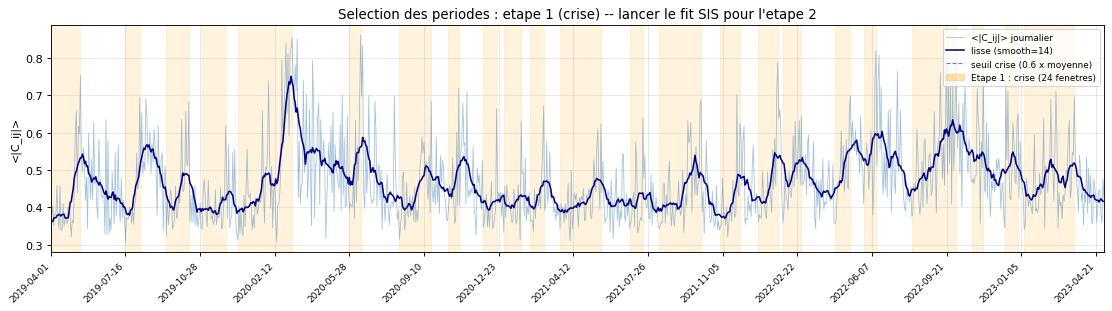

Etape 1 -- 24 fenetres de crise :
  2019-04-01 -> 2019-05-13  (30 j)
  2019-07-16 -> 2019-08-05  (15 j)
  2019-09-11 -> 2019-10-11  (23 j)
  2019-10-30 -> 2019-12-03  (24 j)
  2019-12-19 -> 2020-03-09  (54 j)
  2020-05-28 -> 2020-06-12  (12 j)
  2020-08-06 -> 2020-09-21  (32 j)
  2020-10-13 -> 2020-10-28  (12 j)
  2020-12-02 -> 2020-12-21  (14 j)
  2020-12-31 -> 2021-01-27  (18 j)
  2021-02-09 -> 2021-03-01  (14 j)
  2021-03-23 -> 2021-05-19  (41 j)
  2021-06-29 -> 2021-07-19  (14 j)
  2021-08-10 -> 2021-10-07  (42 j)
  2021-11-02 -> 2021-12-01  (21 j)
  2021-12-28 -> 2022-01-25  (20 j)
  2022-02-01 -> 2022-02-28  (19 j)
  2022-04-14 -> 2022-05-06  (16 j)
  2022-05-25 -> 2022-06-13  (13 j)
  2022-08-03 -> 2022-10-04  (44 j)
  2022-10-26 -> 2022-11-10  (12 j)
  2022-12-12 -> 2022-12-30  (14 j)
  2023-01-10 -> 2023-02-24  (32 j)
  2023-02-28 -> 2023-03-22  (17 j)

Etape 2 : pas encore calculee (executer les cellules suivantes : reseaux + fit SIS + selection).


In [ ]:
# ── PANNEAU : etape 1 (fenetres de crise) -- effet immediat des hyperparametres ─
#   Edite les hyperparametres ci-dessus puis relance CETTE cellule : la detection
#   de crise (etape 1) est recalculee ici meme et tracee aussitot, sans relancer
#   le fit SIS. L'etape 2 (rouge) se superpose seulement si `selected` existe deja.
intervals_raw, mc_smooth = increasing_intervals(mc_all, smooth=SMOOTH, min_len=MIN_LEN,
                                                merge_gap=MERGE_GAP, refine=REFINE)
intervals_chrono = sorted([(a, b) for a, b in intervals_raw
                           if np.nanmean(mc_all[a:b + 1]) > CRISIS_FACTOR * mean_mc],
                          key=lambda ab: ab[0])
sel_set = set(selected) if 'selected' in globals() else set()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(mc_all, color='steelblue', lw=0.7, alpha=0.5, label='<|C_ij|> journalier')
ax.plot(mc_smooth, color='navy', lw=1.4, label=f'lisse (smooth={SMOOTH})')
ax.axhline(CRISIS_FACTOR * mean_mc, color='gray', ls='--', lw=1,
           label=f'seuil crise ({CRISIS_FACTOR} x moyenne)')
for (a, b) in intervals_chrono:
    is_sel = (a, b) in sel_set
    ax.axvspan(a, b, color='red' if is_sel else 'orange', alpha=0.30 if is_sel else 0.13)
    if is_sel:
        ax.axvline(a, color='red', lw=0.8, alpha=0.6); ax.axvline(b, color='red', lw=0.8, alpha=0.6)
ax.axvspan(0, 0, color='orange', alpha=0.30, label=f'Etape 1 : crise ({len(intervals_chrono)} fenetres)')
if sel_set:
    ax.axvspan(0, 0, color='red', alpha=0.40, label=f'Etape 2 : selectionnees ({len(sel_set)})')
step = max(1, len(all_days) // 14)
ax.set_xticks(range(0, len(all_days), step))
ax.set_xticklabels([str(all_days[k]) for k in range(0, len(all_days), step)],
                   rotation=45, ha='right', fontsize=8)
ax.set_xlim(0, len(all_days) - 1)
ax.set_ylabel('<|C_ij|>'); ax.grid(alpha=0.3)
sub = 'etape 1 (crise) -> etape 2 (n>30 & R2>0.2)' if sel_set else "etape 1 (crise) -- lancer le fit SIS pour l'etape 2"
ax.set_title(f'Selection des periodes : {sub}')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout(); plt.show()

print(f'Etape 1 -- {len(intervals_chrono)} fenetres de crise :')
for (a, b) in intervals_chrono:
    tag = '   <== retenue (etape 2)' if (a, b) in sel_set else ''
    print(f'  {all_days[a]} -> {all_days[b]}  ({b - a + 1} j){tag}')
if sel_set:
    print(f'\nEtape 2 -- {len(sel_set)} periode(s) selectionnee(s) (n > {N_MIN}, R2 > {R2_PERIOD}).')
else:
    print('\nEtape 2 : pas encore calculee (executer les cellules suivantes : reseaux + fit SIS + selection).')

In [ ]:
# ── Fit SIS par periode : x_i(t) integre vs E_i empirique -> R2 (-> cache) ──
# CELLULE AUTO-SUFFISANTE : elle re-derive intervals_chrono, crisis_map et A_sis
# a partir des hyperparametres. Donc modifier un hyperparametre + relancer la
# cellule HYPERPARAMETRES puis CETTE cellule suffit : le cache se reactualise
# (pas besoin de relancer le panneau / la preparation).
SIS_MODELS = ['PMFG', 'VAR(1)', 'VAR(13)', 'Corr thr']

def build_filtered_corr(q, C=C_full):
    """Correlation seuillee prete pour le SIS : |C_ij| au-dessus du quantile q."""
    A = np.where(C >= np.quantile(C[mask_off], q), C, 0.0); np.fill_diagonal(A, 0)
    return prepare_for_sis(A)
A_sis = {'PMFG': A_pmfg, 'VAR(1)': prepare_for_sis(A_var1),
         'VAR(13)': prepare_for_sis(A_var13), 'Corr thr': build_filtered_corr(CORR_THRESHOLD)}

# fenetres globales (etape 1) re-derivees ICI a partir des hyperparametres
intervals_chrono = sorted(
    [(a, b) for a, b in increasing_intervals(mc_all, smooth=SMOOTH, min_len=MIN_LEN,
                                             merge_gap=MERGE_GAP, refine=REFINE)[0]
     if np.nanmean(mc_all[a:b + 1]) > CRISIS_FACTOR * mean_mc], key=lambda ab: ab[0])

# crise par actif (cachee ; signature = parametres de detection)
def _compute_crisis_map():
    cm = np.zeros((N, len(all_days)), dtype=bool)
    for i in range(N):
        y_i = E_daily_all[i]; thr = ASSET_FACTOR * np.nanmean(y_i)
        for a, b in increasing_intervals(y_i, smooth=SMOOTH, min_len=MIN_LEN,
                                         merge_gap=MERGE_GAP, refine=REFINE)[0]:
            if np.nanmean(y_i[a:b + 1]) > thr:
                cm[i, a:b + 1] = True
    return cm
crisis_map = disk_cache('crisis_map', f'af{ASSET_FACTOR}_s{SMOOTH}_ml{MIN_LEN}_mg{MERGE_GAP}_rf{REFINE}',
                        _compute_crisis_map)

def cache_signed(pa, pb):
    """{gi: dict(E_i signe, x0 signe, n_days)} pour les actifs en crise sur (pa, pb)."""
    rw = {}
    for gi in range(N):
        win = next(((a, b) for a, b in asset_runs(crisis_map[gi]) if b >= pa and a <= pb), None)
        if win is None:
            continue
        res = strong_rise(E_daily_all[gi, win[0]:win[1] + 1],
                          smooth=SR_SMOOTH, min_len=SR_MIN_LEN, min_gain=SR_MIN_GAIN)
        if res is not None:
            rw[gi] = (win[0] + res[2], win[0] + res[3])
    cache = {}
    for gi0, (A0, B0) in rw.items():
        days_p = list(all_days[A0:B0 + 1])
        dp = data[np.isin(data.index.date, days_p)].copy(); dp['day'] = dp.index.date
        days_s = sorted(dp['day'].unique()); n_days = len(days_s)
        Es = np.full((N, n_days), np.nan)
        for k, d in enumerate(days_s):
            chunk = dp[dp['day'] == d].drop(columns=['day']).values
            if len(chunk) < 3:
                continue
            C = np.nan_to_num(np.corrcoef(chunk.T), nan=0.0); np.fill_diagonal(C, 0)
            Es[:, k] = C.sum(axis=1) / (N - 1)
        valid = np.where(np.any(~np.isnan(Es), axis=0))[0]
        if len(valid) == 0:
            continue
        cache[gi0] = dict(E_i=Es[gi0], x0=Es[:, valid[0]], n_days=n_days)
    return cache

def integrate(cache, gi, A_model):
    """Trajectoire x_i(t) du SIS borne (x0 signe), recadree sur le temps de convergence."""
    d = cache[gi]; x0, n = d['x0'], d['n_days']
    x_eq = solve_ivp(ode_sis_bounded, (0, T_long), x0, args=(A_model, B_fit, R_fit),
                     method='LSODA', rtol=1e-6, atol=1e-9).y[gi, -1]
    tp = np.linspace(1e-3, T_long, 5000)
    sp = solve_ivp(ode_sis_bounded, (0, T_long), x0, args=(A_model, B_fit, R_fit),
                   t_eval=tp, method='LSODA', rtol=1e-6, atol=1e-9)
    above = np.where(sp.y[gi] >= (1 - tol_eq) * x_eq)[0]
    Tc = float(tp[above[0]]) if len(above) else T_long
    s = solve_ivp(ode_sis_bounded, (0, Tc), x0, args=(A_model, B_fit, R_fit),
                  t_eval=np.linspace(0, Tc, n), method='LSODA')
    return np.clip(s.y[gi], 1e-8, 1 - 1e-8)

def fits_for(pa, pb):
    """(cache, fits) ; fits[m] = (trajectoires, slopes) avec R2 par actif."""
    cache = cache_signed(pa, pb); fits = {}
    for m in SIS_MODELS:
        A_m, pad, sl = A_sis[m], {}, {}
        for gi in cache:
            E_i = cache[gi]['E_i']; xt = integrate(cache, gi, A_m)
            pad[gi] = (E_i, xt); ok = ~np.isnan(E_i)
            if ok.sum() >= 3:
                f = linregress(E_i[ok], xt[ok])
                sl[gi] = dict(slope=f.slope, r2=f.rvalue ** 2, n=int(ok.sum()))
        fits[m] = (pad, sl)
    return cache, fits

# signature sensible au CONTENU des fenetres + de la carte de crise (fraiches ci-dessus)
_sig = (f'N{N}_p{len(intervals_chrono)}_thr{CORR_THRESHOLD}_T{T_long}_B{B_fit}_R{R_fit}_tol{tol_eq}'
        f'_sr{SR_SMOOTH}-{SR_MIN_LEN}-{SR_MIN_GAIN}_{sig_of(intervals_chrono, crisis_map)}')
period_data = disk_cache('period_data', _sig,
                         lambda: {(pa, pb): fits_for(pa, pb) for (pa, pb) in intervals_chrono})
print(f'[params actifs] CRISIS_FACTOR={CRISIS_FACTOR} ASSET_FACTOR={ASSET_FACTOR} '
      f'CORR_THRESHOLD={CORR_THRESHOLD} R2_SEUIL={R2_SEUIL}')
print(f'{crisis_map.any(axis=1).sum()} actifs en crise ; {len(period_data)} periode(s) ajustee(s) ; '
      f'{len(intervals_chrono)} fenetres globales')

[cache] OK  crisis_map
[cache] OK  period_data
[params actifs] CRISIS_FACTOR=0.6 ASSET_FACTOR=0.6 CORR_THRESHOLD=0.85 R2_SEUIL=0.6
146 actifs en crise ; 24 periode(s) ajustee(s) ; 24 fenetres globales


In [ ]:
# ── Gros tableau recapitulatif : 1 ligne par (actif, periode) en crise, R2 par methode ─
rows = []
for (pa, pb) in intervals_chrono:
    cache, fits = period_data[(pa, pb)]
    for gi in cache:
        win = next(((a, b) for a, b in asset_runs(crisis_map[gi]) if b >= pa and a <= pb), None)
        if win is None:
            continue
        res = strong_rise(E_daily_all[gi, win[0]:win[1] + 1],
                          smooth=SR_SMOOTH, min_len=SR_MIN_LEN, min_gain=SR_MIN_GAIN)
        if res is None:
            continue
        A0, B0 = win[0] + res[2], win[0] + res[3]
        row = {'actif': asset_names[gi], 'debut': all_days[A0], 'fin': all_days[B0],
               'n_jours': B0 - A0 + 1, 'periode': f'{all_days[pa]}->{all_days[pb]}'}
        for m in SIS_MODELS:
            sl = fits[m][1].get(gi)
            row[f'R2_{m}'] = round(sl['r2'], 3) if sl is not None else np.nan
        rows.append(row)
R2_COLS = [f'R2_{m}' for m in SIS_MODELS]
crise_df = pd.DataFrame(rows)
crise_df = (crise_df.assign(_r2max=crise_df[R2_COLS].max(axis=1))
            .sort_values(['periode', '_r2max'], ascending=[True, False]).drop(columns='_r2max'))
crise_df.to_csv('results/actifs_crise_R2.csv', index=False)
print(f'{len(crise_df)} lignes (actif x periode) ; R2 par methode -> results/actifs_crise_R2.csv')
crise_df

868 lignes (actif x periode) ; R2 par methode -> results/actifs_crise_R2.csv


,actif,debut,fin,n_jours,periode,R2_PMFG,R2_VAR(1),R2_VAR(13),R2_Corr thr
1,AMZN,2019-04-26,2019-05-13,12,2019-04-01->2019-05-13,0.894,0.912,0.916,0.900
40,CAT,2019-04-26,2019-05-13,12,2019-04-01->2019-05-13,0.784,0.813,0.838,0.843
24,TD,2019-04-26,2019-05-13,12,2019-04-01->2019-05-13,0.783,0.778,0.769,0.831
36,MRK,2019-04-26,2019-05-13,12,2019-04-01->2019-05-13,0.779,0.743,0.759,0.717
38,VRTX,2019-04-25,2019-05-13,13,2019-04-01->2019-05-13,0.574,0.481,0.564,0.771
...,...,...,...,...,...,...,...,...,...
853,AMGN,2023-01-18,2023-02-16,22,2023-02-28->2023-03-22,0.038,0.050,0.050,0.041
862,GOOG,2023-01-19,2023-02-27,27,2023-02-28->2023-03-22,0.031,0.032,0.031,0.030
847,CVX,2023-01-05,2023-02-24,35,2023-02-28->2023-03-22,0.030,0.028,0.029,0.031
846,BP,2022-12-29,2023-03-15,52,2023-02-28->2023-03-22,0.021,0.024,0.022,0.023


In [ ]:
# ── Selection sur les R2 : lignes dont la meilleure methode depasse R2_SEUIL ─
crise_sel = crise_df.assign(_r2max=crise_df[R2_COLS].max(axis=1))
crise_sel = (crise_sel[crise_sel['_r2max'] > R2_SEUIL]
             .sort_values('_r2max', ascending=False).drop(columns='_r2max'))
print(f'{len(crise_sel)} lignes avec R2 max > {R2_SEUIL}  ({crise_sel.actif.nunique()} actifs distincts)')
# periodes retenues pour le graphe : celles avec au moins un fit R2 > seuil
selected = [(pa, pb) for (pa, pb) in intervals_chrono
            if any(sl['r2'] > R2_SEUIL for m in SIS_MODELS for sl in period_data[(pa, pb)][1][m][1].values())]
print(f'{len(selected)} periode(s) avec >= 1 fit R2 > {R2_SEUIL}')
crise_sel

43 lignes avec R2 max > 0.6  (40 actifs distincts)
9 periode(s) avec >= 1 fit R2 > 0.6


,actif,debut,fin,n_jours,periode,R2_PMFG,R2_VAR(1),R2_VAR(13),R2_Corr thr
1,AMZN,2019-04-26,2019-05-13,12,2019-04-01->2019-05-13,0.894,0.912,0.916,0.900
40,CAT,2019-04-26,2019-05-13,12,2019-04-01->2019-05-13,0.784,0.813,0.838,0.843
24,TD,2019-04-26,2019-05-13,12,2019-04-01->2019-05-13,0.783,0.778,0.769,0.831
76,DIS,2019-07-25,2019-08-16,17,2019-07-16->2019-08-05,0.807,0.800,0.801,0.808
36,MRK,2019-04-26,2019-05-13,12,2019-04-01->2019-05-13,0.779,0.743,0.759,0.717
38,VRTX,2019-04-25,2019-05-13,13,2019-04-01->2019-05-13,0.574,0.481,0.564,0.771
248,EL,2020-05-29,2020-06-16,13,2020-05-28->2020-06-12,0.750,0.708,0.730,0.701
21,MC,2019-04-26,2019-05-13,12,2019-04-01->2019-05-13,0.703,0.724,0.742,0.628
563,COST,2022-04-04,2022-05-06,24,2022-04-14->2022-05-06,0.728,0.734,0.737,0.663
97,CP,2019-07-22,2019-08-14,18,2019-07-16->2019-08-05,0.715,0.690,0.683,0.734


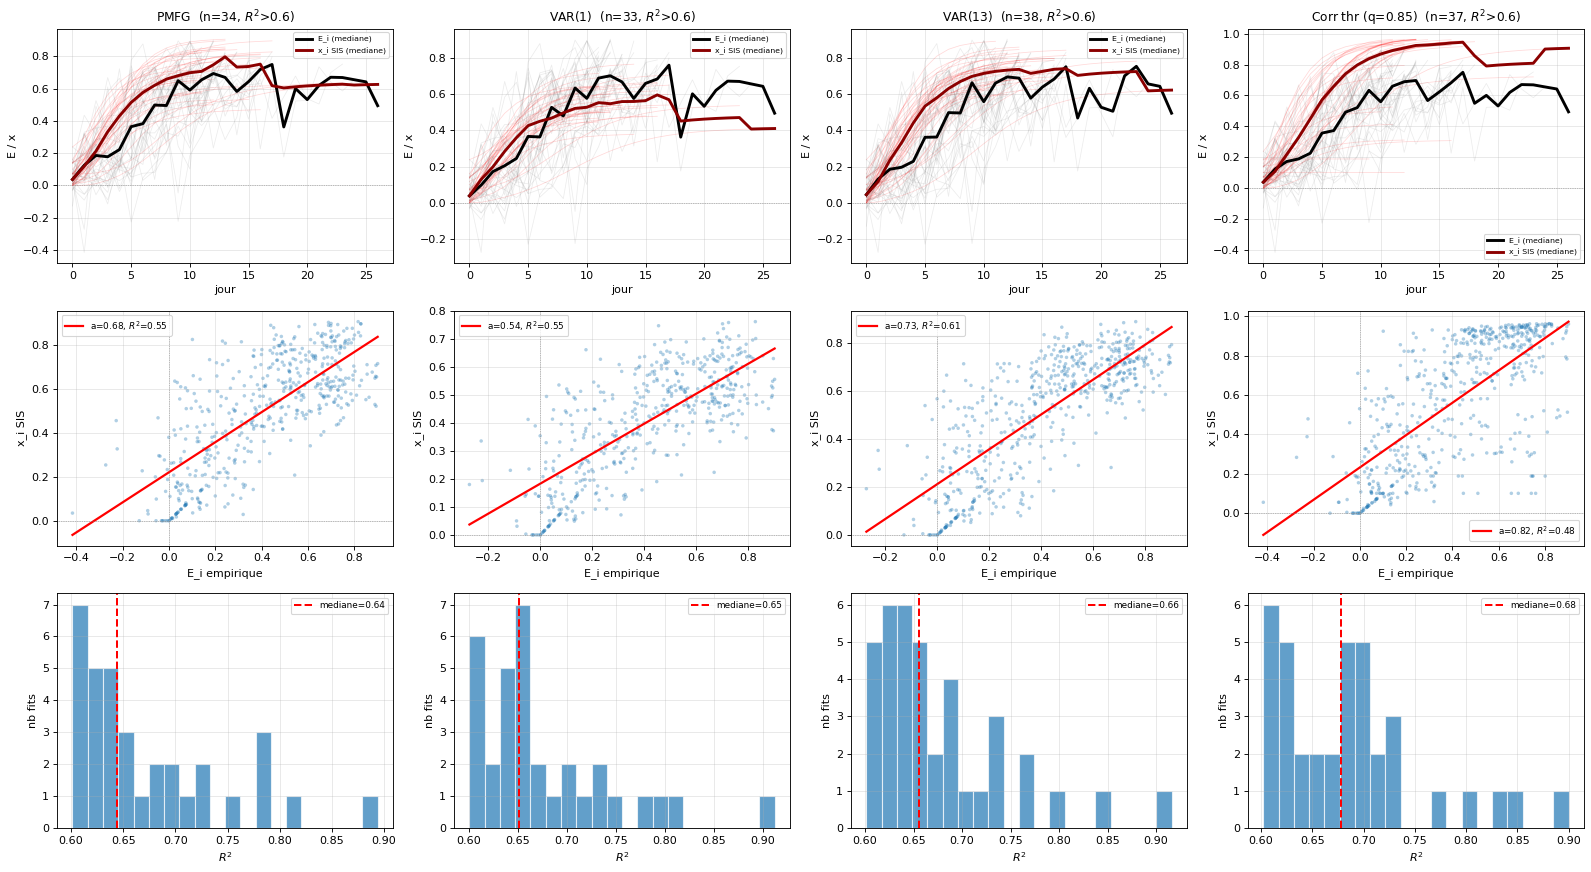

In [ ]:
# ── Resultat 2 : par methode, evolution temporelle | scatter | distribution R2 ─
# On garde tous les fits R2 > R2_SEUIL (toutes periodes selectionnees).
def _med(series):                     # mediane par jour relatif (padding NaN)
    if not series:
        return np.array([])
    L = max(len(v) for v in series)
    M = np.full((len(series), L), np.nan)
    for r, v in enumerate(series):
        M[r, :len(v)] = v
    return np.nanmedian(M, axis=0)

fig, axes = plt.subplots(3, len(SIS_MODELS), figsize=(5 * len(SIS_MODELS), 11))
for j, m in enumerate(SIS_MODELS):
    Es, Xs, E_all, X_all, r2s = [], [], [], [], []
    for (pa, pb) in selected:
        fits = period_data[(pa, pb)][1]
        for gi, sl in fits[m][1].items():
            if sl['r2'] > R2_SEUIL:
                E_i, x_traj = fits[m][0][gi]; ok = ~np.isnan(E_i)
                Es.append(E_i); Xs.append(x_traj)
                E_all.append(E_i[ok]); X_all.append(x_traj[ok]); r2s.append(sl['r2'])

    # haut : evolution temporelle E_i (gris) / x_i (rouge) + medianes en fonce
    axt = axes[0, j]
    for E_i, x_traj in zip(Es, Xs):
        ok = ~np.isnan(E_i)
        axt.plot(np.arange(len(E_i))[ok], E_i[ok], color='gray', alpha=0.15, lw=0.7)
        axt.plot(np.arange(len(x_traj)), x_traj, color='red', alpha=0.15, lw=0.7)
    med_E, med_X = _med(Es), _med(Xs)
    if len(med_E):
        axt.plot(np.arange(len(med_E)), med_E, color='black', lw=2.6, label='E_i (mediane)')
        axt.plot(np.arange(len(med_X)), med_X, color='darkred', lw=2.6, label='x_i SIS (mediane)')
    axt.axhline(0, color='gray', lw=0.6, ls=':')
    m_lbl = f'{m} (q={CORR_THRESHOLD})' if m == 'Corr thr' else m
    axt.set_title(rf'{m_lbl}  (n={len(Es)}, $R^2$>{R2_SEUIL})', fontsize=11)
    axt.set_xlabel('jour'); axt.set_ylabel('E / x'); axt.grid(alpha=0.3)
    if Es:
        axt.legend(fontsize=7)

    # milieu : scatter x_i SIS vs E_i + regression agregee
    axs = axes[1, j]
    if E_all:
        Ec, Xc = np.concatenate(E_all), np.concatenate(X_all)
        axs.scatter(Ec, Xc, s=10, color='#1f77b4', alpha=0.35, edgecolors='none')
        f = linregress(Ec, Xc); xs = np.linspace(Ec.min(), Ec.max(), 50)
        axs.plot(xs, f.slope * xs + f.intercept, color='red', lw=2,
                 label=rf'a={f.slope:.2f}, $R^2$={f.rvalue**2:.2f}')
        axs.legend(fontsize=8)
    axs.axhline(0, color='gray', lw=0.6, ls=':'); axs.axvline(0, color='gray', lw=0.6, ls=':')
    axs.set_xlabel('E_i empirique'); axs.set_ylabel('x_i SIS'); axs.grid(alpha=0.3)

    # bas : distribution des R2 (mediane en pointilles rouges)
    axd = axes[2, j]
    if r2s:
        axd.hist(r2s, bins=20, color='#1f77b4', alpha=0.7, edgecolor='white')
        med_r2 = np.median(r2s)
        axd.axvline(med_r2, color='red', ls='--', lw=1.8, label=f'mediane={med_r2:.2f}')
        axd.legend(fontsize=8)
    axd.set_xlabel(r'$R^2$'); axd.set_ylabel('nb fits'); axd.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## Expérience — détection des périodes sans valeur absolue

Variante de l'étape 1 : on agrège les corrélations **signées** (`mean(C_ij)` au lieu de `mean(|C_ij|)`) pour détecter les fenêtres de crise, et on compare aux fenêtres obtenues avec la valeur absolue. Ne modifie pas le pipeline principal au-dessus.

[cache] OK  E_daily_signed


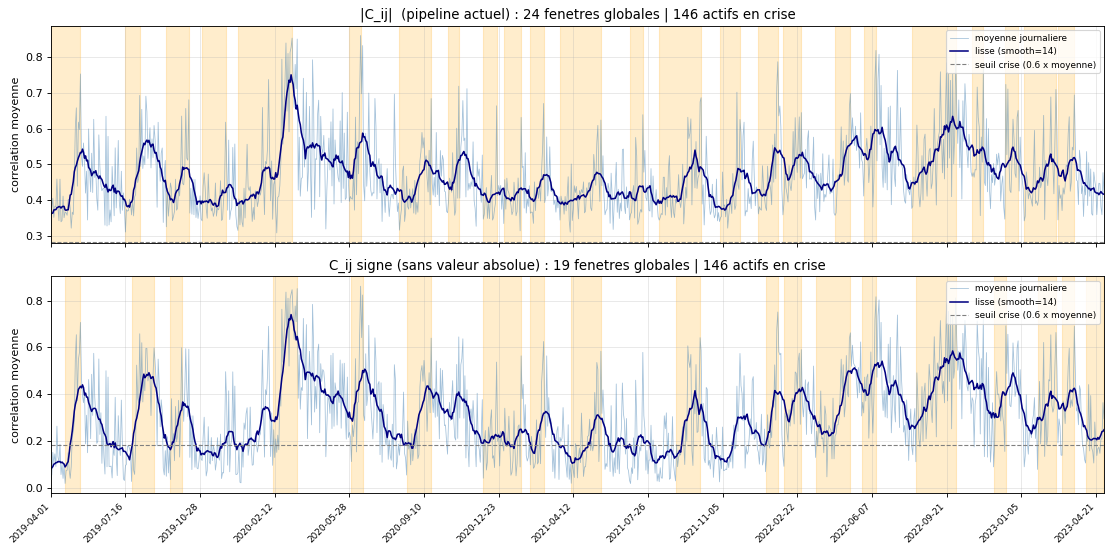

|C| (abs) : boucle1 24 fenetres ; boucle2 146 actifs en crise ; <C>=0.4686
signe     : boucle1 19 fenetres ; boucle2 146 actifs en crise ; <C>=0.3040
  2019-04-22 -> 2019-05-13  (16 j)
  2019-07-24 -> 2019-08-23  (23 j)
  2019-09-17 -> 2019-10-02  (12 j)
  2020-02-10 -> 2020-03-16  (25 j)
  2020-06-01 -> 2020-06-16  (12 j)
  2020-08-17 -> 2020-09-21  (25 j)
  2020-12-02 -> 2021-01-27  (38 j)
  2021-02-09 -> 2021-03-01  (14 j)
  2021-04-08 -> 2021-05-19  (30 j)
  2021-09-01 -> 2021-10-06  (25 j)
  2022-01-06 -> 2022-01-25  (13 j)
  2022-02-02 -> 2022-02-28  (18 j)
  2022-03-18 -> 2022-05-06  (35 j)
  2022-05-23 -> 2022-06-13  (15 j)
  2022-08-09 -> 2022-10-04  (40 j)
  2022-11-25 -> 2022-12-13  (13 j)
  2023-01-30 -> 2023-02-24  (19 j)
  2023-03-06 -> 2023-03-22  (13 j)
  2023-04-06 -> 2023-05-02  (18 j)


In [ ]:
# ── EXPERIENCE : trouver les periodes SANS valeur absolue (les 2 boucles) ────
# On signe les correlations dans les DEUX boucles de selection des periodes :
#   boucle 1 (globale) : mc = moyenne des C_ij SIGNES -> fenetres globales
#   boucle 2 (par actif): E_i = somme des C_ij SIGNES -> crise par actif
def _compute_E_signed():
    da = data.copy(); da['day'] = da.index.date
    days = np.array(sorted(da['day'].unique()))
    E = np.full((N, len(days)), np.nan)
    for k, dd in enumerate(days):
        chunk = da[da['day'] == dd].drop(columns=['day']).values
        if len(chunk) < 3:
            continue
        with np.errstate(invalid='ignore', divide='ignore'):
            C = np.nan_to_num(np.corrcoef(chunk.T), nan=0.0)
        np.fill_diagonal(C, 0)
        E[:, k] = C.sum(axis=1) / (N - 1)       # SIGNE : pas de np.abs
    return E

E_daily_signed = disk_cache('E_daily_signed', f'N{N}T{len(data)}', _compute_E_signed)
mc_signed = np.nanmean(E_daily_signed, axis=0)          # = moyenne des C_ij signes
mean_mc_signed = np.nanmean(mc_signed)

# boucle 1 : fenetres GLOBALES sur la correlation signee
iv_raw_s, mc_signed_smooth = increasing_intervals(mc_signed, smooth=SMOOTH, min_len=MIN_LEN,
                                                  merge_gap=MERGE_GAP, refine=REFINE)
intervals_signed = sorted([(a, b) for a, b in iv_raw_s
                           if np.nanmean(mc_signed[a:b + 1]) > CRISIS_FACTOR * mean_mc_signed],
                          key=lambda ab: ab[0])

# boucle 2 : crise PAR ACTIF sur E_i signe
def _crisis_map_from(E):
    cm = np.zeros((N, E.shape[1]), dtype=bool)
    for i in range(N):
        y = E[i]; thr = ASSET_FACTOR * np.nanmean(y)
        for a, b in increasing_intervals(y, smooth=SMOOTH, min_len=MIN_LEN,
                                         merge_gap=MERGE_GAP, refine=REFINE)[0]:
            if np.nanmean(y[a:b + 1]) > thr:
                cm[i, a:b + 1] = True
    return cm
crisis_map_signed = _crisis_map_from(E_daily_signed)

# ── Comparaison : |C| (haut) vs signe (bas) ; fenetres globales en couleur ──
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
panels = [(mc_all, mc_smooth, intervals_chrono, crisis_map, mean_mc, '|C_ij|  (pipeline actuel)'),
          (mc_signed, mc_signed_smooth, intervals_signed, crisis_map_signed, mean_mc_signed, 'C_ij signe (sans valeur absolue)')]
for ax, (mc_v, mc_s, ivs, cm, mv, lab) in zip(axes, panels):
    ax.plot(mc_v, color='steelblue', lw=0.7, alpha=0.5, label='moyenne journaliere')
    ax.plot(mc_s, color='navy', lw=1.4, label=f'lisse (smooth={SMOOTH})')
    ax.axhline(CRISIS_FACTOR * mv, color='gray', ls='--', lw=1, label=f'seuil crise ({CRISIS_FACTOR} x moyenne)')
    for (a, b) in ivs:
        ax.axvspan(a, b, color='orange', alpha=0.20)
    ax.set_title(f'{lab} : {len(ivs)} fenetres globales | {int(cm.any(1).sum())} actifs en crise')
    ax.set_ylabel('correlation moyenne'); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc='upper right')
step = max(1, len(all_days) // 14)
axes[-1].set_xticks(range(0, len(all_days), step))
axes[-1].set_xticklabels([str(all_days[k]) for k in range(0, len(all_days), step)],
                         rotation=45, ha='right', fontsize=8)
axes[-1].set_xlim(0, len(all_days) - 1)
plt.tight_layout(); plt.show()

print(f'|C| (abs) : boucle1 {len(intervals_chrono)} fenetres ; boucle2 {int(crisis_map.any(1).sum())} actifs en crise ; <C>={mean_mc:.4f}')
print(f'signe     : boucle1 {len(intervals_signed)} fenetres ; boucle2 {int(crisis_map_signed.any(1).sum())} actifs en crise ; <C>={mean_mc_signed:.4f}')
for (a, b) in intervals_signed:
    print(f'  {all_days[a]} -> {all_days[b]}  ({b - a + 1} j)')

## Les trois courbes (Résultat 2) avec C_ij signé

Mêmes 3 vues (évolution temporelle / scatter / distribution R²), mais la **détection des périodes** (les 2 passes : grossière `increasing_intervals` + fine `strong_rise`) utilise des corrélations **signées** (`mc_signed`, `E_daily_signed`, `crisis_map_signed`, `intervals_signed` calculés dans la cellule au-dessus). On réutilise exactement `fits_for` via un rebind temporaire des globales. Les réseaux SIS (A_sis) restent inchangés.

[cache] OK  period_data_sig
[C_ij signe] 19 periodes -> 19 retenues (>=1 fit R2>0.6)


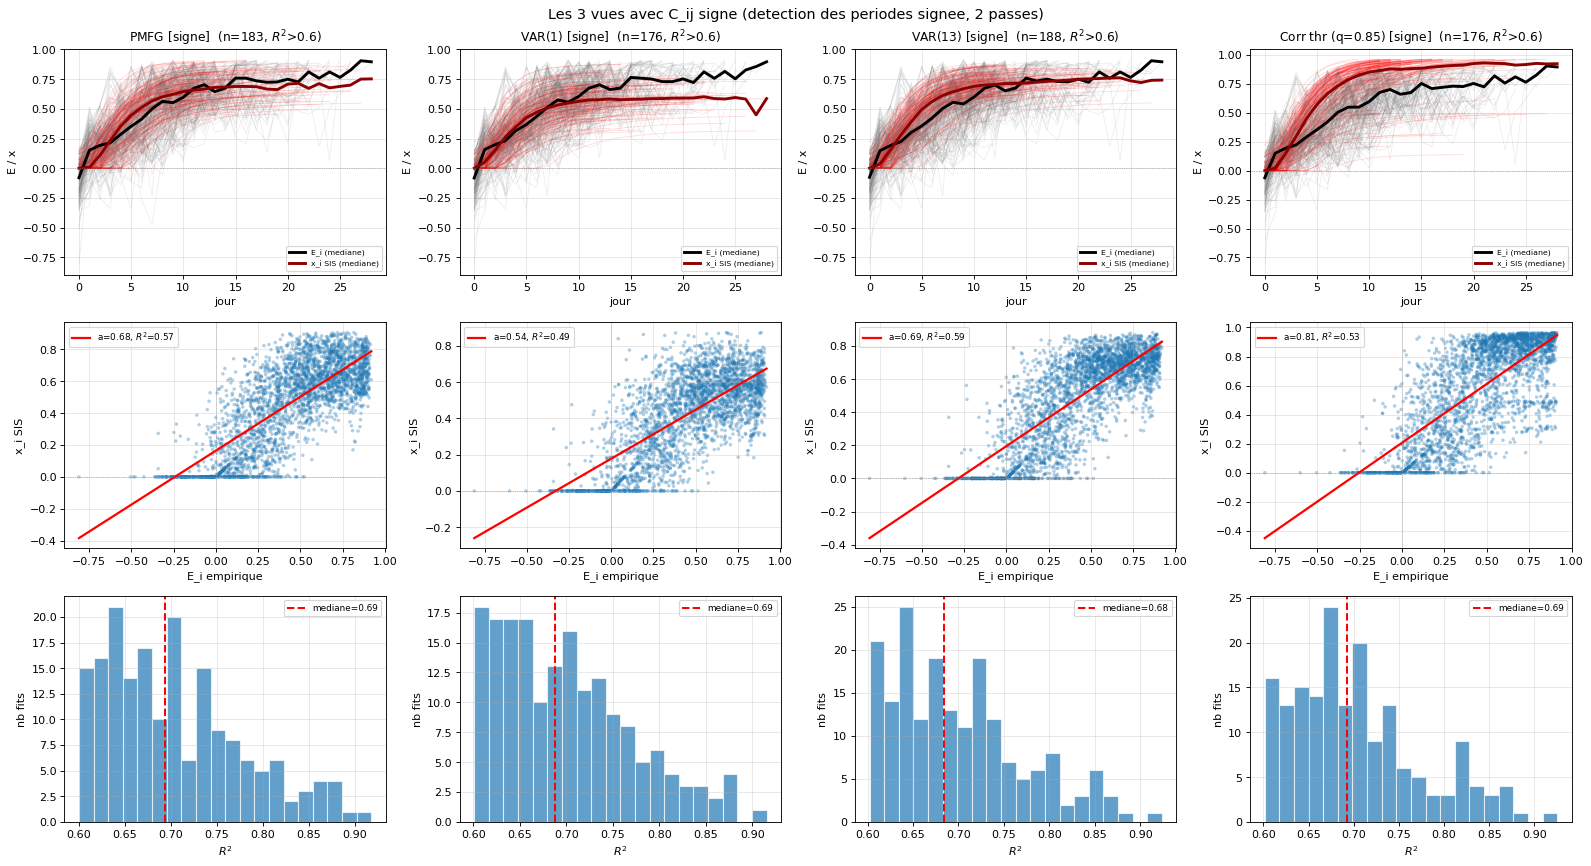

In [ ]:
# ── Les 3 courbes (Resultat 2) AVEC C_ij signe : pipeline complet signe ──────
# Reutilise EXACTEMENT fits_for, mais sur la detection signee (rebind temporaire
# de crisis_map / E_daily_all vers leurs versions signees calculees ci-dessus).
def _med(series):
    if not series:
        return np.array([])
    L = max(len(v) for v in series)
    M = np.full((len(series), L), np.nan)
    for r, v in enumerate(series):
        M[r, :len(v)] = v
    return np.nanmedian(M, axis=0)

_cm_bak, _ed_bak = crisis_map, E_daily_all
crisis_map, E_daily_all = crisis_map_signed, E_daily_signed
try:
    _sig_sig = (f'SIG_p{len(intervals_signed)}_thr{CORR_THRESHOLD}_T{T_long}_B{B_fit}_R{R_fit}'
                f'_tol{tol_eq}_sr{SR_SMOOTH}-{SR_MIN_LEN}-{SR_MIN_GAIN}_{sig_of(intervals_signed, crisis_map_signed)}')
    period_data_sig = disk_cache('period_data_sig', _sig_sig,
                                 lambda: {(pa, pb): fits_for(pa, pb) for (pa, pb) in intervals_signed})
finally:
    crisis_map, E_daily_all = _cm_bak, _ed_bak     # restaure les globales |C|

selected_sig = [(pa, pb) for (pa, pb) in intervals_signed
                if any(sl['r2'] > R2_SEUIL for m in SIS_MODELS
                       for sl in period_data_sig[(pa, pb)][1][m][1].values())]
print(f'[C_ij signe] {len(intervals_signed)} periodes -> {len(selected_sig)} retenues (>=1 fit R2>{R2_SEUIL})')

fig, axes = plt.subplots(3, len(SIS_MODELS), figsize=(5 * len(SIS_MODELS), 11))
for j, m in enumerate(SIS_MODELS):
    Es, Xs, E_all, X_all, r2s = [], [], [], [], []
    for (pa, pb) in selected_sig:
        fits = period_data_sig[(pa, pb)][1]
        for gi, sl in fits[m][1].items():
            if sl['r2'] > R2_SEUIL:
                E_i, x_traj = fits[m][0][gi]; ok = ~np.isnan(E_i)
                Es.append(E_i); Xs.append(x_traj)
                E_all.append(E_i[ok]); X_all.append(x_traj[ok]); r2s.append(sl['r2'])

    # haut : evolution temporelle E_i (gris) / x_i (rouge) + medianes en fonce
    axt = axes[0, j]
    for E_i, x_traj in zip(Es, Xs):
        ok = ~np.isnan(E_i)
        axt.plot(np.arange(len(E_i))[ok], E_i[ok], color='gray', alpha=0.15, lw=0.7)
        axt.plot(np.arange(len(x_traj)), x_traj, color='red', alpha=0.15, lw=0.7)
    med_E, med_X = _med(Es), _med(Xs)
    if len(med_E):
        axt.plot(np.arange(len(med_E)), med_E, color='black', lw=2.6, label='E_i (mediane)')
        axt.plot(np.arange(len(med_X)), med_X, color='darkred', lw=2.6, label='x_i SIS (mediane)')
    axt.axhline(0, color='gray', lw=0.6, ls=':')
    m_lbl = f'{m} (q={CORR_THRESHOLD})' if m == 'Corr thr' else m
    axt.set_title(rf'{m_lbl} [signe]  (n={len(Es)}, $R^2$>{R2_SEUIL})', fontsize=11)
    axt.set_xlabel('jour'); axt.set_ylabel('E / x'); axt.grid(alpha=0.3)
    if Es:
        axt.legend(fontsize=7)

    # milieu : scatter x_i SIS vs E_i + regression agregee
    axs = axes[1, j]
    if E_all:
        Ec, Xc = np.concatenate(E_all), np.concatenate(X_all)
        axs.scatter(Ec, Xc, s=10, color='#1f77b4', alpha=0.35, edgecolors='none')
        f = linregress(Ec, Xc); xs = np.linspace(Ec.min(), Ec.max(), 50)
        axs.plot(xs, f.slope * xs + f.intercept, color='red', lw=2,
                 label=rf'a={f.slope:.2f}, $R^2$={f.rvalue**2:.2f}')
        axs.legend(fontsize=8)
    axs.axhline(0, color='gray', lw=0.6, ls=':'); axs.axvline(0, color='gray', lw=0.6, ls=':')
    axs.set_xlabel('E_i empirique'); axs.set_ylabel('x_i SIS'); axs.grid(alpha=0.3)

    # bas : distribution des R2 (mediane en pointilles rouges)
    axd = axes[2, j]
    if r2s:
        axd.hist(r2s, bins=20, color='#1f77b4', alpha=0.7, edgecolor='white')
        med_r2 = np.median(r2s)
        axd.axvline(med_r2, color='red', ls='--', lw=1.8, label=f'mediane={med_r2:.2f}')
        axd.legend(fontsize=8)
    axd.set_xlabel(r'$R^2$'); axd.set_ylabel('nb fits'); axd.grid(alpha=0.3)

plt.suptitle('Les 3 vues avec C_ij signe (detection des periodes signee, 2 passes)', fontsize=13)
plt.tight_layout(); plt.show()

## Expérience — balayage du seuil q de la « Corr thr » (|C|)

Le réseau **« Corr thr »** est la matrice de corrélation en **valeur absolue** `C_full = |corrcoef|` (calculée en début de notebook dans `_compute_base`) seuillée au quantile `q` via `build_filtered_corr(q)`. Ici on fait **varier q** de 0.50 à 0.95 (pas 0.05).

Seule la méthode Corr thr dépend de q (PMFG / VAR(1) / VAR(13) sont inchangés) : on réutilise les caches par actif (`period_data[...][0]`, indépendants de q) et on relance uniquement `integrate(...)` + la régression `x_i ↔ E_i`. Le balayage est mis en cache (`qsweep_corrthr`).

Pour chaque q on retrace les **trois vues** du « Résultat 2 » (évolution temporelle E_i↔x_i, scatter x_i↔E_i + régression agrégée, distribution des R²) sur tous les actifs en crise de toutes les périodes ayant **R² > R2_SEUIL**, puis on compte combien de fits et d'**actifs distincts** dépassent ce seuil — d'abord en résumé (n vs q), ensuite vue par vue.

In [ ]:
# ── Balayage du seuil q de 'Corr thr' (|C|) : refit SIS de la SEULE methode Corr thr ─
# Reutilise les caches par actif (period_data[...][0], independants de q). Seul ce
# reseau depend de q (PMFG / VAR inchanges). Pour chaque q : fits sur TOUS les actifs
# en crise, TOUTES les periodes (intervals_chrono) -> R2 par fit.
# NB1 : iterer toutes les periodes puis filtrer R2>seuil equivaut, pour la colonne Corr
#       thr, a passer par 'selected' (toute periode portant un fit > seuil y est de toute facon).
# NB2 : _integrate_fast == integrate() mais x_eq est lu sur le dernier point de la
#       trajectoire (on supprime la 1re integration redondante a T_long) -> ~2x plus
#       rapide, resultat identique. Les seuils tournent en parallele (joblib).
from joblib import Parallel, delayed
# pas grossier (0.05) jusqu'a 0.80, puis fin (0.01) de 0.80 a 0.95 (zone du saut)
Q_SWEEP = np.round(np.concatenate([np.arange(0.50, 0.80, 0.05),
                                   np.arange(0.80, 0.96, 0.01)]), 2)

def _integrate_fast(cache, gi, A):
    """integrate() sans la 1re integration redondante : x_eq = dernier point de la
    trajectoire 5000-pts ; trajectoire recadree sur le temps de convergence Tc."""
    d = cache[gi]; x0, n = d['x0'], d['n_days']
    tp = np.linspace(1e-3, T_long, 5000)
    sp = solve_ivp(ode_sis_bounded, (0, T_long), x0, args=(A, B_fit, R_fit),
                   t_eval=tp, method='LSODA', rtol=1e-6, atol=1e-9)
    x_eq = sp.y[gi, -1]
    above = np.where(sp.y[gi] >= (1 - tol_eq) * x_eq)[0]
    Tc = float(tp[above[0]]) if len(above) else T_long
    s = solve_ivp(ode_sis_bounded, (0, Tc), x0, args=(A, B_fit, R_fit),
                  t_eval=np.linspace(0, Tc, n), method='LSODA')
    return np.clip(s.y[gi], 1e-8, 1 - 1e-8)

def corr_thr_fits(q):
    """Fits 'Corr thr' au quantile q sur tous les actifs en crise (toutes periodes).
    Renvoie (Es, Xs, E_all, X_all, r2s, keys) ; key = (pa, pb, gi)."""
    A_q = build_filtered_corr(q)
    Es, Xs, E_all, X_all, r2s, keys = [], [], [], [], [], []
    for (pa, pb) in intervals_chrono:
        cache = period_data[(pa, pb)][0]
        for gi in cache:
            E_i = cache[gi]['E_i']; xt = _integrate_fast(cache, gi, A_q)
            ok = ~np.isnan(E_i)
            if ok.sum() < 3:
                continue
            f = linregress(E_i[ok], xt[ok])
            Es.append(E_i); Xs.append(xt)
            E_all.append(E_i[ok]); X_all.append(xt[ok])
            r2s.append(f.rvalue ** 2); keys.append((pa, pb, gi))
    return Es, Xs, E_all, X_all, r2s, keys

sig_q = sig_of(Q_SWEEP, intervals_chrono, crisis_map, B_fit, R_fit, T_long, tol_eq, 'fast')
def _compute_sweep():
    res = Parallel(n_jobs=min(len(Q_SWEEP), os.cpu_count()))(
        delayed(corr_thr_fits)(q) for q in Q_SWEEP)
    return {round(float(q), 2): r for q, r in zip(Q_SWEEP, res)}
sweep = disk_cache('qsweep_corrthr', sig_q, _compute_sweep)
print(f'Balayage q : {len(Q_SWEEP)} seuils de {Q_SWEEP[0]:.2f} a {Q_SWEEP[-1]:.2f} ; '
      f'{len(sweep[round(float(Q_SWEEP[0]), 2)][4])} fits par seuil (actifs en crise x periodes)')

[cache] OK  qsweep_corrthr
Balayage q : 23 seuils de 0.50 a 0.95 ; 868 fits par seuil (actifs en crise x periodes)


q=0.50 :  40 fits R2>0.6  ( 39 actifs distincts)  mediane R2(>seuil)=0.672
q=0.55 :  38 fits R2>0.6  ( 38 actifs distincts)  mediane R2(>seuil)=0.684
q=0.60 :  39 fits R2>0.6  ( 39 actifs distincts)  mediane R2(>seuil)=0.676
q=0.65 :  38 fits R2>0.6  ( 38 actifs distincts)  mediane R2(>seuil)=0.683
q=0.70 :  36 fits R2>0.6  ( 36 actifs distincts)  mediane R2(>seuil)=0.675
q=0.75 :  36 fits R2>0.6  ( 35 actifs distincts)  mediane R2(>seuil)=0.680
q=0.80 :  36 fits R2>0.6  ( 35 actifs distincts)  mediane R2(>seuil)=0.676
q=0.80 :  36 fits R2>0.6  ( 35 actifs distincts)  mediane R2(>seuil)=0.676
q=0.81 :  36 fits R2>0.6  ( 35 actifs distincts)  mediane R2(>seuil)=0.676
q=0.82 :  36 fits R2>0.6  ( 35 actifs distincts)  mediane R2(>seuil)=0.676
q=0.83 :  37 fits R2>0.6  ( 35 actifs distincts)  mediane R2(>seuil)=0.676
q=0.84 :  37 fits R2>0.6  ( 35 actifs distincts)  mediane R2(>seuil)=0.675
q=0.85 :  37 fits R2>0.6  ( 35 actifs distincts)  mediane R2(>seuil)=0.678
q=0.86 :  38 fits R2>0.6 

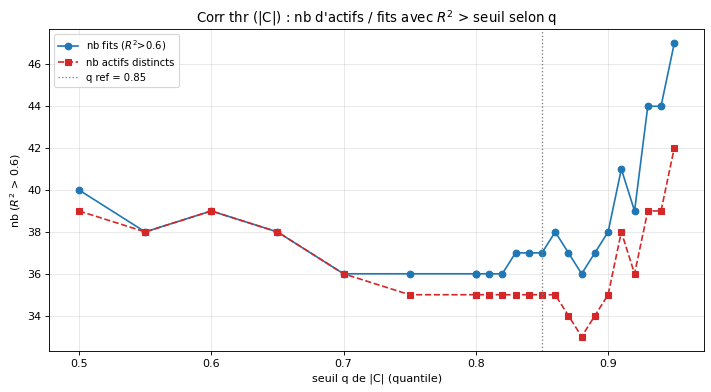

In [ ]:
# ── Resume : nb de fits / actifs distincts avec R2 > R2_SEUIL en fonction de q ──
n_fits, n_assets, med_r2 = [], [], []
for q in Q_SWEEP:
    *_, r2s, keys = sweep[round(float(q), 2)]
    good = [k for k, r in zip(keys, r2s) if r > R2_SEUIL]
    mr = np.median([r for r in r2s if r > R2_SEUIL]) if good else np.nan
    n_fits.append(len(good)); n_assets.append(len({gi for (_, _, gi) in good})); med_r2.append(mr)
    print(f'q={q:.2f} : {len(good):3d} fits R2>{R2_SEUIL}  '
          f'({n_assets[-1]:3d} actifs distincts)  mediane R2(>seuil)={mr:.3f}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(Q_SWEEP, n_fits,   'o-',  color='#1f77b4', label=rf'nb fits ($R^2$>{R2_SEUIL})')
ax.plot(Q_SWEEP, n_assets, 's--', color='#d62728', label='nb actifs distincts')
ax.axvline(CORR_THRESHOLD, color='gray', ls=':', lw=1.2, label=f'q ref = {CORR_THRESHOLD}')
ax.set_xlabel('seuil q de |C| (quantile)'); ax.set_ylabel(rf'nb ($R^2$ > {R2_SEUIL})')
ax.set_title("Corr thr (|C|) : nb d'actifs / fits avec $R^2$ > seuil selon q")
ax.legend(fontsize=9); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

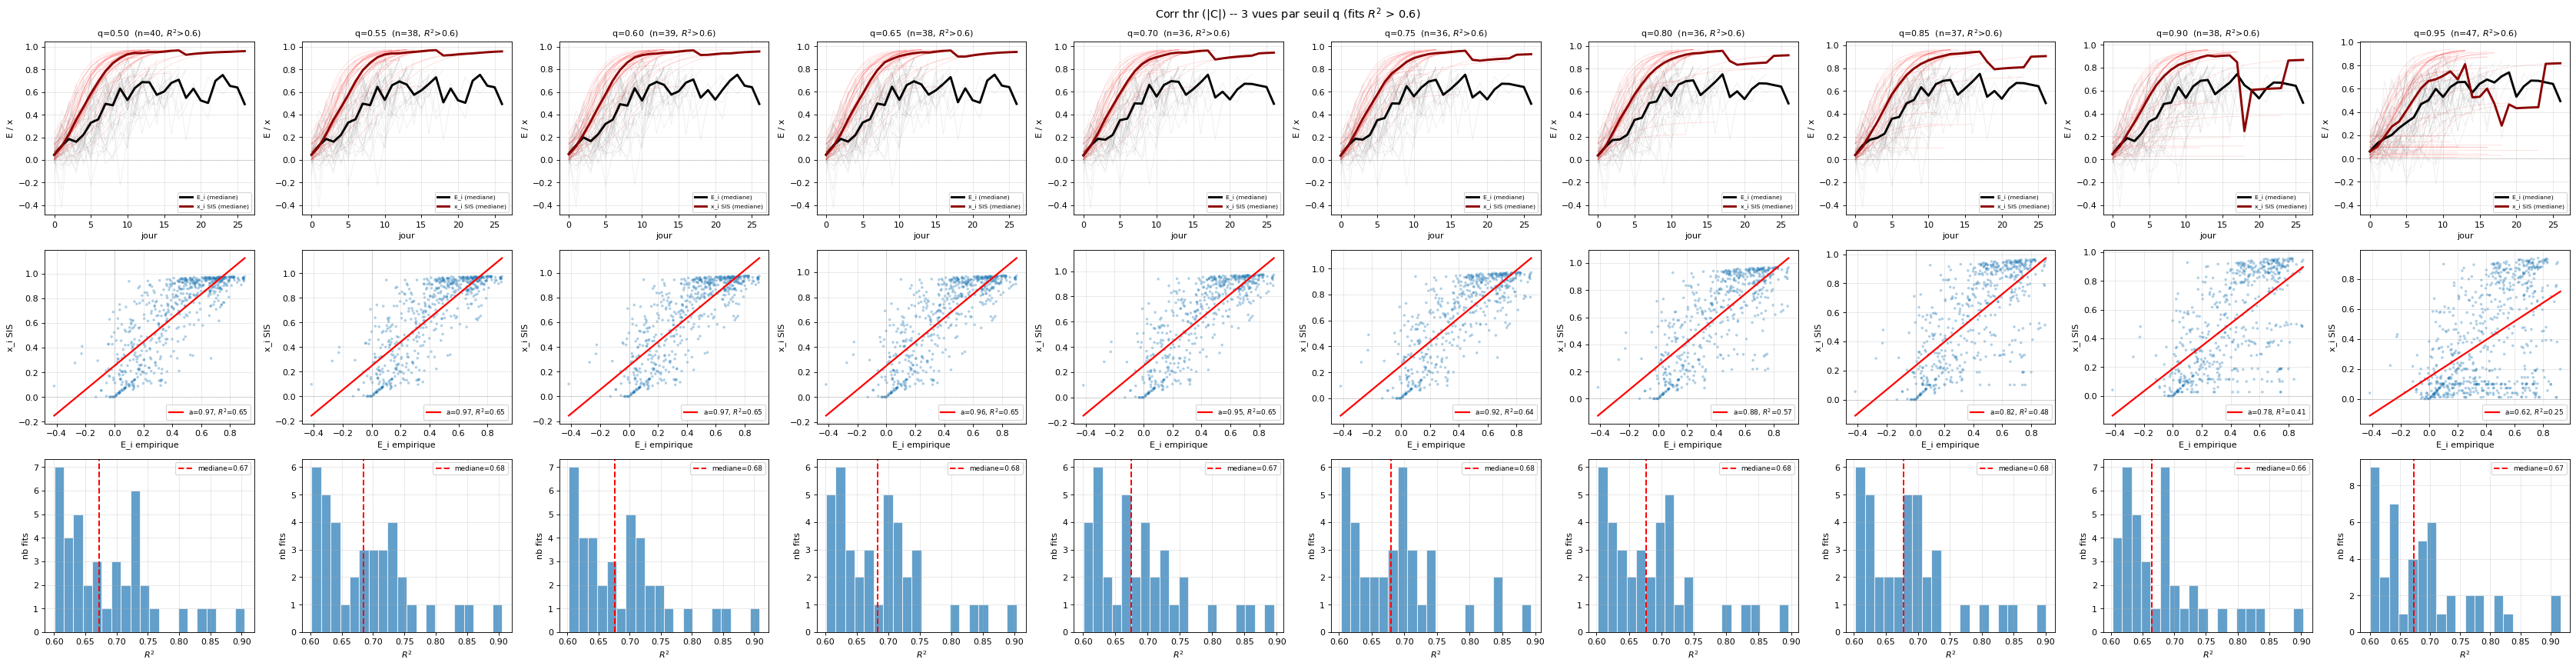

In [ ]:
# ── Les 3 vues (evolution | scatter | distribution R2) -- une colonne par q ──
# Meme structure que le 'Resultat 2' (cell plus haut), mais l'axe des colonnes est
# le seuil q de 'Corr thr' au lieu de la methode. Fits filtres sur R2 > R2_SEUIL.
# Panneau limite a une grille grossiere (0.05) pour rester lisible ; la grille fine
# (Q_SWEEP) sert au resume (n vs q) et aux medianes superposees.
Q_PANEL = np.round(np.arange(0.50, 0.96, 0.05), 2)
fig, axes = plt.subplots(3, len(Q_PANEL), figsize=(4.2 * len(Q_PANEL), 11), squeeze=False)
for j, q in enumerate(Q_PANEL):
    Es, Xs, E_all, X_all, r2s, keys = sweep[round(float(q), 2)]
    sel = [i for i, r in enumerate(r2s) if r > R2_SEUIL]          # fits R2 > seuil
    Esf = [Es[i] for i in sel];    Xsf = [Xs[i] for i in sel]
    Eaf = [E_all[i] for i in sel]; Xaf = [X_all[i] for i in sel]; r2f = [r2s[i] for i in sel]

    # haut : evolution temporelle E_i (gris) / x_i (rouge) + medianes en fonce
    axt = axes[0, j]
    for E_i, x_traj in zip(Esf, Xsf):
        ok = ~np.isnan(E_i)
        axt.plot(np.arange(len(E_i))[ok], E_i[ok], color='gray', alpha=0.15, lw=0.7)
        axt.plot(np.arange(len(x_traj)), x_traj, color='red', alpha=0.15, lw=0.7)
    med_E, med_X = _med(Esf), _med(Xsf)
    if len(med_E):
        axt.plot(np.arange(len(med_E)), med_E, color='black', lw=2.6, label='E_i (mediane)')
        axt.plot(np.arange(len(med_X)), med_X, color='darkred', lw=2.6, label='x_i SIS (mediane)')
    axt.axhline(0, color='gray', lw=0.6, ls=':')
    axt.set_title(rf'q={q:.2f}  (n={len(sel)}, $R^2$>{R2_SEUIL})', fontsize=10)
    axt.set_xlabel('jour'); axt.set_ylabel('E / x'); axt.grid(alpha=0.3)
    if Esf:
        axt.legend(fontsize=7)

    # milieu : scatter x_i SIS vs E_i + regression agregee
    axs = axes[1, j]
    if Eaf:
        Ec, Xc = np.concatenate(Eaf), np.concatenate(Xaf)
        axs.scatter(Ec, Xc, s=10, color='#1f77b4', alpha=0.35, edgecolors='none')
        f = linregress(Ec, Xc); xs = np.linspace(Ec.min(), Ec.max(), 50)
        axs.plot(xs, f.slope * xs + f.intercept, color='red', lw=2,
                 label=rf'a={f.slope:.2f}, $R^2$={f.rvalue**2:.2f}')
        axs.legend(fontsize=8)
    axs.axhline(0, color='gray', lw=0.6, ls=':'); axs.axvline(0, color='gray', lw=0.6, ls=':')
    axs.set_xlabel('E_i empirique'); axs.set_ylabel('x_i SIS'); axs.grid(alpha=0.3)

    # bas : distribution des R2 (mediane en pointilles rouges)
    axd = axes[2, j]
    if r2f:
        axd.hist(r2f, bins=20, color='#1f77b4', alpha=0.7, edgecolor='white')
        mr = np.median(r2f)
        axd.axvline(mr, color='red', ls='--', lw=1.8, label=f'mediane={mr:.2f}')
        axd.legend(fontsize=8)
    axd.set_xlabel(r'$R^2$'); axd.set_ylabel('nb fits'); axd.grid(alpha=0.3)

plt.suptitle(rf"Corr thr (|C|) -- 3 vues par seuil q (fits $R^2$ > {R2_SEUIL})", fontsize=13)
plt.tight_layout(); plt.show()

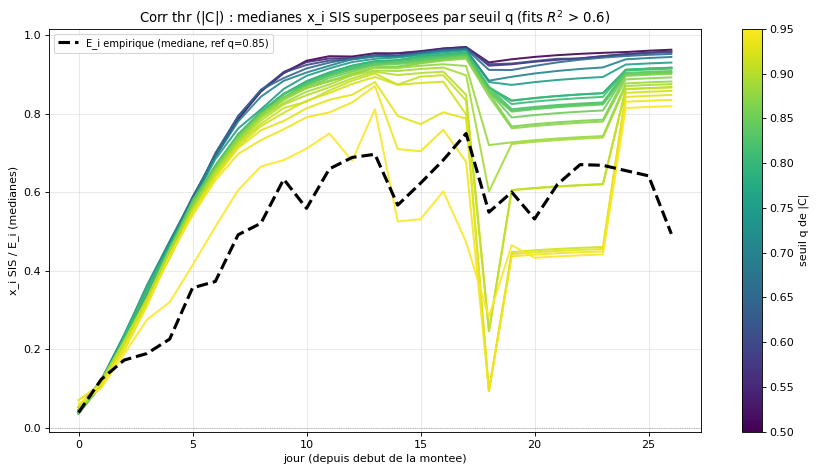

In [ ]:
# ── Superposition des courbes medianes x_i SIS pour les differents seuils q ──
# Sur un seul axe : la trajectoire MEDIANE x_i (fits R2 > R2_SEUIL) de chaque seuil q,
# coloree par q (colorbar), comparee a la mediane empirique E_i (reference, ~q-indep).
cmap = plt.cm.viridis; norm = plt.Normalize(Q_SWEEP.min(), Q_SWEEP.max())
fig, ax = plt.subplots(figsize=(11, 6))
medE_ref = None
for q in Q_SWEEP:
    Es, Xs, E_all, X_all, r2s, keys = sweep[round(float(q), 2)]
    sel = [i for i, r in enumerate(r2s) if r > R2_SEUIL]
    if not sel:
        continue
    med_X = _med([Xs[i] for i in sel])
    ax.plot(np.arange(len(med_X)), med_X, color=cmap(norm(q)), lw=1.8, alpha=0.9)
    if abs(q - CORR_THRESHOLD) < 1e-9:                  # E_i de reference : seuil 'Corr thr'
        medE_ref = _med([Es[i] for i in sel])
if medE_ref is None and sel:                            # repli : dernier seuil disponible
    medE_ref = _med([Es[i] for i in sel])
ax.plot(np.arange(len(medE_ref)), medE_ref, color='black', lw=2.8, ls='--',
        label=f'E_i empirique (mediane, ref q={CORR_THRESHOLD})')
ax.axhline(0, color='gray', lw=0.6, ls=':')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
fig.colorbar(sm, ax=ax).set_label('seuil q de |C|')
ax.set_xlabel('jour (depuis debut de la montee)'); ax.set_ylabel('x_i SIS / E_i (medianes)')
ax.set_title(rf"Corr thr (|C|) : medianes x_i SIS superposees par seuil q (fits $R^2$ > {R2_SEUIL})")
ax.legend(fontsize=9, loc='best'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Détection des crises par les **pics** de la corrélation moyenne

Approche complémentaire de l'**étape 1** (fenêtres *croissantes*). Ici on délimite
chaque crise autour des **sommets** de la corrélation moyenne journalière `<|C_ij|>`
lissée : on détecte les pics (`scipy.signal.find_peaks`) au-dessus de la moyenne
globale et assez proéminents, puis on borne chaque crise par la **largeur du pic**
(à une fraction de sa proéminence). Chaque période détectée = (début, sommet, fin).
Les fenêtres croissantes de l'étape 1 sont rappelées en orange pour comparaison.

22 pic(s) detecte(s) (crises) :
  2019-05-01 -> [pic 2019-05-15, |C|=0.542] -> 2019-06-14   (32 j)
  2019-07-29 -> [pic 2019-08-14, |C|=0.568] -> 2019-09-06   (29 j)
  2019-09-27 -> [pic 2019-10-03, |C|=0.492] -> 2019-10-18   (16 j)
  2020-01-24 -> [pic 2020-02-04, |C|=0.492] -> 2020-02-06   (10 j)
  2020-02-20 -> [pic 2020-03-06, |C|=0.751] -> 2020-03-26   (26 j)
  2020-03-26 -> [pic 2020-04-06, |C|=0.560] -> 2020-04-17   (16 j)
  2020-06-03 -> [pic 2020-06-16, |C|=0.587] -> 2020-06-26   (18 j)
  2020-09-01 -> [pic 2020-09-14, |C|=0.511] -> 2020-10-02   (23 j)
  2020-10-21 -> [pic 2020-11-04, |C|=0.536] -> 2020-11-19   (22 j)
  2021-02-18 -> [pic 2021-03-04, |C|=0.471] -> 2021-03-16   (19 j)
  2021-04-30 -> [pic 2021-05-13, |C|=0.477] -> 2021-05-27   (20 j)
  2021-09-13 -> [pic 2021-09-29, |C|=0.540] -> 2021-10-18   (26 j)
  2021-11-22 -> [pic 2021-11-29, |C|=0.488] -> 2021-12-16   (18 j)
  2022-01-13 -> [pic 2022-01-20, |C|=0.546] -> 2022-02-07   (17 j)
  2022-02-14 -> [pic 2022-03-0

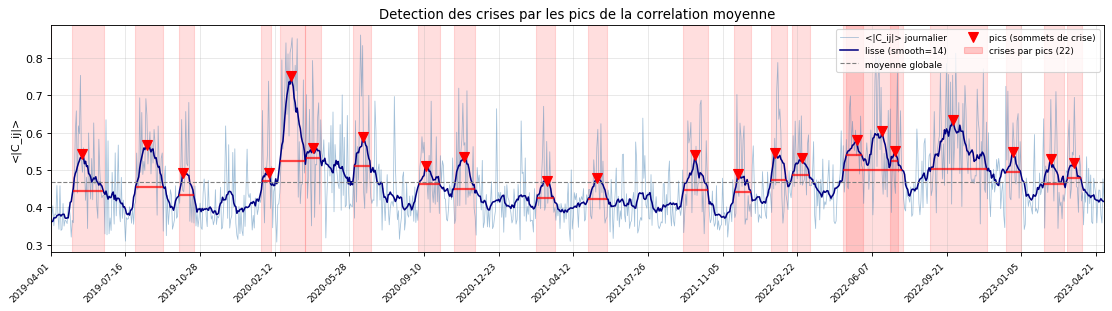

In [ ]:
# ── Détection des crises par les PICS de la corrélation moyenne <|C_ij|> ─────────
# Repère les sommets de <|C_ij|> journalier lissé, puis délimite chaque crise par la
# largeur du pic (a `PK_RELHEIGHT` de sa proéminence). Période = (début, sommet, fin).
from scipy.signal import find_peaks, peak_widths

# Paramètres de détection des pics (réglables) ----------------------------------
PK_SMOOTH    = SMOOTH                     # lissage (réutilise celui de l'étape 1)
PK_HEIGHT    = mean_mc                    # un pic doit dépasser <|C|> moyen global
PK_PROM      = 0.30 * np.nanstd(mc_all)   # proéminence minimale (relief du pic)
PK_DISTANCE  = MIN_LEN                    # écart minimal (jours) entre deux pics
PK_RELHEIGHT = 0.6                        # fraction de la proéminence -> largeur

mc_s = uniform_filter1d(np.nan_to_num(mc_all, nan=mean_mc), size=PK_SMOOTH, mode='nearest')
peaks, _ = find_peaks(mc_s, height=PK_HEIGHT, prominence=PK_PROM, distance=PK_DISTANCE)
_w, w_h, l_ips, r_ips = peak_widths(mc_s, peaks, rel_height=PK_RELHEIGHT)

peak_intervals = sorted(
    [(int(np.floor(l)), int(np.ceil(r)), int(p)) for l, r, p in zip(l_ips, r_ips, peaks)],
    key=lambda t: t[0])

print(f'{len(peak_intervals)} pic(s) detecte(s) (crises) :')
for a, b, pk in peak_intervals:
    print(f'  {all_days[a]} -> [pic {all_days[pk]}, |C|={mc_s[pk]:.3f}] -> {all_days[b]}'
          f'   ({b - a + 1} j)')

# ── Tracé : série + pics + fenêtres de crise (largeur des pics) vs étape 1 ───────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(mc_all, color='steelblue', lw=0.7, alpha=0.5, label='<|C_ij|> journalier')
ax.plot(mc_s,   color='navy',      lw=1.4, label=f'lisse (smooth={PK_SMOOTH})')
ax.axhline(mean_mc, color='gray', ls='--', lw=1, label='moyenne globale')
# fenêtres croissantes (étape 1), en orange, pour comparaison
#for (a, b) in intervals_chrono:
 #   ax.axvspan(a, b, color='orange', alpha=0.10)
# crises par pics, en rouge + largeur du pic + sommet
for a, b, pk in peak_intervals:
    ax.axvspan(a, b, color='red', alpha=0.13)
ax.hlines(w_h, l_ips, r_ips, color='red', lw=2, alpha=0.7)
ax.plot(peaks, mc_s[peaks], 'v', color='red', ms=9, label='pics (sommets de crise)')
ax.axvspan(0, 0, color='red',    alpha=0.20, label=f'crises par pics ({len(peak_intervals)})')
#ax.axvspan(0, 0, color='orange', alpha=0.15, label=f'etape 1 croissante ({len(intervals_chrono)})')
step = max(1, len(all_days) // 14)
ax.set_xticks(range(0, len(all_days), step))
ax.set_xticklabels([str(all_days[k]) for k in range(0, len(all_days), step)],
                   rotation=45, ha='right', fontsize=8)
ax.set_xlim(0, len(all_days) - 1)
ax.set_ylabel('<|C_ij|>'); ax.grid(alpha=0.3)
ax.set_title('Detection des crises par les pics de la correlation moyenne')
ax.legend(fontsize=8, loc='upper right', ncol=2)
plt.tight_layout(); plt.show()


## Montées des pics → quelles courbes ont R² > 0.6 ?

On prend la **montée** de chaque pic détecté ci-dessus (du **creux précédent**
jusqu'au **sommet**) comme fenêtre de crise globale, puis on ajuste le SIS par
actif avec les mêmes fonctions que le pipeline principal (`fits_for` →
`strong_rise` + `crisis_map` + intégration), et on garde les **courbes**
(actif × montée) dont la meilleure méthode atteint `R² > R2_SEUIL` (= 0.6).
Calcul mis en cache (`peak_period_data`).

17 montee(s) de pic (creux -> sommet) :
  2019-04-01 -> 2019-05-15   (32 j, gain |C| +0.183)
  2019-07-22 -> 2019-08-14   (18 j, gain |C| +0.188)
  2019-11-19 -> 2020-02-04   (52 j, gain |C| +0.111)
  2020-02-11 -> 2020-03-06   (18 j, gain |C| +0.293)
  2020-05-29 -> 2020-06-16   (13 j, gain |C| +0.128)
  2020-08-24 -> 2020-09-14   (15 j, gain |C| +0.118)
  2020-10-19 -> 2020-11-04   (13 j, gain |C| +0.108)
  2020-12-10 -> 2021-03-04   (57 j, gain |C| +0.078)
  2021-03-29 -> 2021-05-13   (33 j, gain |C| +0.091)
  2021-08-05 -> 2021-09-29   (39 j, gain |C| +0.153)
  2021-11-09 -> 2021-11-29   (14 j, gain |C| +0.117)
  2022-01-03 -> 2022-01-20   (13 j, gain |C| +0.135)
  2022-02-08 -> 2022-03-01   (15 j, gain |C| +0.078)
  2022-04-08 -> 2022-06-22   (51 j, gain |C| +0.179)
  2022-08-01 -> 2022-09-29   (43 j, gain |C| +0.204)
  2022-12-02 -> 2022-12-22   (15 j, gain |C| +0.090)
  2023-01-20 -> 2023-02-16   (20 j, gain |C| +0.109)
[cache] OK  peak_period_data

775 courbes (actif x montee) 

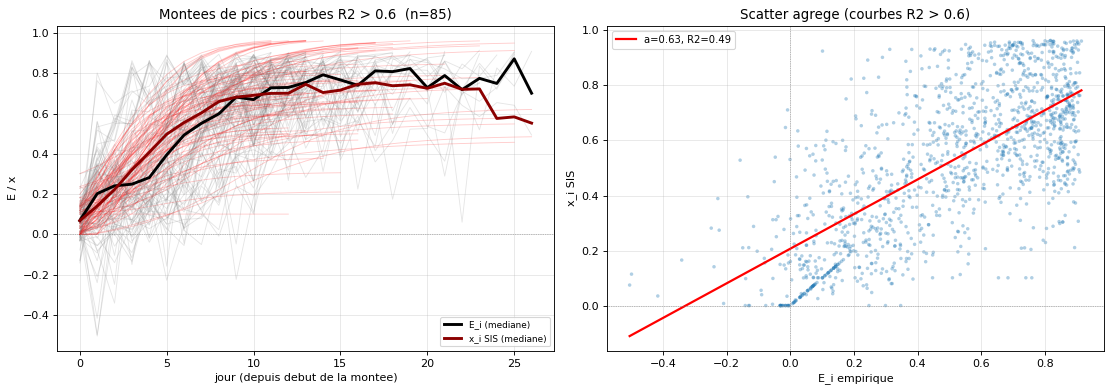

In [ ]:
# ── Montées des pics -> SIS par actif -> courbes avec R2 > R2_SEUIL ──────────────
# Fenêtre de crise = la MONTEE de chaque pic : du creux precedent jusqu'au sommet.
# On reutilise le pipeline principal (fits_for) ; seules les fenetres globales changent.
peak_rises, _prev = [], 0
for a, b, pk in peak_intervals:                 # peak_intervals : (gauche, droite, sommet)
    trough = _prev + int(np.argmin(mc_s[_prev:pk + 1])) if pk > _prev else pk
    if pk - trough + 1 >= MIN_LEN:
        peak_rises.append((trough, pk))
    _prev = pk
peak_rises = sorted(set(peak_rises))
print(f'{len(peak_rises)} montee(s) de pic (creux -> sommet) :')
for (a, b) in peak_rises:
    print(f'  {all_days[a]} -> {all_days[b]}   ({b - a + 1} j, gain |C| '
          f'{mc_s[b] - mc_s[a]:+.3f})')

# ── Fit SIS sur chaque montee (cache) : reutilise fits_for du pipeline principal ─
_sig_pk = sig_of(peak_rises, crisis_map, CORR_THRESHOLD, T_long, B_fit, R_fit, tol_eq,
                 SR_SMOOTH, SR_MIN_LEN, SR_MIN_GAIN)
peak_pd = disk_cache('peak_period_data', _sig_pk,
                     lambda: {(a, b): fits_for(a, b) for (a, b) in peak_rises})

# ── Recap : 1 ligne par (actif, montee) ; meilleure methode + R2 par methode ─────
records, Es, Xs, E_all, X_all, r2s = [], [], [], [], [], []
for (pa, pb) in peak_rises:
    cache, fits = peak_pd[(pa, pb)]
    for gi in cache:
        best_m, best_r2 = None, -1.0
        for m in SIS_MODELS:
            sl = fits[m][1].get(gi)
            if sl is not None and sl['r2'] > best_r2:
                best_m, best_r2 = m, sl['r2']
        if best_m is None:
            continue
        rec = {'actif': asset_names[gi], 'montee': f'{all_days[pa]}->{all_days[pb]}',
               'sommet': str(all_days[pb]), 'meilleure_methode': best_m}
        for m in SIS_MODELS:
            sl = fits[m][1].get(gi)
            rec[f'R2_{m}'] = round(sl['r2'], 3) if sl is not None else np.nan
        rec['R2_max'] = round(best_r2, 3)
        records.append(rec)
        if best_r2 > R2_SEUIL:                  # courbe retenue
            E_i, x_traj = fits[best_m][0][gi]; ok = ~np.isnan(E_i)
            Es.append(E_i); Xs.append(x_traj)
            E_all.append(E_i[ok]); X_all.append(x_traj[ok]); r2s.append(best_r2)

R2_COLS = [f'R2_{m}' for m in SIS_MODELS]
pk_df = pd.DataFrame(records).sort_values('R2_max', ascending=False)
pk_df.to_csv('results/actifs_montees_pics_R2.csv', index=False)
good = pk_df[pk_df['R2_max'] > R2_SEUIL]
print(f'\n{len(pk_df)} courbes (actif x montee) ; {len(good)} avec R2 > {R2_SEUIL} '
      f'({good.actif.nunique()} actifs distincts) -> results/actifs_montees_pics_R2.csv')

# ── Tracé des courbes retenues : evolution E_i/x_i (gauche) + scatter agrege (droite) ─
fig, (axt, axs) = plt.subplots(1, 2, figsize=(14, 5))
for E_i, x_traj in zip(Es, Xs):
    ok = ~np.isnan(E_i)
    axt.plot(np.arange(len(E_i))[ok], E_i[ok], color='gray', alpha=0.20, lw=0.8)
    axt.plot(np.arange(len(x_traj)),  x_traj,  color='red',  alpha=0.20, lw=0.8)
med_E, med_X = _med(Es), _med(Xs)
if len(med_E):
    axt.plot(np.arange(len(med_E)), med_E, color='black',   lw=2.6, label='E_i (mediane)')
    axt.plot(np.arange(len(med_X)), med_X, color='darkred', lw=2.6, label='x_i SIS (mediane)')
axt.axhline(0, color='gray', lw=0.6, ls=':')
axt.set_title(f'Montees de pics : courbes R2 > {R2_SEUIL}  (n={len(Es)})')
axt.set_xlabel('jour (depuis debut de la montee)'); axt.set_ylabel('E / x')
axt.grid(alpha=0.3)
if Es:
    axt.legend(fontsize=8)

if E_all:
    Ec, Xc = np.concatenate(E_all), np.concatenate(X_all)
    axs.scatter(Ec, Xc, s=10, color='#1f77b4', alpha=0.35, edgecolors='none')
    f = linregress(Ec, Xc); xs = np.linspace(Ec.min(), Ec.max(), 50)
    axs.plot(xs, f.slope * xs + f.intercept, color='red', lw=2,
             label=f'a={f.slope:.2f}, R2={f.rvalue ** 2:.2f}')
    axs.legend(fontsize=9)
axs.axhline(0, color='gray', lw=0.6, ls=':'); axs.axvline(0, color='gray', lw=0.6, ls=':')
axs.set_xlabel('E_i empirique'); axs.set_ylabel('x_i SIS')
axs.set_title(f'Scatter agrege (courbes R2 > {R2_SEUIL})'); axs.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Montées des pics → les 3 vues **par méthode** (4 colonnes)

Même découpage que la cellule ci-dessus (montées creux→sommet, `peak_pd` / `peak_rises`),
mais — comme le « Résultat 2 » — on trace **chaque méthode séparément** au lieu de la
meilleure par actif. Chaque colonne = une matrice SIS ; titre `n` = nb de courbes
R² > R2_SEUIL de cette méthode (un actif peut compter dans plusieurs colonnes).

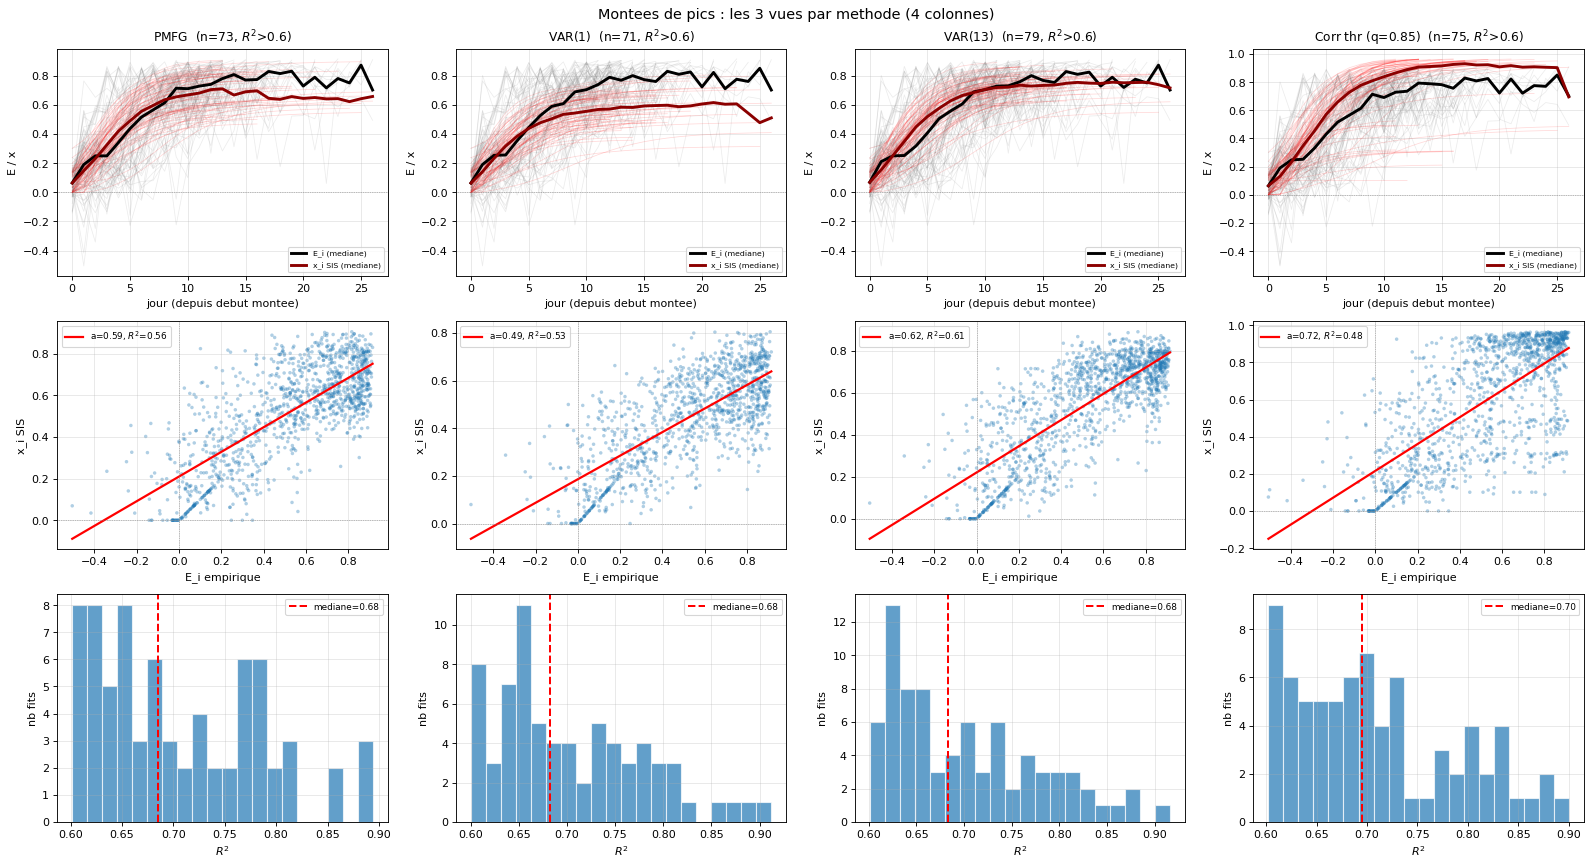

In [ ]:
# ── Montees de pics : les 3 vues PAR METHODE (4 colonnes), facon Resultat 2 ──────
# Meme structure que 'Resultat 2' mais sur peak_pd / peak_rises (montees de pics) :
# ici chaque methode est tracee separement (au lieu de la meilleure par actif).
fig, axes = plt.subplots(3, len(SIS_MODELS), figsize=(5 * len(SIS_MODELS), 11))
for j, m in enumerate(SIS_MODELS):
    Es, Xs, E_all, X_all, r2s = [], [], [], [], []
    for (pa, pb) in peak_rises:
        fits = peak_pd[(pa, pb)][1]
        for gi, sl in fits[m][1].items():
            if sl['r2'] > R2_SEUIL:
                E_i, x_traj = fits[m][0][gi]; ok = ~np.isnan(E_i)
                Es.append(E_i); Xs.append(x_traj)
                E_all.append(E_i[ok]); X_all.append(x_traj[ok]); r2s.append(sl['r2'])

    # haut : evolution temporelle E_i (gris) / x_i (rouge) + medianes
    axt = axes[0, j]
    for E_i, x_traj in zip(Es, Xs):
        ok = ~np.isnan(E_i)
        axt.plot(np.arange(len(E_i))[ok], E_i[ok], color='gray', alpha=0.15, lw=0.7)
        axt.plot(np.arange(len(x_traj)), x_traj, color='red', alpha=0.15, lw=0.7)
    med_E, med_X = _med(Es), _med(Xs)
    if len(med_E):
        axt.plot(np.arange(len(med_E)), med_E, color='black', lw=2.6, label='E_i (mediane)')
        axt.plot(np.arange(len(med_X)), med_X, color='darkred', lw=2.6, label='x_i SIS (mediane)')
    axt.axhline(0, color='gray', lw=0.6, ls=':')
    m_lbl = f'{m} (q={CORR_THRESHOLD})' if m == 'Corr thr' else m
    axt.set_title(rf'{m_lbl}  (n={len(Es)}, $R^2$>{R2_SEUIL})', fontsize=11)
    axt.set_xlabel('jour (depuis debut montee)'); axt.set_ylabel('E / x'); axt.grid(alpha=0.3)
    if Es:
        axt.legend(fontsize=7)

    # milieu : scatter x_i SIS vs E_i + regression agregee
    axs = axes[1, j]
    if E_all:
        Ec, Xc = np.concatenate(E_all), np.concatenate(X_all)
        axs.scatter(Ec, Xc, s=10, color='#1f77b4', alpha=0.35, edgecolors='none')
        f = linregress(Ec, Xc); xs = np.linspace(Ec.min(), Ec.max(), 50)
        axs.plot(xs, f.slope * xs + f.intercept, color='red', lw=2,
                 label=rf'a={f.slope:.2f}, $R^2$={f.rvalue ** 2:.2f}')
        axs.legend(fontsize=8)
    axs.axhline(0, color='gray', lw=0.6, ls=':'); axs.axvline(0, color='gray', lw=0.6, ls=':')
    axs.set_xlabel('E_i empirique'); axs.set_ylabel('x_i SIS'); axs.grid(alpha=0.3)

    # bas : distribution des R2
    axd = axes[2, j]
    if r2s:
        axd.hist(r2s, bins=20, color='#1f77b4', alpha=0.7, edgecolor='white')
        med_r2 = np.median(r2s)
        axd.axvline(med_r2, color='red', ls='--', lw=1.8, label=f'mediane={med_r2:.2f}')
        axd.legend(fontsize=8)
    axd.set_xlabel(r'$R^2$'); axd.set_ylabel('nb fits'); axd.grid(alpha=0.3)

plt.suptitle('Montees de pics : les 3 vues par methode (4 colonnes)', fontsize=13)
plt.tight_layout(); plt.show()


## Comparaison des **périodes retenues** : avec/sans pics + λ_max/⟨λ⟩

On ne garde que les **périodes retenues** de chaque méthode = fenêtres globales (boucle 1)
portant **≥ 1 fit R² > R2_SEUIL** (même critère que `selected` : 9 sans pics, 7 avec pics).
Pour chacune on affiche **les deux boucles** :

- **boucle 1** — la fenêtre retenue (span coloré) : montée creux→sommet (`peak_rises`, *avec pics*)
  vs fenêtre croissante de ⟨|C_ij|⟩ (`intervals_chrono`, *sans pics*).
- **boucle 2** — actifs en crise **par fenêtre** (chiffre **bleu** = `len(cache)` de `fits_for`),
  dont **(rouge)** = nb de fits R² > R2_SEUIL.

Troisième panneau : **λ_max/⟨λ⟩** (méthode `article.ipynb`), pics ▼ verts reportés en haut.
Bascule `RETENUE_ONLY = False` pour revoir toutes les fenêtres détectées (24 / 17).

[cache] OK  spectral_diag
17 pic(s) de λ_max/⟨λ⟩
11 periode(s) "mix" (λ_max/⟨λ⟩ + max|ρ|/⟨|ρ|⟩) :
  2019-07-16 -> 2019-08-07
  2019-11-04 -> 2019-12-11
  2020-02-28 -> 2020-04-15
  2020-06-17 -> 2020-07-13
  2020-08-17 -> 2020-09-11
  2020-11-27 -> 2021-02-01
  2021-04-19 -> 2021-05-19
  2021-08-04 -> 2021-09-24
  2021-11-03 -> 2021-12-02
  2022-06-14 -> 2022-07-20
  2022-09-20 -> 2022-10-28


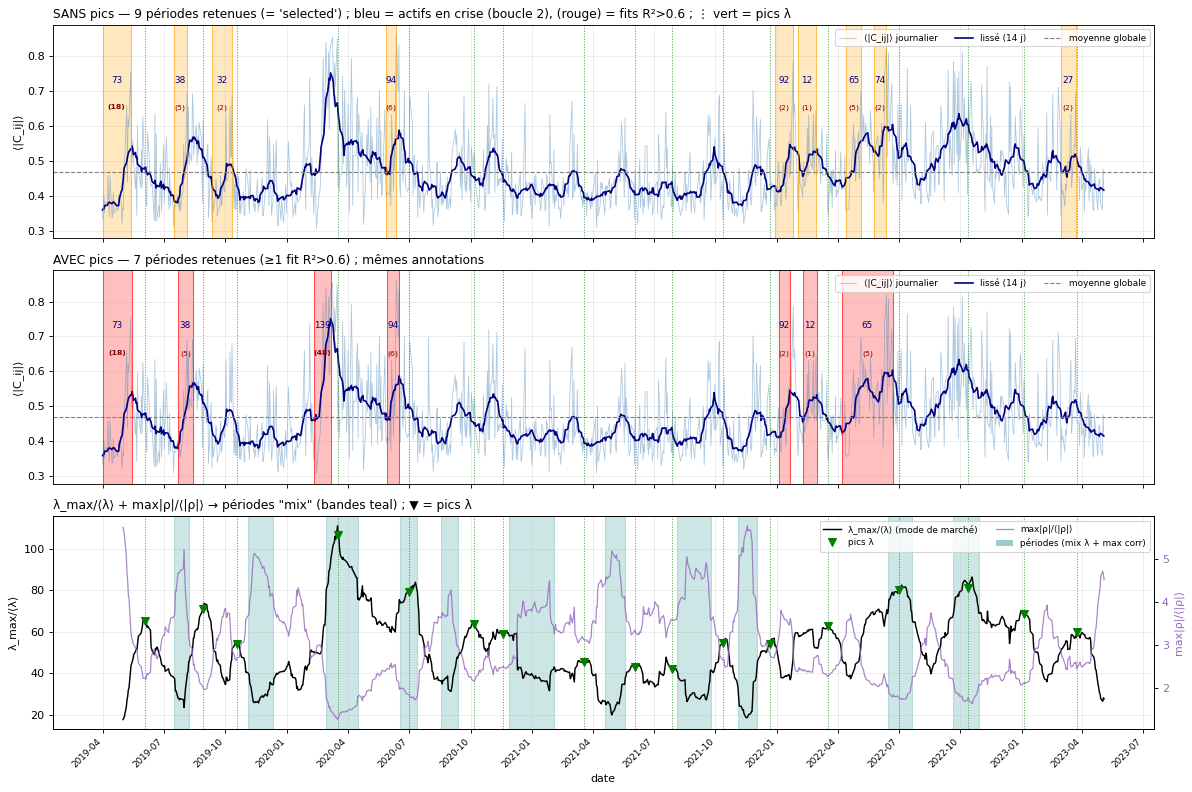

SANS pics :  9 periodes retenues ; boucle2 145 actifs en crise (distincts) ;  43 fits R2>0.6
AVEC pics :  7 periodes retenues ; boucle2 145 actifs en crise (distincts) ;  85 fits R2>0.6
  -- SANS pics :
     2019-04-01 -> 2019-05-13  boucle2= 73 en crise,  18 fits R2>0.6
     2019-07-16 -> 2019-08-05  boucle2= 38 en crise,   5 fits R2>0.6
     2019-09-11 -> 2019-10-11  boucle2= 32 en crise,   2 fits R2>0.6
     2020-05-28 -> 2020-06-12  boucle2= 94 en crise,   6 fits R2>0.6
     2021-12-28 -> 2022-01-25  boucle2= 92 en crise,   2 fits R2>0.6
     2022-02-01 -> 2022-02-28  boucle2= 12 en crise,   1 fits R2>0.6
     2022-04-14 -> 2022-05-06  boucle2= 65 en crise,   5 fits R2>0.6
     2022-05-25 -> 2022-06-13  boucle2= 74 en crise,   2 fits R2>0.6
     2023-02-28 -> 2023-03-22  boucle2= 27 en crise,   2 fits R2>0.6
  -- AVEC pics :
     2019-04-01 -> 2019-05-15  boucle2= 73 en crise,  18 fits R2>0.6
     2019-07-22 -> 2019-08-14  boucle2= 38 en crise,   5 fits R2>0.6
     2020-02-11 -> 20

In [ ]:
# ── Comparaison des PERIODES RETENUES (avec/sans pics) + les 2 boucles vs λ_max/⟨λ⟩ ─
# RETENUE_ONLY=True -> on ne garde que les fenetres avec >= 1 fit R² > R2_SEUIL
# (= 'selected' : 9 sans pics, 7 avec pics). Pour chaque fenetre on montre les 2 boucles :
#   boucle 1 = la fenetre retenue (span) ; boucle 2 = actifs en crise (chiffre bleu),
#   dont (rouge) = fits R² > R2_SEUIL. 3e panneau = λ_max/⟨λ⟩ facon article.ipynb.
import matplotlib.dates as mdates
from scipy.signal import find_peaks as _find_peaks, peak_widths

RETENUE_ONLY = True
WINDOW_SPEC, STEP_SPEC = 13 * 21, 13          # ~1 mois de barres 30-min, 1 point / jour

def _compute_spectral():
    a = data.values; Tn, Nn = a.shape; iu = np.triu_indices(Nn, k=1)
    rows, idx = [], []
    for end in range(WINDOW_SPEC, Tn + 1, STEP_SPEC):
        sub = a[end - WINDOW_SPEC:end]
        C = np.corrcoef(sub.T); off = np.abs(C[iu]); ev = np.linalg.eigvalsh(C)
        rows.append((off.max() / off.mean(), ev.max() / ev.mean(), sub.mean(), off.max(), off.mean()))
        idx.append(data.index[end - 1])
    return pd.DataFrame(rows, index=pd.DatetimeIndex(idx),
                        columns=['ratio_corr', 'ratio_eig', 'mean_return', 'max_corr', 'mean_corr'])

diag = disk_cache('spectral_diag', f'N{N}T{len(data)}_w{WINDOW_SPEC}s{STEP_SPEC}_v2', _compute_spectral)
_re = uniform_filter1d(diag['ratio_eig'].values, size=15, mode='nearest')
_pk, _ = _find_peaks(_re, prominence=0.3 * diag['ratio_eig'].std(), distance=20)
lam_dates = diag.index[_pk]
print(f'{len(lam_dates)} pic(s) de λ_max/⟨λ⟩')

# ── Periodes "mix" : λ_max/⟨λ⟩ + max de correlation (z-scores additionnes) ───────
# Score = z(λ_max/⟨λ⟩) + z(max|ρ_ij|) ; on en prend les pics et la largeur (rel_height
# 0.5) -> chaque periode = [bord gauche, bord droit] de la bosse du score combine.
_z = lambda s: (np.asarray(s, float) - np.nanmean(s)) / np.nanstd(s)
mix = uniform_filter1d(_z(diag['ratio_eig']) + _z(diag['ratio_corr']), size=15, mode='nearest')
_mpk, _ = _find_peaks(mix, prominence=0.8 * np.nanstd(mix), distance=20)
_lw, _wh, _li, _ri = peak_widths(mix, _mpk, rel_height=0.5)
mix_periods = sorted({(diag.index[int(np.floor(l))],
                       diag.index[min(int(np.ceil(r)), len(diag) - 1)]) for l, r in zip(_li, _ri)})
print(f'{len(mix_periods)} periode(s) "mix" (λ_max/⟨λ⟩ + max|ρ|/⟨|ρ|⟩) :')
for a, b in mix_periods:
    print(f'  {a.date()} -> {b.date()}')

# ── Les deux boucles par methode, puis filtre 'retenues' (>= 1 fit R² > R2_SEUIL) ──
def _r2max(fits, gi):
    return max((fits[m][1][gi]['r2'] for m in SIS_MODELS if gi in fits[m][1]), default=0.0)

def _wins(windows, pdict):
    out = []
    for (pa, pb) in windows:
        cache, fits = pdict[(pa, pb)]
        n_sup = sum(_r2max(fits, gi) > R2_SEUIL for gi in cache)
        out.append(dict(a=pd.Timestamp(all_days[pa]), b=pd.Timestamp(all_days[pb]),
                        cache=set(cache), n_crise=len(cache), n_sup=int(n_sup)))
    return sorted(out, key=lambda d: d['a'])

def _retain(W):
    return [w for w in W if w['n_sup'] > 0] if RETENUE_ONLY else W

def _tot(W):
    crise = set().union(*[w['cache'] for w in W]) if W else set()
    return len(crise), sum(w['n_sup'] for w in W)

W_pics  = _retain(_wins(peak_rises, peak_pd))
W_crise = _retain(_wins(intervals_chrono, period_data))
nc_p, ns_p = _tot(W_pics); nc_c, ns_c = _tot(W_crise)

mc_dates = pd.to_datetime(all_days); _ymax = np.nanmax(mc_s)
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

def _panel(ax, W, color, title):
    ax.plot(mc_dates, mc_all, color='steelblue', lw=0.7, alpha=0.45, label='⟨|C_ij|⟩ journalier')
    ax.plot(mc_dates, mc_s,   color='navy',      lw=1.5, label=f'lissé ({SMOOTH} j)')
    ax.axhline(mean_mc, color='gray', ls='--', lw=1, label='moyenne globale')
    for w in W:                                                # boucle 1 = span retenu
        ax.axvspan(w['a'], w['b'], color=color, alpha=0.25)
        ax.axvline(w['a'], color=color, lw=0.8, alpha=0.6); ax.axvline(w['b'], color=color, lw=0.8, alpha=0.6)
        mid = w['a'] + (w['b'] - w['a']) / 2
        ax.text(mid, _ymax * 0.99, str(w['n_crise']), ha='center', va='top',   # boucle 2
                fontsize=8, color='navy')
        ax.text(mid, _ymax * 0.88, f"({w['n_sup']})", ha='center', va='top', fontsize=7,
                color='darkred', fontweight='bold' if w['n_sup'] >= 10 else 'normal')
    for d in lam_dates:
        ax.axvline(d, color='green', lw=0.9, ls=':', alpha=0.7)
    ax.set_ylabel('⟨|C_ij|⟩'); ax.grid(alpha=0.25); ax.set_title(title, fontsize=11, loc='left')
    ax.legend(fontsize=8, loc='upper right', ncol=4)

_panel(axes[0], W_crise, 'orange',
       f"SANS pics — {len(W_crise)} périodes retenues (= 'selected') ; "
       f"bleu = actifs en crise (boucle 2), (rouge) = fits R²>{R2_SEUIL} ; ⋮ vert = pics λ")
_panel(axes[1], W_pics, 'red',
       f"AVEC pics — {len(W_pics)} périodes retenues (≥1 fit R²>{R2_SEUIL}) ; mêmes annotations")

ax = axes[2]
for (a, b) in mix_periods:                                 # bandes : periodes "mix" (λ + max corr)
    ax.axvspan(a, b, color='teal', alpha=0.20)
ax.plot(diag.index, diag['ratio_eig'], color='black', lw=1.3, label='λ_max/⟨λ⟩ (mode de marché)')
for d in lam_dates:
    ax.axvline(d, color='green', lw=0.9, ls=':', alpha=0.7)
ax.plot(lam_dates, diag['ratio_eig'].loc[lam_dates], 'v', color='green', ms=8, label='pics λ')
ax.set_ylabel('λ_max/⟨λ⟩'); ax.grid(alpha=0.25)
axb = ax.twinx()
axb.plot(diag.index, diag['ratio_corr'], color='tab:purple', lw=1.1, alpha=0.8,
         label='max|ρ|/⟨|ρ|⟩')
axb.set_ylabel('max|ρ|/⟨|ρ|⟩', color='tab:purple'); axb.tick_params(axis='y', labelcolor='tab:purple')
ax.set_title('λ_max/⟨λ⟩ + max|ρ|/⟨|ρ|⟩ → périodes "mix" (bandes teal) ; ▼ = pics λ',
             fontsize=11, loc='left')
from matplotlib.patches import Patch as _Patch
_extra = [_Patch(facecolor='teal', alpha=0.4, label='périodes (mix λ + max corr)')]
_h1, _l1 = ax.get_legend_handles_labels(); _h2, _l2 = axb.get_legend_handles_labels()
ax.legend(_h1 + _h2 + _extra, _l1 + _l2 + [p.get_label() for p in _extra],
          fontsize=8, loc='upper right', ncol=2)

axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[-1].get_xticklabels(), rotation=45, ha='right', fontsize=8)
axes[-1].set_xlabel('date')
plt.tight_layout(); plt.show()

# ── Recap chiffre : periodes retenues + les deux boucles ─────────────────────────
print(f'SANS pics : {len(W_crise):2d} periodes retenues ; boucle2 {nc_c:3d} actifs en crise (distincts) ; '
      f'{ns_c:3d} fits R2>{R2_SEUIL}')
print(f'AVEC pics : {len(W_pics):2d} periodes retenues ; boucle2 {nc_p:3d} actifs en crise (distincts) ; '
      f'{ns_p:3d} fits R2>{R2_SEUIL}')
for nom, W in [('SANS pics', W_crise), ('AVEC pics', W_pics)]:
    print(f'  -- {nom} :')
    for w in W:
        print(f"     {w['a'].date()} -> {w['b'].date()}  boucle2={w['n_crise']:3d} en crise, {w['n_sup']:3d} fits R2>{R2_SEUIL}")


## Redondance par méthode — sans pics | avec pics

Tableau récapitulatif de la redondance des actifs (**redondance = fits R²>R2_SEUIL ÷ actifs
distincts**), par méthode, avec les deux sélections **côte à côte** :
- *sans pics* (`period_data`, fenêtres croissantes de |C|),
- *avec pics* (`peak_pd`, montées creux→sommet).

In [ ]:
# ── Recap redondance : PAR METHODE -- sans pics | avec pics ──────────────────────
# redondance = fits(R²>R2_SEUIL) / actifs distincts, par methode, pour chaque selection.
def _rows(pdict):
    rows = []
    for (pa, pb), (cache, fits) in pdict.items():
        for m in SIS_MODELS:
            for gi, sl in fits[m][1].items():
                if sl['r2'] > R2_SEUIL:
                    rows.append((m, asset_names[gi]))
    return pd.DataFrame(rows, columns=['methode', 'actif'])

S, A = _rows(period_data), _rows(peak_pd)        # sans pics, avec pics

def _stat(df, m):
    g = df[df.methode == m]; nu = g.actif.nunique()
    return len(g), nu, (len(g) / nu if nu else 0.0)

def _fmt(f, u, r):
    return f"{f:8d} {u:7d} {r:10.2f}"

print(f"Redondance des actifs (R²>{R2_SEUIL}) :")
print(f"{'':10s} | {'SANS pics':^27s} | {'AVEC pics':^27s}")
print(f"{'methode':10s} | {'fits':>8s} {'actifs':>7s} {'redondance':>10s} | "
      f"{'fits':>8s} {'actifs':>7s} {'redondance':>10s}")
print('-' * 70)
for m in SIS_MODELS:
    print(f"{m:10s} | {_fmt(*_stat(S, m))} | {_fmt(*_stat(A, m))}")


Redondance des actifs (R²>0.6) :
           |          SANS pics          |          AVEC pics         
methode    |     fits  actifs redondance |     fits  actifs redondance
----------------------------------------------------------------------
PMFG       |       34      33       1.03 |       73      64       1.14
VAR(1)     |       33      31       1.06 |       71      61       1.16
VAR(13)    |       38      36       1.06 |       79      68       1.16
Corr thr   |       37      35       1.06 |       75      65       1.15


superposer courbes des lambdas
faire var intermediaires (si pic entre 1 et 13) (demain )

## (essai) Superposition de la courbe λ_max/⟨λ⟩ avec ⟨|C_ij|⟩

On superpose, sur un même axe temporel, la **corrélation moyenne journalière ⟨|C_ij|⟩**
(axe gauche) et **λ_max/⟨λ⟩** (axe droit, fenêtre glissante ~1 mois, calculé plus haut
dans `diag`). Les deux mesurent le mode de marché : ils doivent monter ensemble en crise.

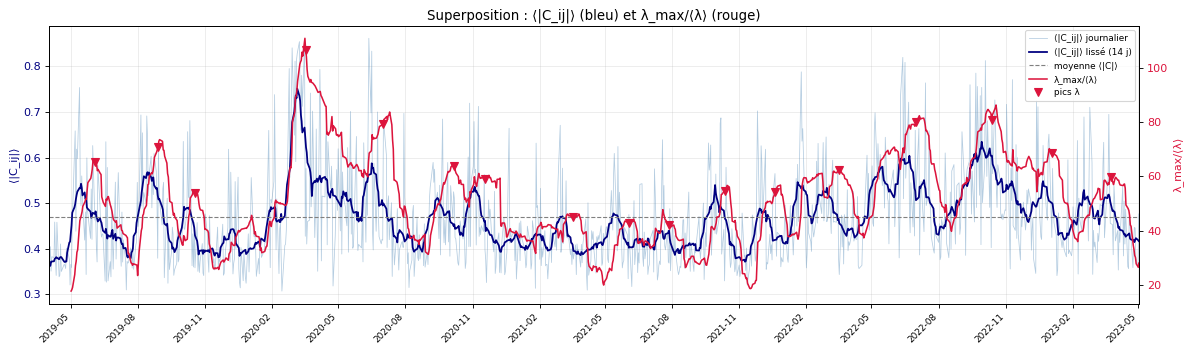

correlation ⟨|C_ij|⟩ lisse vs λ_max/⟨λ⟩ : +0.709


In [ ]:
# ── (essai) Superposition : ⟨|C_ij|⟩ journalier + λ_max/⟨λ⟩ sur le meme axe temps ─
import matplotlib.dates as mdates
mc_dates = pd.to_datetime(all_days)
fig, ax = plt.subplots(figsize=(15, 4.5))
ax.plot(mc_dates, mc_all, color='steelblue', lw=0.7, alpha=0.40, label='⟨|C_ij|⟩ journalier')
ax.plot(mc_dates, mc_s,   color='navy',      lw=1.6, label=f'⟨|C_ij|⟩ lissé ({SMOOTH} j)')
ax.axhline(mean_mc, color='gray', ls='--', lw=1, label='moyenne ⟨|C|⟩')
ax.set_ylabel('⟨|C_ij|⟩', color='navy'); ax.tick_params(axis='y', labelcolor='navy'); ax.grid(alpha=0.25)

axb = ax.twinx()
axb.plot(diag.index, diag['ratio_eig'], color='crimson', lw=1.4, label='λ_max/⟨λ⟩')
axb.plot(lam_dates, diag['ratio_eig'].loc[lam_dates], 'v', color='crimson', ms=7, label='pics λ')
axb.set_ylabel('λ_max/⟨λ⟩', color='crimson'); axb.tick_params(axis='y', labelcolor='crimson')

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_xlim(mc_dates[0], mc_dates[-1])
ax.set_title('Superposition : ⟨|C_ij|⟩ (bleu) et λ_max/⟨λ⟩ (rouge)')
_h1, _l1 = ax.get_legend_handles_labels(); _h2, _l2 = axb.get_legend_handles_labels()
ax.legend(_h1 + _h2, _l1 + _l2, fontsize=8, loc='upper right')
plt.tight_layout(); plt.show()

# correlation des deux signaux (⟨|C|⟩ lisse rallie sur les dates de diag)
_s = pd.Series(mc_s, index=mc_dates).reindex(diag.index, method='nearest')
print(f"correlation ⟨|C_ij|⟩ lisse vs λ_max/⟨λ⟩ : {np.corrcoef(_s, diag['ratio_eig'])[0, 1]:+.3f}")


## (essai) VAR intermédiaires — y a-t-il un pic du fit SIS entre lag 1 et 13 ?

Le pipeline n'utilise que **VAR(1)** et **VAR(13)**. Ici on balaie tous les **lags
intermédiaires** `d = 1..13` : pour chaque `d`, on construit la matrice de contagion
`A_d = prepare_for_sis(|VAR(d)ᵀ|)` (donc `d=1` et `d=13` reproduisent VAR(1)/VAR(13)),
on intègre le SIS sur les périodes retenues (`selected`) et on agrège la qualité du fit
(nb de fits R²>R2_SEUIL, R² moyen, R² agrégé). Si le maximum tombe sur un lag **intérieur**,
c'est qu'un VAR intermédiaire ajuste mieux que les deux extrêmes.

[cache] OK  var_lag_d1
[cache] OK  var_lag_d2
[cache] OK  var_lag_d3
[cache] OK  var_lag_d4
[cache] OK  var_lag_d5
[cache] OK  var_lag_d6
[cache] OK  var_lag_d7
[cache] OK  var_lag_d8
[cache] OK  var_lag_d9
[cache] OK  var_lag_d10
[cache] OK  var_lag_d11
[cache] OK  var_lag_d12
[cache] OK  var_lag_d13
             n  n_sup  R2_moyen  R2_agrege
lag_VAR                                   
1        507.0   32.0     0.243      0.129
2        507.0   30.0     0.245      0.118
3        507.0   35.0     0.244      0.118
4        507.0   33.0     0.244      0.109
5        507.0   31.0     0.245      0.111
6        507.0   33.0     0.243      0.111
7        507.0   31.0     0.245      0.113
8        507.0   28.0     0.244      0.129
9        507.0   31.0     0.243      0.104
10       507.0   31.0     0.243      0.108
11       507.0   34.0     0.244      0.116
12       507.0   35.0     0.246      0.134
13       507.0   35.0     0.247      0.144

max nb fits R²>0.6 au lag 3 ; max R² agrege au lag 

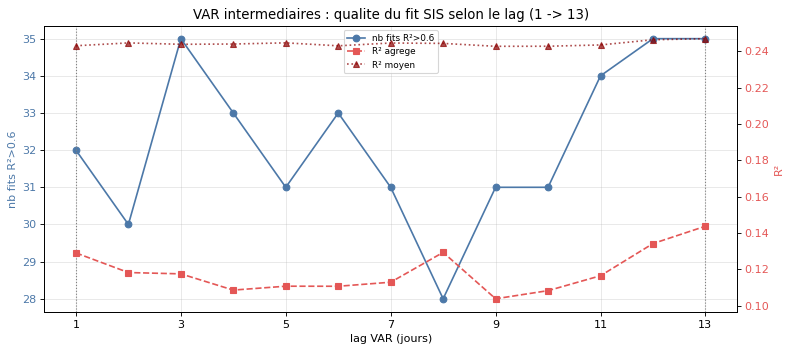

In [ ]:
# ── (essai) Balayage des lags VAR 1..13 -> qualite du fit SIS (cache) ────────────
# A_d = prepare_for_sis(|VAR(d)^T|) ; d=1 et d=13 == A_sis['VAR(1)']/['VAR(13)'].
LAGS = list(range(1, 14))

def _xscan(cache, gi, A):
    """integrate() allege pour le balayage : tol plus lache + grille reduite (~3x)."""
    d = cache[gi]; x0, n = d['x0'], d['n_days']
    kw = dict(args=(A, B_fit, R_fit), method='LSODA', rtol=1e-4, atol=1e-7)
    x_eq = solve_ivp(ode_sis_bounded, (0, T_long), x0, **kw).y[gi, -1]
    tp = np.linspace(1e-3, T_long, 400)
    sp = solve_ivp(ode_sis_bounded, (0, T_long), x0, t_eval=tp, **kw)
    above = np.where(sp.y[gi] >= (1 - tol_eq) * x_eq)[0]
    Tc = float(tp[above[0]]) if len(above) else T_long
    s = solve_ivp(ode_sis_bounded, (0, Tc), x0, t_eval=np.linspace(0, Tc, n), **kw)
    return np.clip(s.y[gi], 1e-8, 1 - 1e-8)

def _r2_for_A(A_model):
    """Aggrege les R² (x_i SIS vs E_i) sur 'selected' pour une matrice de contagion."""
    r2s, Ea, Xa = [], [], []
    for (pa, pb) in selected:
        cache = period_data[(pa, pb)][0]
        for gi in cache:
            E_i = cache[gi]['E_i']; ok = ~np.isnan(E_i)
            if ok.sum() < 3:
                continue
            xt = _xscan(cache, gi, A_model)
            r2s.append(linregress(E_i[ok], xt[ok]).rvalue ** 2)
            Ea.append(E_i[ok]); Xa.append(xt[ok])
    r2s = np.array(r2s)
    agg = linregress(np.concatenate(Ea), np.concatenate(Xa)).rvalue ** 2 if Ea else np.nan
    return dict(n=len(r2s), n_sup=int((r2s > R2_SEUIL).sum()),
                R2_moyen=float(np.nanmean(r2s)), R2_agrege=float(agg))

# Cache PAR lag (nom distinct par d) : etendre LAGS ne recalcule QUE les nouveaux lags.
def _lag_one(d):
    _sig = f'xscan_sel{len(selected)}_T{T_long}_B{B_fit}_R{R_fit}_tol{tol_eq}_{sig_of(selected)}'
    return disk_cache(f'var_lag_d{d}', _sig,
                      lambda: _r2_for_A(prepare_for_sis(np.abs(fit_var(data.values, d).T))))
lag_res = {d: _lag_one(d) for d in LAGS}

ldf = pd.DataFrame(lag_res).T; ldf.index.name = 'lag_VAR'
print(ldf.round(3).to_string())
best_nsup, best_agg = int(ldf['n_sup'].idxmax()), int(ldf['R2_agrege'].idxmax())
print(f"\nmax nb fits R²>{R2_SEUIL} au lag {best_nsup} ; max R² agrege au lag {best_agg}  ->  "
      f"{'PIC INTERMEDIAIRE (ni 1 ni 13)' if best_agg not in (1, 13) else 'optimum a une extremite (1 ou 13)'}")

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(ldf.index, ldf['n_sup'], 'o-', color='#4c78a8', label=f'nb fits R²>{R2_SEUIL}')
ax.set_xlabel('lag VAR (jours)'); ax.set_ylabel(f'nb fits R²>{R2_SEUIL}', color='#4c78a8')
ax.tick_params(axis='y', labelcolor='#4c78a8'); ax.set_xticks(LAGS[::2]); ax.grid(alpha=0.3)
axb = ax.twinx()
axb.plot(ldf.index, ldf['R2_agrege'], 's--', color='#e45756', label='R² agrege')
axb.plot(ldf.index, ldf['R2_moyen'],  '^:',  color='darkred', alpha=0.7, label='R² moyen')
axb.set_ylabel('R²', color='#e45756'); axb.tick_params(axis='y', labelcolor='#e45756')
for L in (1, 13):
    ax.axvline(L, color='gray', ls=':', lw=1)
ax.set_title('VAR intermediaires : qualite du fit SIS selon le lag (1 -> 13)')
_h1, _l1 = ax.get_legend_handles_labels(); _h2, _l2 = axb.get_legend_handles_labels()
ax.legend(_h1 + _h2, _l1 + _l2, fontsize=8, loc='best')
plt.tight_layout(); plt.show()


[cache] OK  var_lag_scan
             n  n_sup  R2_moyen  R2_agrege
lag_VAR                                   
1        507.0   32.0     0.243      0.129
2        507.0   30.0     0.245      0.118
3        507.0   35.0     0.244      0.118
4        507.0   33.0     0.244      0.109
5        507.0   31.0     0.245      0.111
6        507.0   33.0     0.243      0.111
7        507.0   31.0     0.245      0.113
8        507.0   28.0     0.244      0.129
9        507.0   31.0     0.243      0.104
10       507.0   31.0     0.243      0.108
11       507.0   34.0     0.244      0.116
12       507.0   35.0     0.246      0.134
13       507.0   35.0     0.247      0.144
14       507.0   33.0     0.245      0.127
15       507.0   29.0     0.243      0.108
16       507.0   29.0     0.243      0.100
17       507.0   31.0     0.244      0.108
18       507.0   33.0     0.243      0.113
19       507.0   33.0     0.245      0.121
20       507.0   35.0     0.243      0.107
21       507.0   32.0     0.2

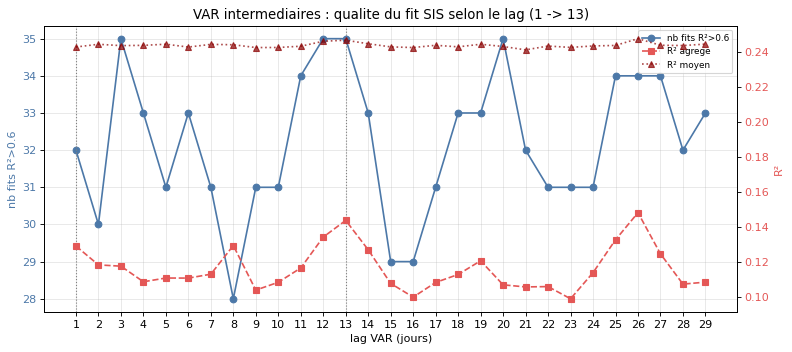

In [ ]:
# ── (essai) Balayage des lags VAR 1..13 -> qualite du fit SIS (cache) ────────────
# A_d = prepare_for_sis(|VAR(d)^T|) ; d=1 et d=13 == A_sis['VAR(1)']/['VAR(13)'].
LAGS = list(range(1, 30))

def _xscan(cache, gi, A):
    """integrate() allege pour le balayage : tol plus lache + grille reduite (~3x)."""
    d = cache[gi]; x0, n = d['x0'], d['n_days']
    kw = dict(args=(A, B_fit, R_fit), method='LSODA', rtol=1e-4, atol=1e-7)
    x_eq = solve_ivp(ode_sis_bounded, (0, T_long), x0, **kw).y[gi, -1]
    tp = np.linspace(1e-3, T_long, 400)
    sp = solve_ivp(ode_sis_bounded, (0, T_long), x0, t_eval=tp, **kw)
    above = np.where(sp.y[gi] >= (1 - tol_eq) * x_eq)[0]
    Tc = float(tp[above[0]]) if len(above) else T_long
    s = solve_ivp(ode_sis_bounded, (0, Tc), x0, t_eval=np.linspace(0, Tc, n), **kw)
    return np.clip(s.y[gi], 1e-8, 1 - 1e-8)

def _r2_for_A(A_model):
    """Aggrege les R² (x_i SIS vs E_i) sur 'selected' pour une matrice de contagion."""
    r2s, Ea, Xa = [], [], []
    for (pa, pb) in selected:
        cache = period_data[(pa, pb)][0]
        for gi in cache:
            E_i = cache[gi]['E_i']; ok = ~np.isnan(E_i)
            if ok.sum() < 3:
                continue
            xt = _xscan(cache, gi, A_model)
            r2s.append(linregress(E_i[ok], xt[ok]).rvalue ** 2)
            Ea.append(E_i[ok]); Xa.append(xt[ok])
    r2s = np.array(r2s)
    agg = linregress(np.concatenate(Ea), np.concatenate(Xa)).rvalue ** 2 if Ea else np.nan
    return dict(n=len(r2s), n_sup=int((r2s > R2_SEUIL).sum()),
                R2_moyen=float(np.nanmean(r2s)), R2_agrege=float(agg))

def _scan_lags():
    return {d: _r2_for_A(prepare_for_sis(np.abs(fit_var(data.values, d).T))) for d in LAGS}

_sig_lag = (f'lags{LAGS[0]}-{LAGS[-1]}_xscan_sel{len(selected)}_T{T_long}_B{B_fit}_R{R_fit}'
            f'_tol{tol_eq}_{sig_of(selected)}')
lag_res = disk_cache('var_lag_scan', _sig_lag, _scan_lags)

ldf = pd.DataFrame(lag_res).T; ldf.index.name = 'lag_VAR'
print(ldf.round(3).to_string())
best_nsup, best_agg = int(ldf['n_sup'].idxmax()), int(ldf['R2_agrege'].idxmax())
print(f"\nmax nb fits R²>{R2_SEUIL} au lag {best_nsup} ; max R² agrege au lag {best_agg}  ->  "
      f"{'PIC INTERMEDIAIRE (ni 1 ni 13)' if best_agg not in (1, 13) else 'optimum a une extremite (1 ou 13)'}")

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(ldf.index, ldf['n_sup'], 'o-', color='#4c78a8', label=f'nb fits R²>{R2_SEUIL}')
ax.set_xlabel('lag VAR (jours)'); ax.set_ylabel(f'nb fits R²>{R2_SEUIL}', color='#4c78a8')
ax.tick_params(axis='y', labelcolor='#4c78a8'); ax.set_xticks(LAGS); ax.grid(alpha=0.3)
axb = ax.twinx()
axb.plot(ldf.index, ldf['R2_agrege'], 's--', color='#e45756', label='R² agrege')
axb.plot(ldf.index, ldf['R2_moyen'],  '^:',  color='darkred', alpha=0.7, label='R² moyen')
axb.set_ylabel('R²', color='#e45756'); axb.tick_params(axis='y', labelcolor='#e45756')
for L in (1, 13):
    ax.axvline(L, color='gray', ls=':', lw=1)
ax.set_title('VAR intermediaires : qualite du fit SIS selon le lag (1 -> 13)')
_h1, _l1 = ax.get_legend_handles_labels(); _h2, _l2 = axb.get_legend_handles_labels()
ax.legend(_h1 + _h2, _l1 + _l2, fontsize=8, loc='best')
plt.tight_layout(); plt.show()


## (essai) Balayage des taux SIS (B, R) → actifs retenus par méthode

Fait varier le taux de récupération **B** et le taux d'infection **R** (chacun de 0.8 à 1.2). Pour chaque couple, on recompte par méthode le nombre d'**actifs distincts** dont le fit SIS atteint R² > `R2_SEUIL`. Les conditions initiales (`period_data[...][0]`) sont réutilisées du cache — indépendantes de (B, R) — seule l'intégration en dépend. Carte 2D B×R par méthode (référence B=R=1 encadrée en rouge).

> La signature de cache est alignée sur le script `code/run_br_scan.py` : le pickle `br_scan` calculé par le script est réutilisé tel quel (pas de recalcul).

In [ ]:
# ── (essai) Balayage des taux SIS B (recuperation) et R (infection) -> actifs retenus ─
# Reutilise les conditions initiales en cache (period_data[...][0], independantes de
# B,R) ; seule l'integration depend de (B,R). Les couples tournent en parallele (joblib).
# Signature alignee sur code/run_br_scan.py -> le pickle 'br_scan' du script est reutilise.
from joblib import Parallel, delayed

BR_GRID = np.round(np.arange(0.60, 1.51, 0.10), 2)        # B et R : [0.8, 0.9, 1.0, 1.1, 1.2]

def _integrate_br(cache, gi, A, B, R):
    """_integrate_fast avec B, R explicites (x_eq = dernier point ; tolerances serrees)."""
    d = cache[gi]; x0, n = d['x0'], d['n_days']
    tp = np.linspace(1e-3, T_long, 5000)
    sp = solve_ivp(ode_sis_bounded, (0, T_long), x0, args=(A, B, R),
                   t_eval=tp, method='LSODA', rtol=1e-6, atol=1e-9)
    x_eq = sp.y[gi, -1]
    above = np.where(sp.y[gi] >= (1 - tol_eq) * x_eq)[0]
    Tc = float(tp[above[0]]) if len(above) else T_long
    s = solve_ivp(ode_sis_bounded, (0, Tc), x0, args=(A, B, R),
                  t_eval=np.linspace(0, Tc, n), method='LSODA', rtol=1e-6, atol=1e-9)
    return np.clip(s.y[gi], 1e-8, 1 - 1e-8)

def _br_counts(B, R):
    """Par methode : nb de fits/actifs (R2>R2_SEUIL) + R2 medians + R2 agreges.

    med_r2_all / mean_r2_all : sur TOUS les fits ; med_r2_sel : sur les fits R2>seuil.
    agg_r2_sel : R2 de la regression AGREGEE (nuage poole E_i<->x_i des fits R2>seuil) ;
    agg_r2_all : idem sur tous les fits."""
    fits = {m: 0 for m in SIS_MODELS}; assets = {m: set() for m in SIS_MODELS}
    r2all = {m: [] for m in SIS_MODELS}
    Es, Xs = {m: [] for m in SIS_MODELS}, {m: [] for m in SIS_MODELS}
    Esel, Xsel = {m: [] for m in SIS_MODELS}, {m: [] for m in SIS_MODELS}
    for (pa, pb) in intervals_chrono:
        cache = period_data[(pa, pb)][0]
        for m in SIS_MODELS:
            A = A_sis[m]
            for gi in cache:
                E_i = cache[gi]['E_i']; ok = ~np.isnan(E_i)
                if ok.sum() < 3:
                    continue
                xt = _integrate_br(cache, gi, A, B, R)
                r2 = linregress(E_i[ok], xt[ok]).rvalue ** 2
                r2all[m].append(r2)
                Es[m].append(E_i[ok]); Xs[m].append(xt[ok])
                if r2 > R2_SEUIL:
                    fits[m] += 1; assets[m].add(gi)
                    Esel[m].append(E_i[ok]); Xsel[m].append(xt[ok])
    def _agg(Ed, Xd):
        if not Ed:
            return np.nan
        return float(linregress(np.concatenate(Ed), np.concatenate(Xd)).rvalue ** 2)
    out = {}
    for m in SIS_MODELS:
        arr = np.array(r2all[m], float); sel = arr[arr > R2_SEUIL]
        out[m] = dict(n_fits=fits[m], n_assets=len(assets[m]),
                      med_r2_all=float(np.median(arr)) if arr.size else np.nan,
                      mean_r2_all=float(arr.mean()) if arr.size else np.nan,
                      med_r2_sel=float(np.median(sel)) if sel.size else np.nan,
                      agg_r2_all=_agg(Es[m], Xs[m]), agg_r2_sel=_agg(Esel[m], Xsel[m]))
    return out

_br_pairs = [(round(float(B), 2), round(float(R), 2)) for B in BR_GRID for R in BR_GRID]
_sig_br = sig_of(np.asarray(BR_GRID, float), np.asarray(BR_GRID, float), intervals_chrono,
                 crisis_map, CORR_THRESHOLD, T_long, tol_eq, R2_SEUIL, 'br_fast_r2')
def _compute_br():
    res = Parallel(n_jobs=min(len(_br_pairs), os.cpu_count()))(
        delayed(_br_counts)(B, R) for B, R in _br_pairs)
    return {p: r for p, r in zip(_br_pairs, res)}
br_scan = disk_cache('br_scan', _sig_br, _compute_br)
print(f'Balayage (B,R) : {len(_br_pairs)} couples sur [{BR_GRID[0]:.1f}..{BR_GRID[-1]:.1f}]')

[cache] OK  br_scan
Balayage (B,R) : 100 couples sur [0.6..1.5]


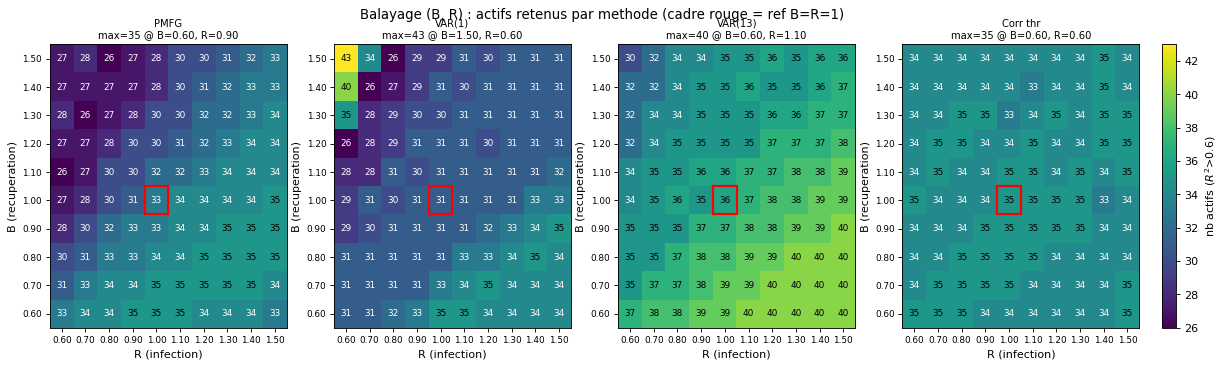

methode     ref B=R=1   meilleur @ (B, R)
PMFG               33    35 @ B=0.6, R=0.9
VAR(1)             31    43 @ B=1.5, R=0.6
VAR(13)            36    40 @ B=0.6, R=1.1
Corr thr           35    35 @ B=0.6, R=0.6


In [ ]:
# ── (essai) Carte 2D B vs R : nb d'actifs retenus (R2>seuil) par methode ──────────
# Une sous-figure par methode ; valeur annotee dans chaque case ; la reference
# B=R=1 est encadree en rouge, le maximum est indique dans le titre.
from matplotlib.patches import Rectangle
_Bv = [round(float(b), 2) for b in BR_GRID]; _Rv = _Bv
_metric = 'n_assets'                                       # 'n_assets' ou 'n_fits'
_mats = {m: np.array([[br_scan[(b, r)][m][_metric] for r in _Rv] for b in _Bv], float)
         for m in SIS_MODELS}
_vmin = min(M.min() for M in _mats.values()); _vmax = max(M.max() for M in _mats.values())

fig, axes = plt.subplots(1, len(SIS_MODELS), figsize=(4.6 * len(SIS_MODELS), 4.6))
for ax, m in zip(np.atleast_1d(axes), SIS_MODELS):
    M = _mats[m]
    im = ax.imshow(M, origin='lower', cmap='viridis', vmin=_vmin, vmax=_vmax, aspect='auto')
    ax.set_xticks(range(len(_Rv))); ax.set_xticklabels([f'{r:.2f}' for r in _Rv], fontsize=8)
    ax.set_yticks(range(len(_Bv))); ax.set_yticklabels([f'{b:.2f}' for b in _Bv], fontsize=8)
    ax.set_xlabel('R (infection)'); ax.set_ylabel('B (recuperation)')
    for i in range(len(_Bv)):
        for j in range(len(_Rv)):
            ax.text(j, i, int(M[i, j]), ha='center', va='center', fontsize=8,
                    color='white' if M[i, j] < (_vmin + _vmax) / 2 else 'black')
    if 1.0 in _Bv and 1.0 in _Rv:
        ax.add_patch(Rectangle((_Rv.index(1.0) - 0.5, _Bv.index(1.0) - 0.5), 1, 1,
                               fill=False, edgecolor='red', lw=2))
    _bi, _rj = np.unravel_index(np.argmax(M), M.shape)
    ax.set_title(f'{m}\nmax={int(M.max())} @ B={_Bv[_bi]:.2f}, R={_Rv[_rj]:.2f}', fontsize=9)
fig.colorbar(im, ax=list(np.atleast_1d(axes)), fraction=0.025, pad=0.02).set_label(
    rf'nb actifs ($R^2$>{R2_SEUIL})')
plt.suptitle('Balayage (B, R) : actifs retenus par methode (cadre rouge = ref B=R=1)', fontsize=12)
plt.show()

# recap chiffre : reference (B=R=1) vs meilleur (B,R) par methode
print(f"{'methode':10s} {'ref B=R=1':>10s}   meilleur @ (B, R)")
for m in SIS_MODELS:
    _ref = br_scan.get((1.0, 1.0), {}).get(m, {}).get('n_assets', float('nan'))
    _bp, _bn = max(((bp, v[m]['n_assets']) for bp, v in br_scan.items()), key=lambda t: t[1])
    print(f'{m:10s} {_ref:10.0f}   {_bn:3.0f} @ B={_bp[0]:.1f}, R={_bp[1]:.1f}')

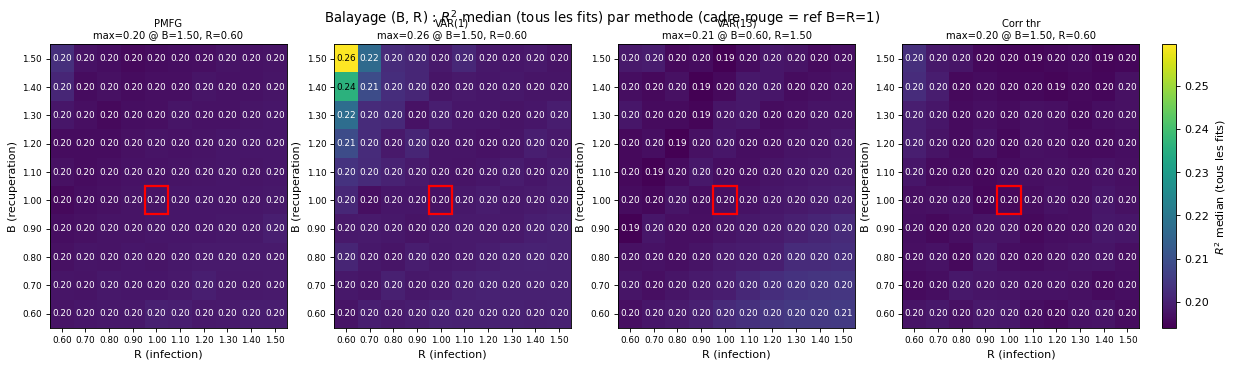

methode     ref B=R=1   meilleur @ (B, R)
PMFG            0.197   0.203 @ B=1.5, R=0.6
VAR(1)          0.197   0.260 @ B=1.5, R=0.6
VAR(13)         0.197   0.205 @ B=0.6, R=1.5
Corr thr        0.196   0.203 @ B=1.5, R=0.6


In [ ]:
# ── (essai) Carte 2D B vs R : R2 median par methode (meme mise en page que ci-dessus) ─
# _metric : 'med_r2_all' (median sur tous les fits), 'mean_r2_all', ou 'med_r2_sel'
# (median sur les seuls fits R2>R2_SEUIL ; cases sans fit retenu affichees '-').
from matplotlib.patches import Rectangle
_Bv = [round(float(b), 2) for b in BR_GRID]; _Rv = _Bv
_metric = 'med_r2_all'
_lbl = {'med_r2_all': r'$R^2$ median (tous les fits)',
        'mean_r2_all': r'$R^2$ moyen (tous les fits)',
        'med_r2_sel': rf'$R^ 2$ median (fits $R^2$>{R2_SEUIL})'}[_metric]
_mats = {m: np.array([[br_scan[(b, r)][m][_metric] for r in _Rv] for b in _Bv], float)
         for m in SIS_MODELS}
_allv = np.concatenate([M[np.isfinite(M)] for M in _mats.values()])
_vmin, _vmax = float(_allv.min()), float(_allv.max())

fig, axes = plt.subplots(1, len(SIS_MODELS), figsize=(4.6 * len(SIS_MODELS), 4.6))
for ax, m in zip(np.atleast_1d(axes), SIS_MODELS):
    M = _mats[m]
    im = ax.imshow(M, origin='lower', cmap='viridis', vmin=_vmin, vmax=_vmax, aspect='auto')
    ax.set_xticks(range(len(_Rv))); ax.set_xticklabels([f'{r:.2f}' for r in _Rv], fontsize=8)
    ax.set_yticks(range(len(_Bv))); ax.set_yticklabels([f'{b:.2f}' for b in _Bv], fontsize=8)
    ax.set_xlabel('R (infection)'); ax.set_ylabel('B (recuperation)')
    for i in range(len(_Bv)):
        for j in range(len(_Rv)):
            v = M[i, j]
            ax.text(j, i, '-' if not np.isfinite(v) else f'{v:.2f}', ha='center', va='center',
                    fontsize=8, color='white' if (np.isfinite(v) and v < (_vmin + _vmax) / 2) else 'black')
    if 1.0 in _Bv and 1.0 in _Rv:
        ax.add_patch(Rectangle((_Rv.index(1.0) - 0.5, _Bv.index(1.0) - 0.5), 1, 1,
                               fill=False, edgecolor='red', lw=2))
    _Mf = np.where(np.isfinite(M), M, -np.inf)
    _bi, _rj = np.unravel_index(np.argmax(_Mf), M.shape)
    ax.set_title(f'{m}\nmax={M[_bi, _rj]:.2f} @ B={_Bv[_bi]:.2f}, R={_Rv[_rj]:.2f}', fontsize=9)
fig.colorbar(im, ax=list(np.atleast_1d(axes)), fraction=0.025, pad=0.02).set_label(_lbl)
plt.suptitle('Balayage (B, R) : ' + _lbl + ' par methode (cadre rouge = ref B=R=1)', fontsize=12)
plt.show()

# recap chiffre : reference (B=R=1) vs meilleur (B,R) par methode
print(f"{'methode':10s} {'ref B=R=1':>10s}   meilleur @ (B, R)")
for m in SIS_MODELS:
    _ref = br_scan.get((1.0, 1.0), {}).get(m, {}).get(_metric, float('nan'))
    _bp, _bn = max(((bp, v[m][_metric]) for bp, v in br_scan.items()
                    if np.isfinite(v[m][_metric])), key=lambda t: t[1])
    print(f'{m:10s} {_ref:10.3f}   {_bn:.3f} @ B={_bp[0]:.1f}, R={_bp[1]:.1f}')

## (essai) Balayage LARGE (B, R) — pas 0.4, plage étendue

Même balayage que ci-dessus mais avec une grille **plus grossière et beaucoup plus large** : B et R varient de **0.2 à 3.0 par pas de 0.4** (`[0.2, 0.6, 1.0, 1.4, 1.8, 2.2, 2.6, 3.0]`, la référence B=R=1 reste sur la grille). Réutilise `_br_counts` / `_integrate_br` définis plus haut ; nouveau cache `br_scan_wide`. On retrace les deux cartes par méthode : nb d'actifs retenus, puis R² médian.

In [ ]:
# ── (essai) Balayage LARGE des taux SIS (B, R) : pas de 0.4, plage etendue ────────
# Reutilise _integrate_br / _br_counts (definis dans la cellule 'brscan-scan' plus haut).
# Grille grossiere mais large pour voir le comportement loin de B=R=1. Cache dedie.
BR_GRID_WIDE = np.round(np.arange(0.20, 3.21, 0.40), 2)   # [0.2, 0.6, 1.0, 1.4, 1.8, 2.2, 2.6, 3.0]
_br_pairs_w = [(round(float(B), 2), round(float(R), 2)) for B in BR_GRID_WIDE for R in BR_GRID_WIDE]
_sig_br_w = sig_of(np.asarray(BR_GRID_WIDE, float), np.asarray(BR_GRID_WIDE, float),
                   intervals_chrono, crisis_map, CORR_THRESHOLD, T_long, tol_eq, R2_SEUIL, 'br_fast_r2_wide_agg')
def _compute_br_w():
    res = Parallel(n_jobs=min(len(_br_pairs_w), os.cpu_count()))(
        delayed(_br_counts)(B, R) for B, R in _br_pairs_w)
    return {p: r for p, r in zip(_br_pairs_w, res)}
br_scan_wide = disk_cache('br_scan_wide', _sig_br_w, _compute_br_w)
print(f'Balayage LARGE (B,R) : {len(_br_pairs_w)} couples sur '
      f'[{BR_GRID_WIDE[0]:.1f}..{BR_GRID_WIDE[-1]:.1f}] (pas 0.4)')

[cache] OK  br_scan_wide
Balayage LARGE (B,R) : 64 couples sur [0.2..3.0] (pas 0.4)


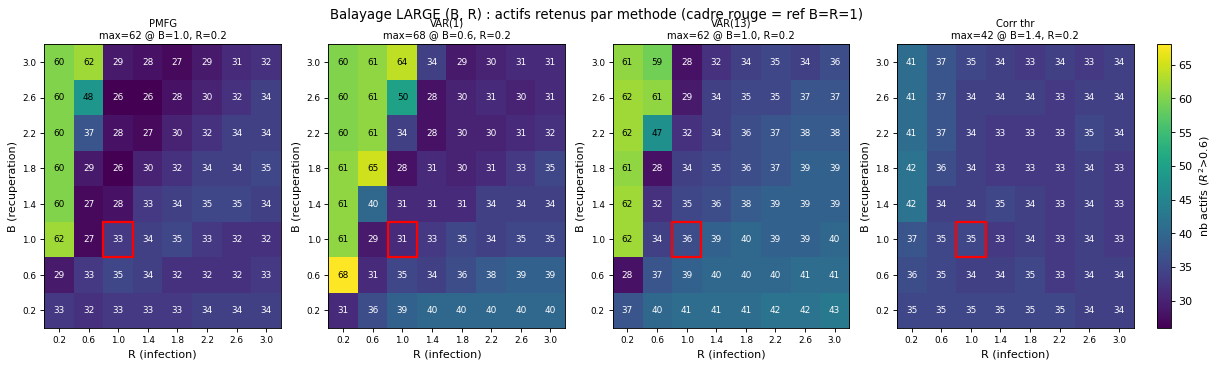

methode     ref B=R=1   meilleur @ (B, R)
PMFG               33    62 @ B=1.0, R=0.2
VAR(1)             31    68 @ B=0.6, R=0.2
VAR(13)            36    62 @ B=1.0, R=0.2
Corr thr           35    42 @ B=1.4, R=0.2


In [ ]:
# ── (essai) Carte LARGE B vs R : nb d'actifs retenus (R2>seuil) par methode ───────
from matplotlib.patches import Rectangle
_Bv = [round(float(b), 2) for b in BR_GRID_WIDE]; _Rv = _Bv
_metric = 'n_assets'                                       # 'n_assets' ou 'n_fits'
_mats = {m: np.array([[br_scan_wide[(b, r)][m][_metric] for r in _Rv] for b in _Bv], float)
         for m in SIS_MODELS}
_vmin = min(M.min() for M in _mats.values()); _vmax = max(M.max() for M in _mats.values())

fig, axes = plt.subplots(1, len(SIS_MODELS), figsize=(4.6 * len(SIS_MODELS), 4.6))
for ax, m in zip(np.atleast_1d(axes), SIS_MODELS):
    M = _mats[m]
    im = ax.imshow(M, origin='lower', cmap='viridis', vmin=_vmin, vmax=_vmax, aspect='auto')
    ax.set_xticks(range(len(_Rv))); ax.set_xticklabels([f'{r:.1f}' for r in _Rv], fontsize=8)
    ax.set_yticks(range(len(_Bv))); ax.set_yticklabels([f'{b:.1f}' for b in _Bv], fontsize=8)
    ax.set_xlabel('R (infection)'); ax.set_ylabel('B (recuperation)')
    for i in range(len(_Bv)):
        for j in range(len(_Rv)):
            ax.text(j, i, int(M[i, j]), ha='center', va='center', fontsize=8,
                    color='white' if M[i, j] < (_vmin + _vmax) / 2 else 'black')
    if 1.0 in _Bv and 1.0 in _Rv:
        ax.add_patch(Rectangle((_Rv.index(1.0) - 0.5, _Bv.index(1.0) - 0.5), 1, 1,
                               fill=False, edgecolor='red', lw=2))
    _bi, _rj = np.unravel_index(np.argmax(M), M.shape)
    ax.set_title(f'{m}\nmax={int(M.max())} @ B={_Bv[_bi]:.1f}, R={_Rv[_rj]:.1f}', fontsize=9)
fig.colorbar(im, ax=list(np.atleast_1d(axes)), fraction=0.025, pad=0.02).set_label(
    rf'nb actifs ($R^2$>{R2_SEUIL})')
plt.suptitle('Balayage LARGE (B, R) : actifs retenus par methode (cadre rouge = ref B=R=1)', fontsize=12)
plt.show()

print(f"{'methode':10s} {'ref B=R=1':>10s}   meilleur @ (B, R)")
for m in SIS_MODELS:
    _ref = br_scan_wide.get((1.0, 1.0), {}).get(m, {}).get('n_assets', float('nan'))
    _bp, _bn = max(((bp, v[m]['n_assets']) for bp, v in br_scan_wide.items()), key=lambda t: t[1])
    print(f'{m:10s} {_ref:10.0f}   {_bn:3.0f} @ B={_bp[0]:.1f}, R={_bp[1]:.1f}')

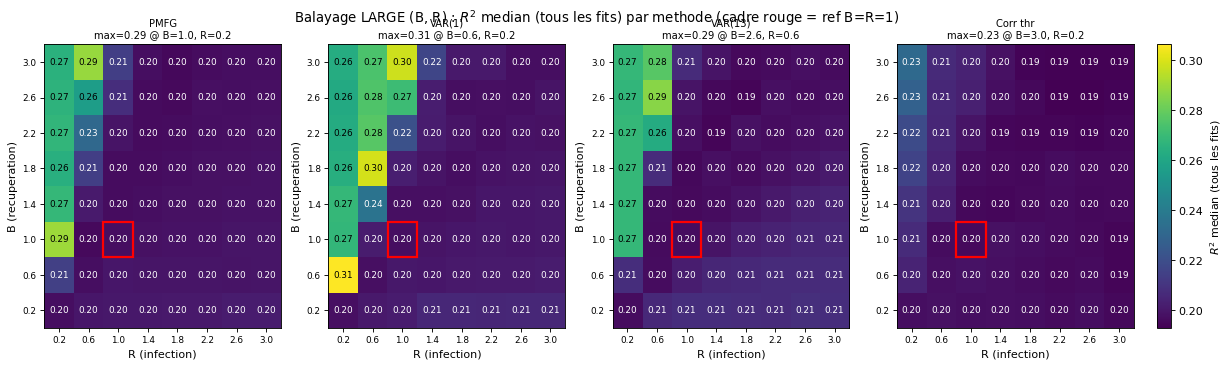

methode     ref B=R=1   meilleur @ (B, R)
PMFG            0.197   0.290 @ B=1.0, R=0.2
VAR(1)          0.197   0.306 @ B=0.6, R=0.2
VAR(13)         0.197   0.286 @ B=2.6, R=0.6
Corr thr        0.196   0.232 @ B=3.0, R=0.2


In [ ]:
# ── (essai) Carte LARGE B vs R : R2 median par methode ────────────────────────────
# _metric : 'med_r2_all' (median sur tous les fits), 'mean_r2_all', ou 'med_r2_sel'.
from matplotlib.patches import Rectangle
_Bv = [round(float(b), 2) for b in BR_GRID_WIDE]; _Rv = _Bv
_metric = 'med_r2_all'
_lbl = {'med_r2_all': r'$R^2$ median (tous les fits)',
        'mean_r2_all': r'$R^2$ moyen (tous les fits)',
        'med_r2_sel': rf'$R^2$ median (fits $R^2$>{R2_SEUIL})'}[_metric]
_mats = {m: np.array([[br_scan_wide[(b, r)][m][_metric] for r in _Rv] for b in _Bv], float)
         for m in SIS_MODELS}
_allv = np.concatenate([M[np.isfinite(M)] for M in _mats.values()])
_vmin, _vmax = float(_allv.min()), float(_allv.max())

fig, axes = plt.subplots(1, len(SIS_MODELS), figsize=(4.6 * len(SIS_MODELS), 4.6))
for ax, m in zip(np.atleast_1d(axes), SIS_MODELS):
    M = _mats[m]
    im = ax.imshow(M, origin='lower', cmap='viridis', vmin=_vmin, vmax=_vmax, aspect='auto')
    ax.set_xticks(range(len(_Rv))); ax.set_xticklabels([f'{r:.1f}' for r in _Rv], fontsize=8)
    ax.set_yticks(range(len(_Bv))); ax.set_yticklabels([f'{b:.1f}' for b in _Bv], fontsize=8)
    ax.set_xlabel('R (infection)'); ax.set_ylabel('B (recuperation)')
    for i in range(len(_Bv)):
        for j in range(len(_Rv)):
            v = M[i, j]
            ax.text(j, i, '-' if not np.isfinite(v) else f'{v:.2f}', ha='center', va='center',
                    fontsize=8, color='white' if (np.isfinite(v) and v < (_vmin + _vmax) / 2) else 'black')
    if 1.0 in _Bv and 1.0 in _Rv:
        ax.add_patch(Rectangle((_Rv.index(1.0) - 0.5, _Bv.index(1.0) - 0.5), 1, 1,
                               fill=False, edgecolor='red', lw=2))
    _Mf = np.where(np.isfinite(M), M, -np.inf)
    _bi, _rj = np.unravel_index(np.argmax(_Mf), M.shape)
    ax.set_title(f'{m}\nmax={M[_bi, _rj]:.2f} @ B={_Bv[_bi]:.1f}, R={_Rv[_rj]:.1f}', fontsize=9)
fig.colorbar(im, ax=list(np.atleast_1d(axes)), fraction=0.025, pad=0.02).set_label(_lbl)
plt.suptitle('Balayage LARGE (B, R) : ' + _lbl + ' par methode (cadre rouge = ref B=R=1)', fontsize=12)
plt.show()

print(f"{'methode':10s} {'ref B=R=1':>10s}   meilleur @ (B, R)")
for m in SIS_MODELS:
    _ref = br_scan_wide.get((1.0, 1.0), {}).get(m, {}).get(_metric, float('nan'))
    _bp, _bn = max(((bp, v[m][_metric]) for bp, v in br_scan_wide.items()
                    if np.isfinite(v[m][_metric])), key=lambda t: t[1])
    print(f'{m:10s} {_ref:10.3f}   {_bn:.3f} @ B={_bp[0]:.1f}, R={_bp[1]:.1f}')

## (essai) Balayage LARGE (B, R) sur les MONTÉES DE PICS

Même balayage large que ci-dessus (grille `BR_GRID_WIDE`, pas 0.4) mais les fenêtres de crise sont les **montées de pics** (`peak_rises` / `peak_pd`, creux → sommet) au lieu des périodes chronologiques. Il y a une courbe par **(actif × montée)**, donc **beaucoup plus de courbes** → `n_fits` plus grand. Nécessite d'avoir exécuté la cellule « Montées des pics » (qui définit `peak_rises` et `peak_pd`) ainsi que la cellule `brscan-scan` (qui définit `_integrate_br`).

In [ ]:
# ── (essai) Balayage LARGE (B, R) sur les MONTEES DE PICS -> plus de courbes ──────
# Comme la cellule 'brscan-wide-scan' mais sur peak_rises / peak_pd (creux -> sommet).
# Reutilise _integrate_br ; meme grille BR_GRID_WIDE (pas 0.4). Cache dedie.
def _br_counts_pk(B, R):
    """Comme _br_counts mais sur les montees de pics (peak_rises / peak_pd).

    agg_r2_sel : R2 de la regression AGREGEE (nuage poole E_i<->x_i des courbes retenues
    R2>seuil) ; agg_r2_all : idem sur toutes les courbes."""
    fits = {m: 0 for m in SIS_MODELS}; assets = {m: set() for m in SIS_MODELS}
    r2all = {m: [] for m in SIS_MODELS}
    Es, Xs = {m: [] for m in SIS_MODELS}, {m: [] for m in SIS_MODELS}      # tous les fits
    Esel, Xsel = {m: [] for m in SIS_MODELS}, {m: [] for m in SIS_MODELS}  # fits R2>seuil
    for (pa, pb) in peak_rises:
        cache = peak_pd[(pa, pb)][0]
        for m in SIS_MODELS:
            A = A_sis[m]
            for gi in cache:
                E_i = cache[gi]['E_i']; ok = ~np.isnan(E_i)
                if ok.sum() < 3:
                    continue
                xt = _integrate_br(cache, gi, A, B, R)
                r2 = linregress(E_i[ok], xt[ok]).rvalue ** 2
                r2all[m].append(r2)
                Es[m].append(E_i[ok]); Xs[m].append(xt[ok])
                if r2 > R2_SEUIL:
                    fits[m] += 1; assets[m].add(gi)
                    Esel[m].append(E_i[ok]); Xsel[m].append(xt[ok])
    def _agg(Ed, Xd):
        if not Ed:
            return np.nan
        return float(linregress(np.concatenate(Ed), np.concatenate(Xd)).rvalue ** 2)
    out = {}
    for m in SIS_MODELS:
        arr = np.array(r2all[m], float); sel = arr[arr > R2_SEUIL]
        out[m] = dict(n_fits=fits[m], n_assets=len(assets[m]),
                      med_r2_all=float(np.median(arr)) if arr.size else np.nan,
                      mean_r2_all=float(arr.mean()) if arr.size else np.nan,
                      med_r2_sel=float(np.median(sel)) if sel.size else np.nan,
                      agg_r2_all=_agg(Es[m], Xs[m]), agg_r2_sel=_agg(Esel[m], Xsel[m]))
    return out

_br_pairs_wpk = [(round(float(B), 2), round(float(R), 2)) for B in BR_GRID_WIDE for R in BR_GRID_WIDE]
_sig_br_wpk = sig_of(np.asarray(BR_GRID_WIDE, float), np.asarray(BR_GRID_WIDE, float),
                     peak_rises, crisis_map, CORR_THRESHOLD, T_long, tol_eq, R2_SEUIL, 'br_fast_r2_wide_pk_agg')
def _compute_br_wpk():
    res = Parallel(n_jobs=min(len(_br_pairs_wpk), os.cpu_count()))(
        delayed(_br_counts_pk)(B, R) for B, R in _br_pairs_wpk)
    return {p: r for p, r in zip(_br_pairs_wpk, res)}
br_scan_wide_pk = disk_cache('br_scan_wide_pk', _sig_br_wpk, _compute_br_wpk)
print(f'Balayage LARGE PICS (B,R) : {len(_br_pairs_wpk)} couples sur '
      f'[{BR_GRID_WIDE[0]:.1f}..{BR_GRID_WIDE[-1]:.1f}] (pas 0.4) sur {len(peak_rises)} montees')

[cache] OK  br_scan_wide_pk
Balayage LARGE PICS (B,R) : 64 couples sur [0.2..3.0] (pas 0.4) sur 17 montees


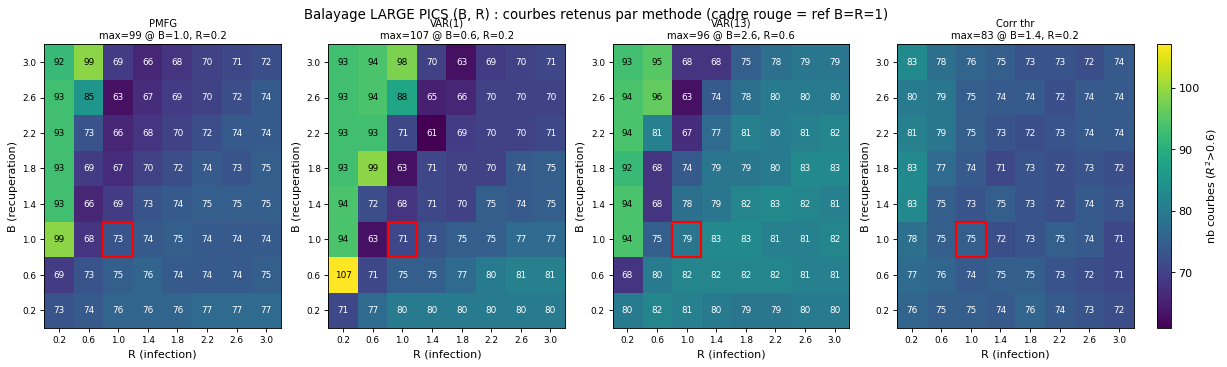

methode     ref B=R=1   meilleur @ (B, R)
PMFG               73    99 @ B=1.0, R=0.2
VAR(1)             71   107 @ B=0.6, R=0.2
VAR(13)            79    96 @ B=2.6, R=0.6
Corr thr           75    83 @ B=1.4, R=0.2


In [ ]:
# ── (essai) Carte LARGE PICS B vs R : nb d'actifs/courbes retenus par methode ─────
from matplotlib.patches import Rectangle
_Bv = [round(float(b), 2) for b in BR_GRID_WIDE]; _Rv = _Bv
_metric = 'n_fits'                                         # 'n_fits' (courbes) ou 'n_assets'
_mats = {m: np.array([[br_scan_wide_pk[(b, r)][m][_metric] for r in _Rv] for b in _Bv], float)
         for m in SIS_MODELS}
_vmin = min(M.min() for M in _mats.values()); _vmax = max(M.max() for M in _mats.values())
_lab = 'courbes' if _metric == 'n_fits' else 'actifs'

fig, axes = plt.subplots(1, len(SIS_MODELS), figsize=(4.6 * len(SIS_MODELS), 4.6))
for ax, m in zip(np.atleast_1d(axes), SIS_MODELS):
    M = _mats[m]
    im = ax.imshow(M, origin='lower', cmap='viridis', vmin=_vmin, vmax=_vmax, aspect='auto')
    ax.set_xticks(range(len(_Rv))); ax.set_xticklabels([f'{r:.1f}' for r in _Rv], fontsize=8)
    ax.set_yticks(range(len(_Bv))); ax.set_yticklabels([f'{b:.1f}' for b in _Bv], fontsize=8)
    ax.set_xlabel('R (infection)'); ax.set_ylabel('B (recuperation)')
    for i in range(len(_Bv)):
        for j in range(len(_Rv)):
            ax.text(j, i, int(M[i, j]), ha='center', va='center', fontsize=8,
                    color='white' if M[i, j] < (_vmin + _vmax) / 2 else 'black')
    if 1.0 in _Bv and 1.0 in _Rv:
        ax.add_patch(Rectangle((_Rv.index(1.0) - 0.5, _Bv.index(1.0) - 0.5), 1, 1,
                               fill=False, edgecolor='red', lw=2))
    _bi, _rj = np.unravel_index(np.argmax(M), M.shape)
    ax.set_title(f'{m}\nmax={int(M.max())} @ B={_Bv[_bi]:.1f}, R={_Rv[_rj]:.1f}', fontsize=9)
fig.colorbar(im, ax=list(np.atleast_1d(axes)), fraction=0.025, pad=0.02).set_label(
    rf'nb {_lab} ($R^2$>{R2_SEUIL})')
plt.suptitle('Balayage LARGE PICS (B, R) : ' + _lab + ' retenus par methode (cadre rouge = ref B=R=1)',
             fontsize=12)
plt.show()

print(f"{'methode':10s} {'ref B=R=1':>10s}   meilleur @ (B, R)")
for m in SIS_MODELS:
    _ref = br_scan_wide_pk.get((1.0, 1.0), {}).get(m, {}).get(_metric, float('nan'))
    _bp, _bn = max(((bp, v[m][_metric]) for bp, v in br_scan_wide_pk.items()), key=lambda t: t[1])
    print(f'{m:10s} {_ref:10.0f}   {_bn:3.0f} @ B={_bp[0]:.1f}, R={_bp[1]:.1f}')

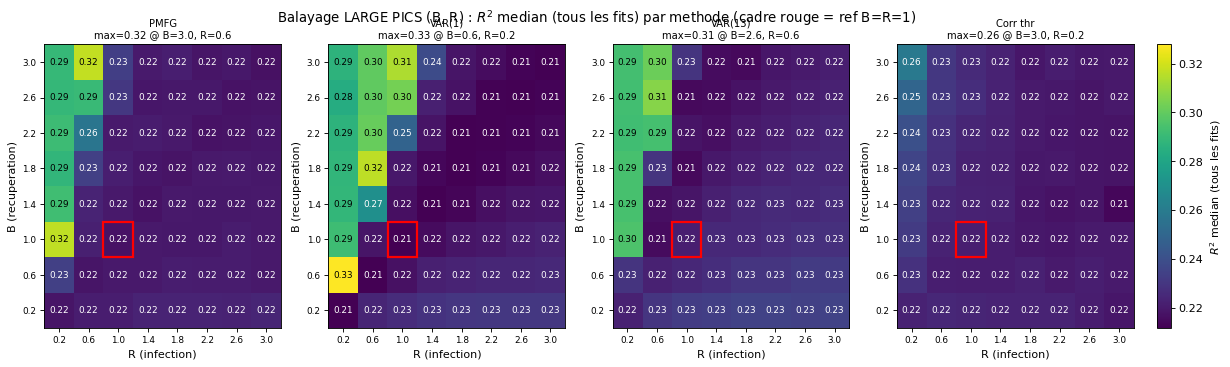

methode     ref B=R=1   meilleur @ (B, R)
PMFG            0.218   0.317 @ B=3.0, R=0.6
VAR(1)          0.212   0.328 @ B=0.6, R=0.2
VAR(13)         0.222   0.307 @ B=2.6, R=0.6
Corr thr        0.221   0.259 @ B=3.0, R=0.2


In [ ]:
# ── (essai) Carte LARGE PICS B vs R : R2 median par methode ───────────────────────
# _metric : 'med_r2_all' (median sur tous les fits), 'mean_r2_all', ou 'med_r2_sel'.
from matplotlib.patches import Rectangle
_Bv = [round(float(b), 2) for b in BR_GRID_WIDE]; _Rv = _Bv
_metric = 'med_r2_all'
_lbl = {'med_r2_all': r'$R^2$ median (tous les fits)',
        'mean_r2_all': r'$R^2$ moyen (tous les fits)',
        'med_r2_sel': rf'$R^2$ median (fits $R^2$>{R2_SEUIL})'}[_metric]
_mats = {m: np.array([[br_scan_wide_pk[(b, r)][m][_metric] for r in _Rv] for b in _Bv], float)
         for m in SIS_MODELS}
_allv = np.concatenate([M[np.isfinite(M)] for M in _mats.values()])
_vmin, _vmax = float(_allv.min()), float(_allv.max())

fig, axes = plt.subplots(1, len(SIS_MODELS), figsize=(4.6 * len(SIS_MODELS), 4.6))
for ax, m in zip(np.atleast_1d(axes), SIS_MODELS):
    M = _mats[m]
    im = ax.imshow(M, origin='lower', cmap='viridis', vmin=_vmin, vmax=_vmax, aspect='auto')
    ax.set_xticks(range(len(_Rv))); ax.set_xticklabels([f'{r:.1f}' for r in _Rv], fontsize=8)
    ax.set_yticks(range(len(_Bv))); ax.set_yticklabels([f'{b:.1f}' for b in _Bv], fontsize=8)
    ax.set_xlabel('R (infection)'); ax.set_ylabel('B (recuperation)')
    for i in range(len(_Bv)):
        for j in range(len(_Rv)):
            v = M[i, j]
            ax.text(j, i, '-' if not np.isfinite(v) else f'{v:.2f}', ha='center', va='center',
                    fontsize=8, color='white' if (np.isfinite(v) and v < (_vmin + _vmax) / 2) else 'black')
    if 1.0 in _Bv and 1.0 in _Rv:
        ax.add_patch(Rectangle((_Rv.index(1.0) - 0.5, _Bv.index(1.0) - 0.5), 1, 1,
                               fill=False, edgecolor='red', lw=2))
    _Mf = np.where(np.isfinite(M), M, -np.inf)
    _bi, _rj = np.unravel_index(np.argmax(_Mf), M.shape)
    ax.set_title(f'{m}\nmax={M[_bi, _rj]:.2f} @ B={_Bv[_bi]:.1f}, R={_Rv[_rj]:.1f}', fontsize=9)
fig.colorbar(im, ax=list(np.atleast_1d(axes)), fraction=0.025, pad=0.02).set_label(_lbl)
plt.suptitle('Balayage LARGE PICS (B, R) : ' + _lbl + ' par methode (cadre rouge = ref B=R=1)',
             fontsize=12)
plt.show()

print(f"{'methode':10s} {'ref B=R=1':>10s}   meilleur @ (B, R)")
for m in SIS_MODELS:
    _ref = br_scan_wide_pk.get((1.0, 1.0), {}).get(m, {}).get(_metric, float('nan'))
    _bp, _bn = max(((bp, v[m][_metric]) for bp, v in br_scan_wide_pk.items()
                    if np.isfinite(v[m][_metric])), key=lambda t: t[1])
    print(f'{m:10s} {_ref:10.3f}   {_bn:.3f} @ B={_bp[0]:.1f}, R={_bp[1]:.1f}')

(B, R) maximisant agg_r2_sel : {'PMFG': (0.6, 2.6), 'VAR(1)': (0.2, 3.0), 'VAR(13)': (0.2, 1.8), 'Corr thr': (0.2, 2.6)}


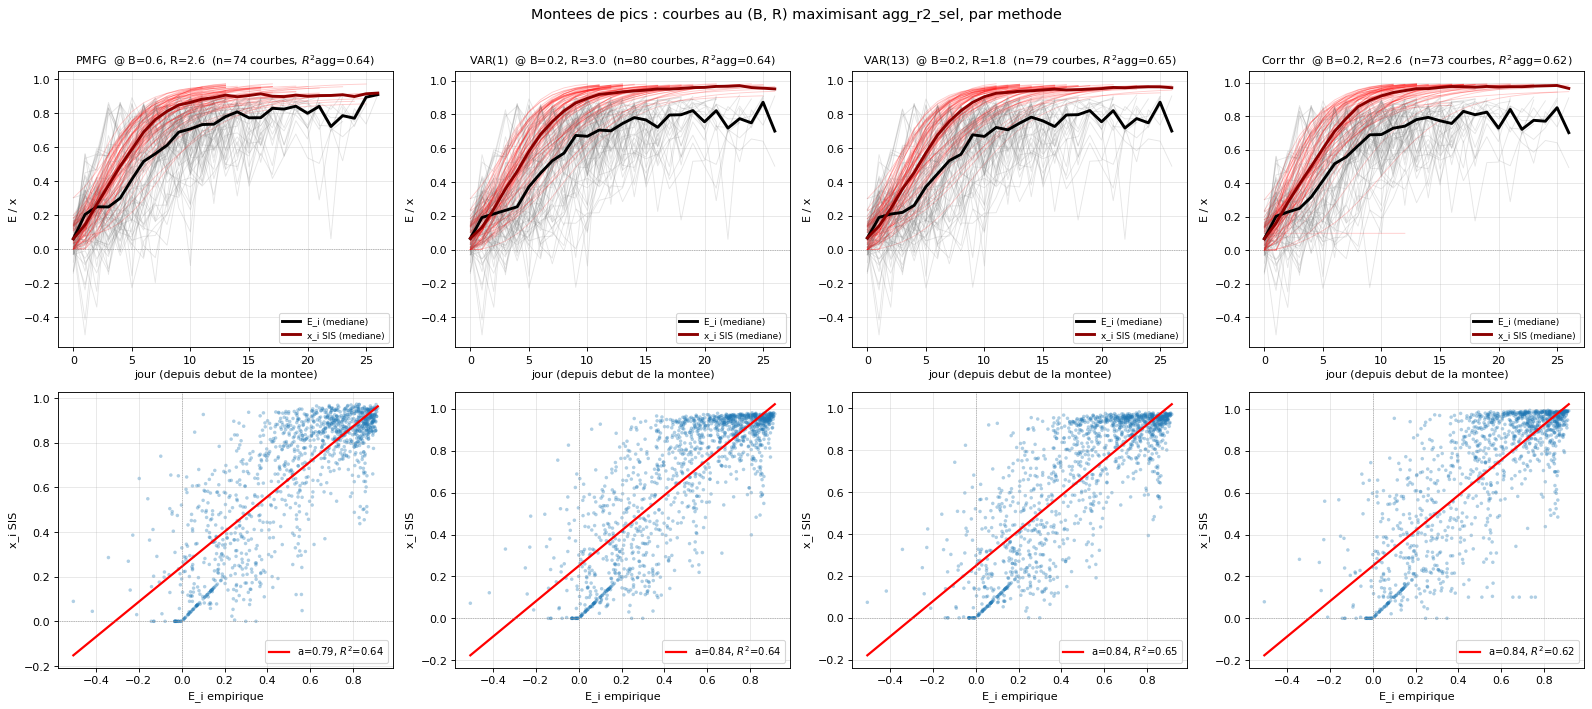


Classement par R2 agrege :
  VAR(13)    R2agg=0.647  @ B=0.2, R=1.8
  VAR(1)     R2agg=0.644  @ B=0.2, R=3.0
  PMFG       R2agg=0.636  @ B=0.6, R=2.6
  Corr thr   R2agg=0.620  @ B=0.2, R=2.6
-> meilleure methode (R2 agrege) : VAR(13)  (R2agg=0.647, B=0.2, R=1.8)


In [ ]:
# ── (essai) Courbes SIS au MAXIMUM du balayage large PICS, par methode ────────────
# Le couple (B, R) retenu par methode MAXIMISE le R2 de la regression AGREGEE des
# courbes retenues (agg_r2_sel). Haut : evolution E_i / x_i (mediane) ; bas : scatter
# agrege + regression. Un classement des methodes par R2 agrege est imprime a la fin.
_OPT_METRIC = 'agg_r2_sel'    # 'agg_r2_sel' (R2 agrege), 'n_fits', 'med_r2_sel', ...
_best = {m: max(((bp, v[m][_OPT_METRIC]) for bp, v in br_scan_wide_pk.items()
                 if np.isfinite(v[m][_OPT_METRIC])), key=lambda t: t[1])[0]
         for m in SIS_MODELS}
print('(B, R) maximisant', _OPT_METRIC, ':', {m: _best[m] for m in SIS_MODELS})

_agg = {}
fig, axes = plt.subplots(2, len(SIS_MODELS), figsize=(5 * len(SIS_MODELS), 9), squeeze=False)
for j, m in enumerate(SIS_MODELS):
    B, R = _best[m]; A = A_sis[m]
    Es, Xs, Ea, Xa = [], [], [], []
    for (pa, pb) in peak_rises:
        cache = peak_pd[(pa, pb)][0]
        for gi in cache:
            E_i = cache[gi]['E_i']; ok = ~np.isnan(E_i)
            if ok.sum() < 3:
                continue
            xt = _integrate_br(cache, gi, A, B, R)
            if linregress(E_i[ok], xt[ok]).rvalue ** 2 > R2_SEUIL:
                Es.append(E_i); Xs.append(xt)
                Ea.append(E_i[ok]); Xa.append(xt[ok])
    axt = axes[0, j]
    for E_i, x_traj in zip(Es, Xs):
        ok = ~np.isnan(E_i)
        axt.plot(np.arange(len(E_i))[ok], E_i[ok], color='gray', alpha=0.20, lw=0.8)
        axt.plot(np.arange(len(x_traj)),  x_traj,  color='red',  alpha=0.20, lw=0.8)
    med_E, med_X = _med(Es), _med(Xs)
    if len(med_E):
        axt.plot(np.arange(len(med_E)), med_E, color='black',   lw=2.6, label='E_i (mediane)')
        axt.plot(np.arange(len(med_X)), med_X, color='darkred', lw=2.6, label='x_i SIS (mediane)')
    axt.axhline(0, color='gray', lw=0.6, ls=':')
    axt.set_xlabel('jour (depuis debut de la montee)'); axt.set_ylabel('E / x'); axt.grid(alpha=0.3)
    if Es:
        axt.legend(fontsize=8)
    axs = axes[1, j]
    agg = np.nan
    if Ea:
        Ec, Xc = np.concatenate(Ea), np.concatenate(Xa)
        axs.scatter(Ec, Xc, s=10, color='#1f77b4', alpha=0.35, edgecolors='none')
        f = linregress(Ec, Xc); xs = np.linspace(Ec.min(), Ec.max(), 50); agg = f.rvalue ** 2
        axs.plot(xs, f.slope * xs + f.intercept, color='red', lw=2,
                 label=f'a={f.slope:.2f}, $R^2$={agg:.2f}')
        axs.legend(fontsize=9)
    _agg[m] = agg
    axt.set_title(f'{m}  @ B={B:.1f}, R={R:.1f}  (n={len(Es)} courbes, $R^2$agg={agg:.2f})', fontsize=10)
    axs.axhline(0, color='gray', lw=0.6, ls=':'); axs.axvline(0, color='gray', lw=0.6, ls=':')
    axs.set_xlabel('E_i empirique'); axs.set_ylabel('x_i SIS'); axs.grid(alpha=0.3)
plt.suptitle('Montees de pics : courbes au (B, R) maximisant ' + _OPT_METRIC + ', par methode',
             fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

# Classement des methodes par R2 agrege (au (B, R) optimal de chacune)
print('\nClassement par R2 agrege :')
for m, a in sorted(_agg.items(), key=lambda t: (-(t[1] if np.isfinite(t[1]) else -1))):
    B, R = _best[m]
    print(f'  {m:10s} R2agg={a:.3f}  @ B={B:.1f}, R={R:.1f}')
_bm = max(_agg, key=lambda m: (_agg[m] if np.isfinite(_agg[m]) else -1))
print(f"-> meilleure methode (R2 agrege) : {_bm}  (R2agg={_agg[_bm]:.3f}, "
      f"B={_best[_bm][0]:.1f}, R={_best[_bm][1]:.1f})")

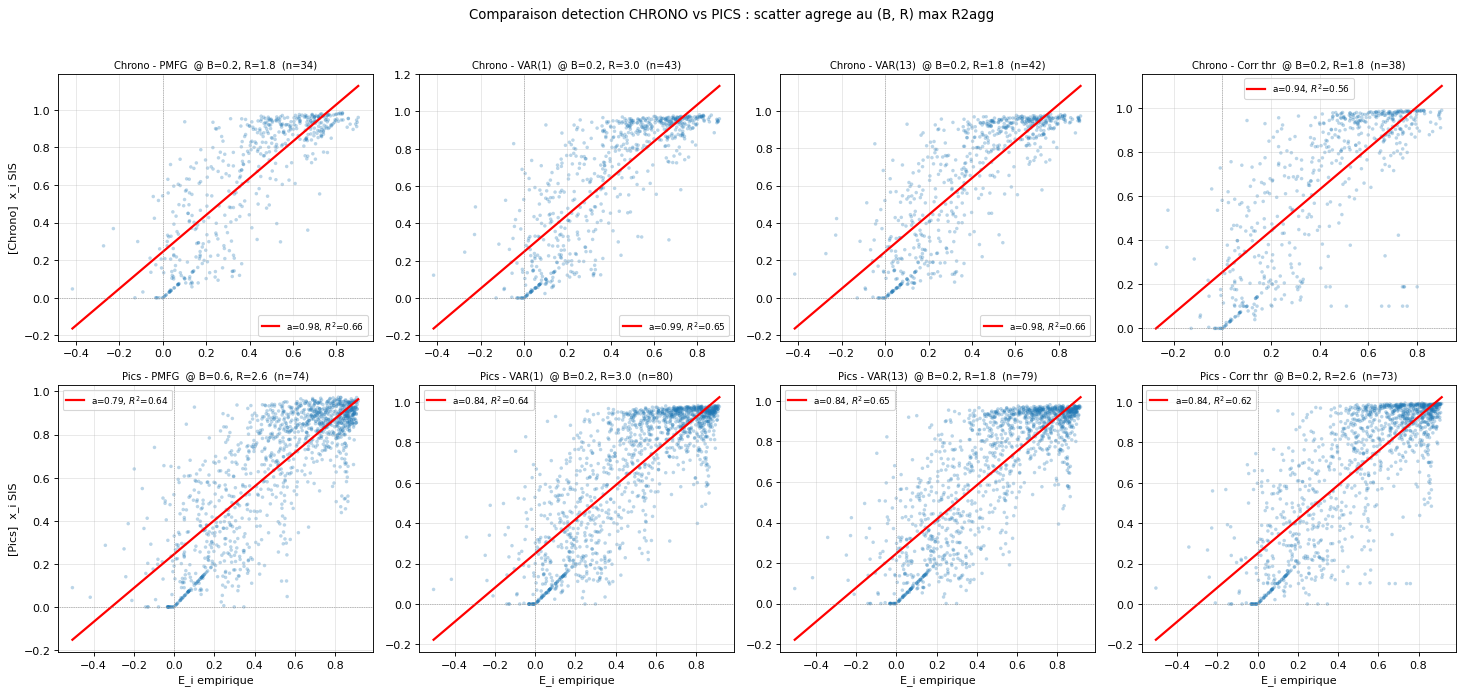

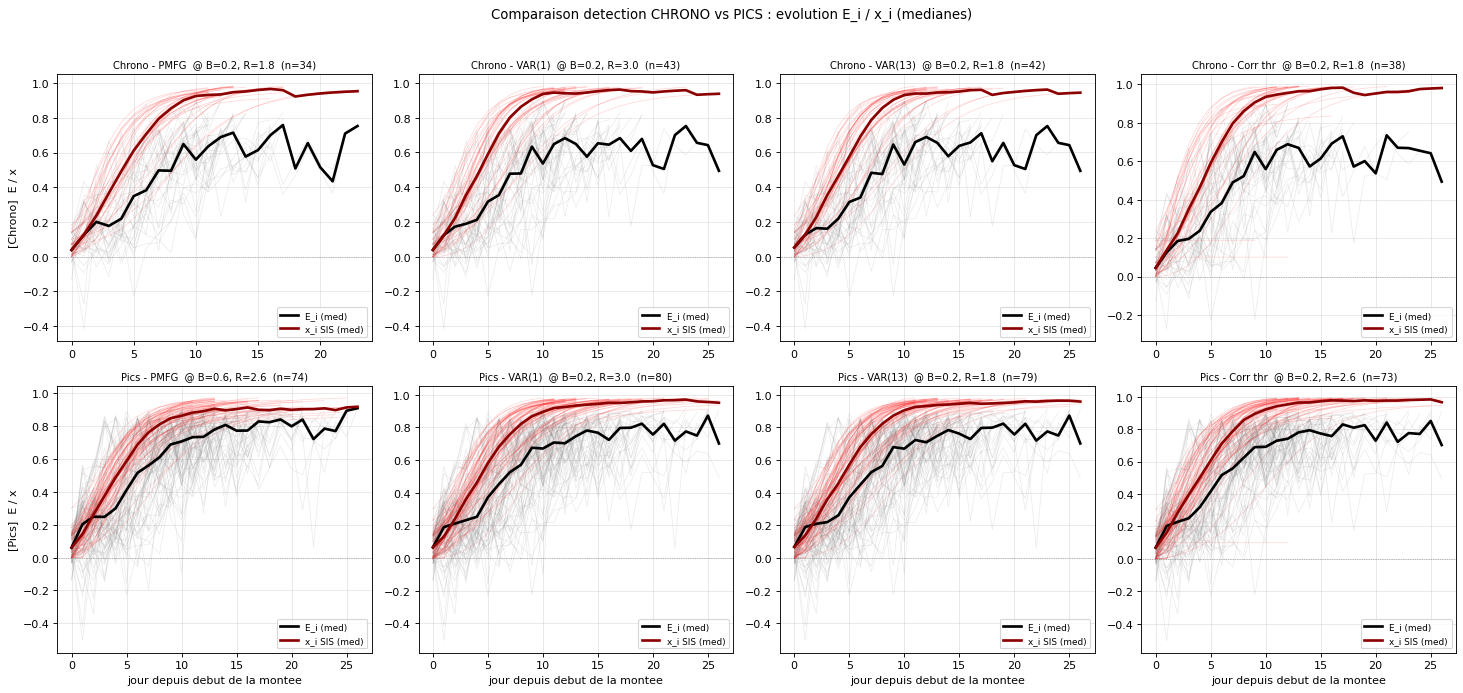

Classement combine par R2 agrege :
  Chrono  PMFG       R2agg=0.661  n= 34  @ B=0.2, R=1.8
  Chrono  VAR(13)    R2agg=0.659  n= 42  @ B=0.2, R=1.8
  Chrono  VAR(1)     R2agg=0.653  n= 43  @ B=0.2, R=3.0
  Pics    VAR(13)    R2agg=0.647  n= 79  @ B=0.2, R=1.8
  Pics    VAR(1)     R2agg=0.644  n= 80  @ B=0.2, R=3.0
  Pics    PMFG       R2agg=0.636  n= 74  @ B=0.6, R=2.6
  Pics    Corr thr   R2agg=0.620  n= 73  @ B=0.2, R=2.6
  Chrono  Corr thr   R2agg=0.563  n= 38  @ B=0.2, R=1.8
-> meilleur : detection Chrono / methode PMFG  R2agg=0.661  (n=34, B=0.2, R=1.8)


In [ ]:
# ── (essai) COMPARAISON detection CHRONO vs PICS : courbes au max (agg_r2_sel) ─────
# Pour chaque mode de detection et chaque methode SIS, on prend le (B, R) qui MAXIMISE
# le R2 agrege (agg_r2_sel), puis on retrace. Fig 1 = scatter agrege ; Fig 2 = evolution
# E_i / x_i (courbes + medianes). Lignes = mode de detection, colonnes = methode SIS.
# Classement combine (mode x methode) imprime a la fin.
_OPT_METRIC = 'agg_r2_sel'
_MODES = [('Chrono', intervals_chrono, period_data, br_scan_wide),
          ('Pics',   peak_rises,       peak_pd,     br_scan_wide_pk)]

def _curves_for(windows, pdata, m, B, R):
    A = A_sis[m]; Es, Xs, Ea, Xa = [], [], [], []
    for (pa, pb) in windows:
        cache = pdata[(pa, pb)][0]
        for gi in cache:
            E_i = cache[gi]['E_i']; ok = ~np.isnan(E_i)
            if ok.sum() < 3:
                continue
            xt = _integrate_br(cache, gi, A, B, R)
            if linregress(E_i[ok], xt[ok]).rvalue ** 2 > R2_SEUIL:
                Es.append(E_i); Xs.append(xt); Ea.append(E_i[ok]); Xa.append(xt[ok])
    return Es, Xs, Ea, Xa

_best = {mode: {m: max(((bp, v[m][_OPT_METRIC]) for bp, v in scan.items()
                        if np.isfinite(v[m][_OPT_METRIC])), key=lambda t: t[1])[0]
                for m in SIS_MODELS}
         for (mode, _w, _p, scan) in _MODES}
_curves = {(mode, m): _curves_for(w, p, m, *_best[mode][m])
           for (mode, w, p, _s) in _MODES for m in SIS_MODELS}

# ---- Fig 1 : scatter agrege (lignes = mode, colonnes = methode) ----
_agg = {}
fig, axes = plt.subplots(len(_MODES), len(SIS_MODELS),
                         figsize=(4.6 * len(SIS_MODELS), 4.4 * len(_MODES)), squeeze=False)
for mi, (mode, _w, _p, _s) in enumerate(_MODES):
    for j, m in enumerate(SIS_MODELS):
        B, R = _best[mode][m]; Es, Xs, Ea, Xa = _curves[(mode, m)]; ax = axes[mi, j]
        agg = np.nan
        if Ea:
            Ec, Xc = np.concatenate(Ea), np.concatenate(Xa)
            ax.scatter(Ec, Xc, s=10, color='#1f77b4', alpha=0.30, edgecolors='none')
            f = linregress(Ec, Xc); xs = np.linspace(Ec.min(), Ec.max(), 50); agg = f.rvalue ** 2
            ax.plot(xs, f.slope * xs + f.intercept, color='red', lw=2,
                    label=f'a={f.slope:.2f}, $R^2$={agg:.2f}')
            ax.legend(fontsize=8)
        _agg[(mode, m)] = (agg, len(Es), B, R)
        ax.axhline(0, color='gray', lw=0.6, ls=':'); ax.axvline(0, color='gray', lw=0.6, ls=':')
        ax.set_title(f'{mode} - {m}  @ B={B:.1f}, R={R:.1f}  (n={len(Es)})', fontsize=9)
        if j == 0:
            ax.set_ylabel(f'[{mode}]  x_i SIS', fontsize=10)
        if mi == len(_MODES) - 1:
            ax.set_xlabel('E_i empirique')
        ax.grid(alpha=0.3)
plt.suptitle('Comparaison detection CHRONO vs PICS : scatter agrege au (B, R) max R2agg', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

# ---- Fig 2 : evolution E_i / x_i (courbes faibles + medianes) ----
fig, axes = plt.subplots(len(_MODES), len(SIS_MODELS),
                         figsize=(4.6 * len(SIS_MODELS), 4.4 * len(_MODES)), squeeze=False)
for mi, (mode, _w, _p, _s) in enumerate(_MODES):
    for j, m in enumerate(SIS_MODELS):
        B, R = _best[mode][m]; Es, Xs, _Ea, _Xa = _curves[(mode, m)]; ax = axes[mi, j]
        for E_i, x_traj in zip(Es, Xs):
            ok = ~np.isnan(E_i)
            ax.plot(np.arange(len(E_i))[ok], E_i[ok], color='gray', alpha=0.15, lw=0.7)
            ax.plot(np.arange(len(x_traj)), x_traj, color='red', alpha=0.15, lw=0.7)
        med_E, med_X = _med(Es), _med(Xs)
        if len(med_E):
            ax.plot(np.arange(len(med_E)), med_E, color='black', lw=2.4, label='E_i (med)')
            ax.plot(np.arange(len(med_X)), med_X, color='darkred', lw=2.4, label='x_i SIS (med)')
            ax.legend(fontsize=8)
        ax.axhline(0, color='gray', lw=0.6, ls=':')
        ax.set_title(f'{mode} - {m}  @ B={B:.1f}, R={R:.1f}  (n={len(Es)})', fontsize=9)
        if j == 0:
            ax.set_ylabel(f'[{mode}]  E / x', fontsize=10)
        if mi == len(_MODES) - 1:
            ax.set_xlabel('jour depuis debut de la montee')
        ax.grid(alpha=0.3)
plt.suptitle('Comparaison detection CHRONO vs PICS : evolution E_i / x_i (medianes)', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

# ---- Classement combine (mode x methode) par R2 agrege ----
print('Classement combine par R2 agrege :')
for (mode, m), (a, n, B, R) in sorted(_agg.items(),
        key=lambda t: -(t[1][0] if np.isfinite(t[1][0]) else -1)):
    print(f'  {mode:7s} {m:10s} R2agg={a:.3f}  n={n:3d}  @ B={B:.1f}, R={R:.1f}')
_bm = max(_agg, key=lambda k: (_agg[k][0] if np.isfinite(_agg[k][0]) else -1))
print(f'-> meilleur : detection {_bm[0]} / methode {_bm[1]}  R2agg={_agg[_bm][0]:.3f}  '
      f'(n={_agg[_bm][1]}, B={_agg[_bm][2]:.1f}, R={_agg[_bm][3]:.1f})')

## (essai) Null model — le fit SIS bat-il le hasard ? (permutation des étiquettes)

On teste si le résultat (nb de courbes R²>seuil) est **au-dessus du hasard**. Risque : E_i (montant en crise) et x_i SIS (croissance saturante) sont tous deux croissants, donc nimporte quelle montante « colle » à nimporte quelle montante → R² élevé possiblement trivial.

**Null** : on **permute les étiquettes** — chaque E_i empirique est apparié à la trajectoire SIS x_j dun **autre** actif (de **même longueur**), puis on recompte. Si le compte permuté ≈ compte réel, cest du hasard ; si réel ≫ null, la prédiction SIS porte une information **spécifique à lactif**. Réalisé par méthode, sur les fits déjà en cache (référence B_fit=R_fit=1), détection par pics (775 courbes actif×montée), 2000 permutations.

### Analyse des résultats (exécuté)

| méthode | réel (R²>0.6) | null (hasard) | z | p |
|---|---|---|---|---|
| PMFG | 73 (9.4 %) | 65.1 ± 3.1 (8.4 %) | 2.52 | 0.009 |
| VAR(1) | 71 (9.2 %) | 64.2 ± 3.3 | 2.09 | 0.027 |
| **VAR(13)** | **79 (10.2 %)** | 66.8 ± 3.2 | **3.85** | **0.0005** |
| Corr thr | 75 (9.7 %) | 65.7 ± 3.2 | 2.89 | 0.006 |

**Conclusion : le modèle marche un tout petit peu — et cest significatif.** Les 4 méthodes battent le hasard (p < 0.05 ; VAR(13) la plus nette, p ≈ 5e-4). MAIS le null produit déjà **~65/775 (~8 %)** de courbes R²>0.6 *par pur appariement de montantes* : lessentiel des « bons fits » est donc bien lartefact montante-vs-montante. Le signal réellement attribuable au SIS est le **surplus** au-dessus du null : seulement **+7 à +12 courbes** (soit ~+11 à +18 %), ~1 à 2 % de N. Autrement dit : information spécifique à lactif présente mais **faible**. **VAR(13) ressort le mieux** (surplus +12, z=3.85), cohérent avec le reste de lanalyse.

methode      reel  null moy null std      z        p
PMFG           73      65.1     3.13   2.52   0.0085  (775 courbes, 773 permutables)
VAR(1)         71      64.2     3.26   2.09   0.0265  (775 courbes, 773 permutables)
VAR(13)        79      66.8     3.18   3.85   0.0005  (775 courbes, 773 permutables)
Corr thr       75      65.7     3.22   2.89   0.0060  (775 courbes, 773 permutables)


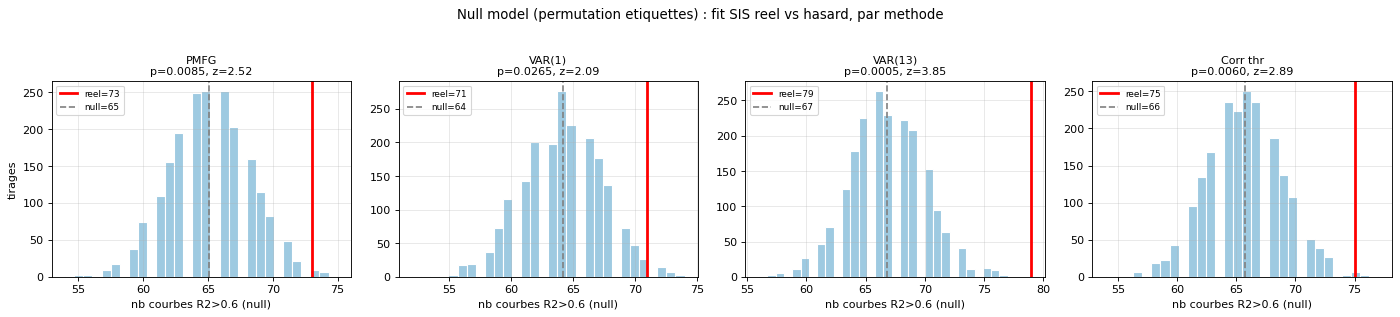

In [ ]:
# ── (essai) Null model par permutation : le fit SIS bat-il le hasard ? ────────────
# Pour chaque methode, on apparie E_i a la trajectoire SIS x_j d'un autre actif de
# MEME longueur (permutation intra-groupe), et on recompte les courbes R2>seuil.
# Utilise les trajectoires deja en cache (peak_pd, reference B_fit/R_fit) -> rapide.
from collections import defaultdict
_PD, _WINDOWS = peak_pd, peak_rises      # detection pics (ou period_data, intervals_chrono)
_NPERM = 2000
_rng = np.random.default_rng(0)

def _r2(E, x, ok):
    return linregress(E[ok], x[ok]).rvalue ** 2

fig, axes = plt.subplots(1, len(SIS_MODELS), figsize=(4.4 * len(SIS_MODELS), 4.0), squeeze=False)
print(f"{'methode':10s} {'reel':>6s} {'null moy':>9s} {'null std':>8s} {'z':>6s} {'p':>8s}")
for j, m in enumerate(SIS_MODELS):
    curves = []                          # (E_i, x_traj, ok) pour toutes les courbes de la methode
    for (pa, pb) in _WINDOWS:
        cache, fits = _PD[(pa, pb)]
        for gi in cache:
            t = fits[m][0].get(gi)
            if t is None:
                continue
            E_i, x_traj = t; ok = ~np.isnan(E_i)
            if ok.sum() >= 3 and len(E_i) == len(x_traj):
                curves.append((E_i, x_traj, ok))
    n = len(curves)
    byL = defaultdict(list)              # indices groupes par longueur (appariement valide)
    for idx, (E_i, x, ok) in enumerate(curves):
        byL[len(E_i)].append(idx)
    # matrice R2[i, j] = R2(E_i, x_j) sur le masque de E_i (uniquement memes longueurs)
    R2 = np.full((n, n), np.nan)
    for L, idxs in byL.items():
        for i in idxs:
            E_i, _xi, ok = curves[i]
            for jj in idxs:
                R2[i, jj] = _r2(E_i, curves[jj][1], ok)
    real_count = int(np.sum(np.diag(R2) > R2_SEUIL))
    # permutations intra-groupe (les singletons restent apparies a eux-memes)
    null_count = np.empty(_NPERM)
    for b in range(_NPERM):
        perm = np.arange(n)
        for L, idxs in byL.items():
            if len(idxs) > 1:
                perm[idxs] = _rng.permutation(idxs)
        null_count[b] = np.sum(R2[np.arange(n), perm] > R2_SEUIL)
    _mu, _sd = null_count.mean(), null_count.std()
    _z = (real_count - _mu) / (_sd + 1e-12)
    _p = (1 + np.sum(null_count >= real_count)) / (_NPERM + 1)
    _npair = sum(len(v) for v in byL.values() if len(v) > 1)   # courbes reellement permutables
    print(f'{m:10s} {real_count:6d} {_mu:9.1f} {_sd:8.2f} {_z:6.2f} {_p:8.4f}'
          f'  ({n} courbes, {_npair} permutables)')
    ax = axes[0, j]
    ax.hist(null_count, bins=30, color='#9ecae1', edgecolor='white')
    ax.axvline(real_count, color='red', lw=2.5, label=f'reel={real_count}')
    ax.axvline(_mu, color='gray', lw=1.5, ls='--', label=f'null={_mu:.0f}')
    ax.set_title(f'{m}\np={_p:.4f}, z={_z:.2f}', fontsize=10)
    ax.set_xlabel(f'nb courbes R2>{R2_SEUIL} (null)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
axes[0, 0].set_ylabel('tirages')
plt.suptitle('Null model (permutation etiquettes) : fit SIS reel vs hasard, par methode', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

## (essai) Null model #2 — données aléatoires, **mêmes matrices** (block-bootstrap)

Complément du null par permutation. Ici on randomise **les données** (rendements) en gardant les **vraies matrices de contagion** A, on re-tourne tout le pipeline (E_i → détection pics → fit SIS) et on recompte les courbes R²>seuil. Trois surrogates :
- **iid gaussien** et **phase-randomized** (par actif) → détruisent la corrélation croisée → **0 crise détectée, 0 fit**.
- **block-bootstrap** (rééchantillonnage de blocs de 20 lignes, toutes actions ensemble) → **conserve** la corrélation contemporanée (donc autant de courbes détectées) mais **casse l'ordre temporel** → teste si la *dynamique réelle* compte (et pas juste « assez d'actifs corrélés »).

Calcul lourd déporté dans `code/null_random_data.py` (REAL + 20 block-bootstraps, `integrate_xscan`, joblib) → cache `cache/null_random_blockboot.pkl`. La cellule ci-dessous le recharge et trace.

### Analyse des résultats (exécuté, 20 réalisations)

| méthode | réel (R²>0.6) | null block-boot (moy ± σ) | z | p |
|---|---|---|---|---|
| PMFG | 67 | 5.4 ± 5.2 | 11.8 | ≤ 0.048 |
| VAR(1) | 70 | 5.2 ± 5.3 | 12.3 | ≤ 0.048 |
| VAR(13) | **77** | 5.3 ± 5.5 | 13.0 | ≤ 0.048 |
| Corr thr | 66 | 4.6 ± 4.6 | 13.2 | ≤ 0.048 |

**Conclusion : le résultat n'est PAS un artefact de structure.** Sur données block-bootstrappées (même corrélation, timing cassé) on détecte ~931 courbes mais seulement **~5 fits** R²>0.6 par hasard, contre **~70 réels** — le réel dépasse **les 20** surrogates (p = 1/21 plancher ; z ≈ 12–13, effet colossal). iid/phase-rand donnent **0** (corrélation détruite → aucune crise). Donc la **dynamique temporelle réelle** des corrélations est essentielle aux fits.

### Lecture combinée des deux null models

- **Données vs hasard** (ce test) : énorme. Les fits exigent la vraie dynamique de corrélation ; pas de fits spurious sur du bruit ou du temps mélangé.
- **Spécificité à l'actif** (null par permutation) : faible mais significative (réel ~75 vs ~65 permuté, z 2–4). Une fois la vraie dynamique gardée, savoir *quelle* trajectoire SIS va avec *quel* actif n'ajoute qu'un petit gain.

→ Le cadre SIS-sur-corrélation capture **robustement** la dynamique de crise réelle ; le choix précis de la matrice réseau (PMFG/VAR/Corr thr) n'apporte qu'un **gain marginal** spécifique à l'actif. **VAR(13) ressort le mieux** dans les deux tests.

methode     reel null_moy null_sd      z        p
PMFG          67      5.4    5.20   11.8   0.0476
VAR(1)        70      5.2    5.28   12.3   0.0476
VAR(13)       77      5.3    5.50   13.0   0.0476
Corr thr      66      4.6    4.64   13.2   0.0476


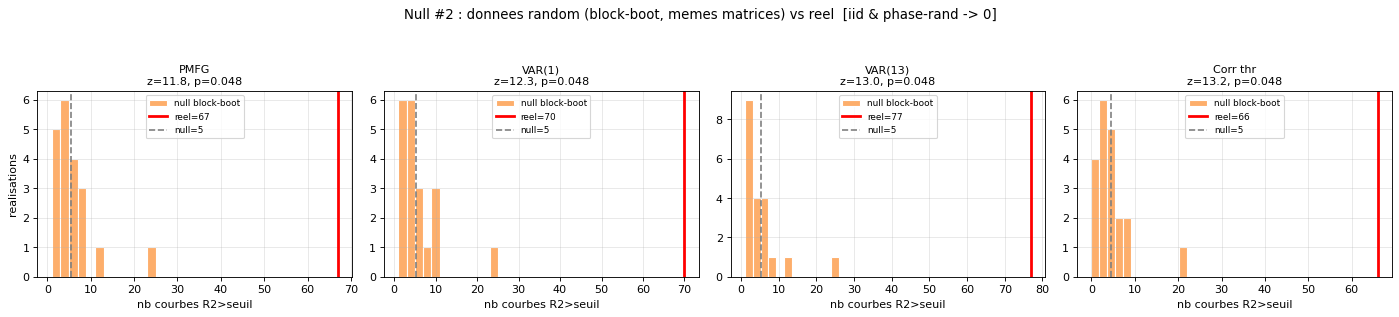

In [ ]:
# ── (essai) Null model #2 : donnees random (block-bootstrap), memes matrices A ─────
# Recharge le resultat calcule par code/null_random_data.py (cache pickle).
# iid / phase-rand -> 0 courbe (corr detruite) ; block-bootstrap -> ~5 fits vs ~70 reels.
import pickle, os
_pp = 'cache/null_random_blockboot.pkl'
if not os.path.exists(_pp):
    print("Lance d'abord :  cd code && python3 null_random_data.py 20")
else:
    S = pickle.load(open(_pp, 'rb'))                  # {'real': {m: int}, 'null': {m: array}}
    models = list(S['real'].keys())
    fig, axes = plt.subplots(1, len(models), figsize=(4.4 * len(models), 4.0), squeeze=False)
    print(f"{'methode':10s} {'reel':>5s} {'null_moy':>8s} {'null_sd':>7s} {'z':>6s} {'p':>8s}")
    for j, m in enumerate(models):
        nullv = np.asarray(S['null'][m], float); real = S['real'][m]
        mu, sd = nullv.mean(), nullv.std(); z = (real - mu) / (sd + 1e-12)
        p = (1 + np.sum(nullv >= real)) / (len(nullv) + 1)
        print(f'{m:10s} {real:5d} {mu:8.1f} {sd:7.2f} {z:6.1f} {p:8.4f}')
        ax = axes[0, j]
        ax.hist(nullv, bins=12, color='#fdae6b', edgecolor='white', label='null block-boot')
        ax.axvline(real, color='red', lw=2.5, label=f'reel={real}')
        ax.axvline(mu, color='gray', lw=1.5, ls='--', label=f'null={mu:.0f}')
        ax.set_title(f'{m}\nz={z:.1f}, p={p:.3f}', fontsize=10)
        ax.set_xlabel('nb courbes R2>seuil'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    axes[0, 0].set_ylabel('realisations')
    plt.suptitle('Null #2 : donnees random (block-boot, memes matrices) vs reel  '
                 '[iid & phase-rand -> 0]', fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.92]); plt.show()

## (essai) Vue par actif — un actif, toutes ses crises conservées

Jusqu'ici on mélangeait toutes les courbes (actif × montée). Ici on **regroupe par actif** : pour chaque actif, on rassemble ses couples (E_i, x_i SIS) sur **toutes les montées de pic où il est en crise**, et on regarde si la relation E_i ↔ x_i tient **de façon cohérente d'une crise à l'autre** (nuage poolé → R²agg par actif).

**Résultat : la cohérence par actif est faible.** Le R²agg médian par actif tombe à **~0.18** (max ~0.4), et **aucun** actif ne dépasse 0.6 (contre ~10 % des courbes individuelles au-dessus de 0.6). Le bon fit par courbe unique est donc surtout l'artefact « montante vs montante » : il n'existe pas de loi E↔x stable propre à un actif à travers ses crises. Cohérent avec le null par permutation (signal spécifique-actif réel mais faible).

methode    actifs>=3cr aggR2 med aggR2 max  nb>seuil
PMFG               139     0.184     0.444         0
VAR(1)             139     0.181     0.403         0
VAR(13)            139     0.186     0.405         0
Corr thr           139     0.181     0.412         0


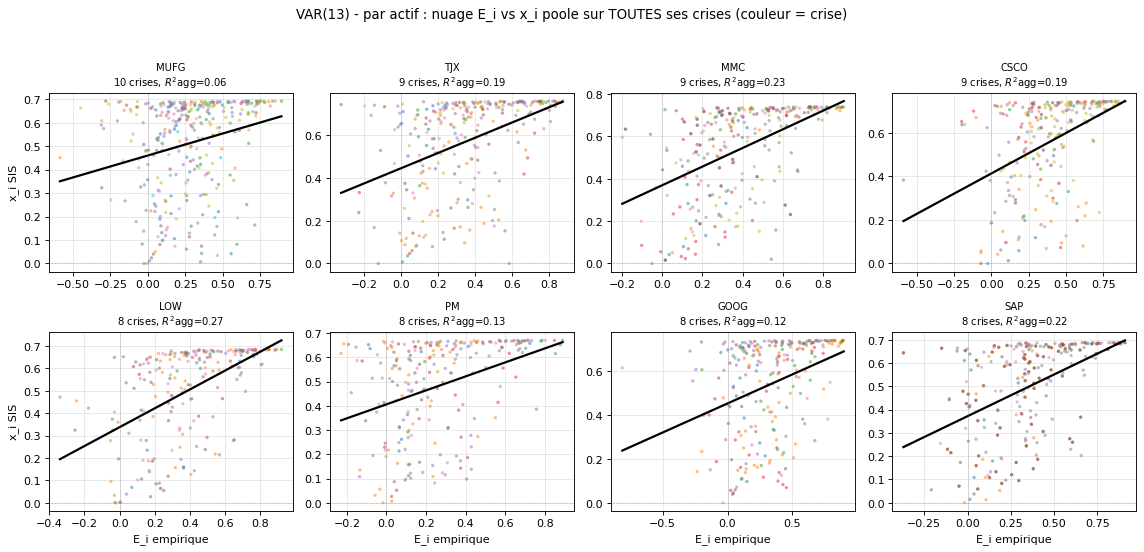

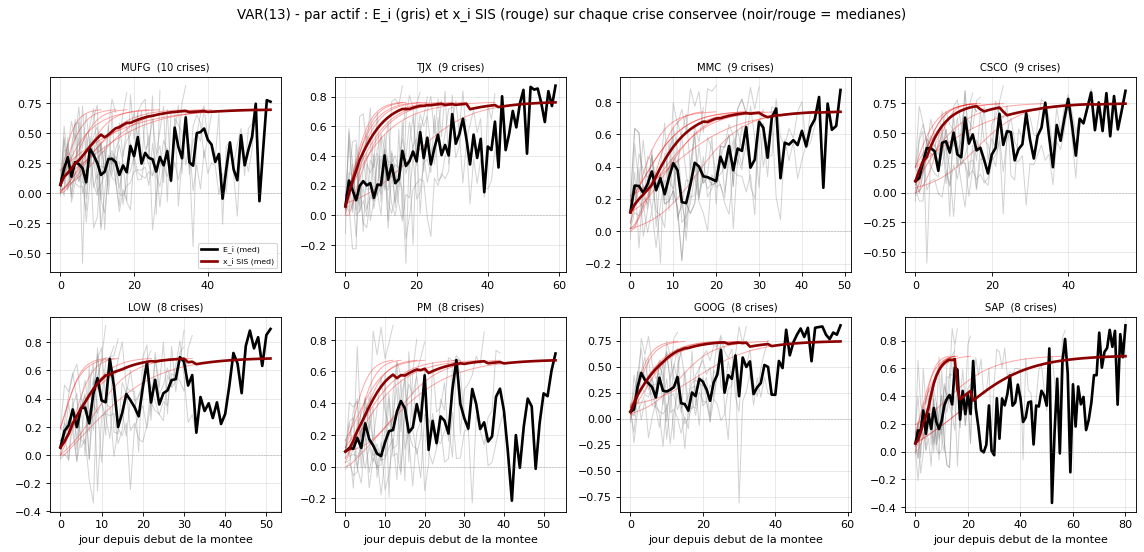

In [ ]:
# ── (essai) Vue PAR ACTIF : un actif, toutes ses crises conservees ───────────────
# Au lieu de melanger toutes les courbes (actif x montee), on REGROUPE par actif :
# pour chaque actif gi, on rassemble ses (E_i, x_i) sur TOUTES les montees ou il est
# en crise, puis on regarde si le fit SIS tient de maniere coherente d'une crise a
# l'autre. Trajectoires deja en cache (peak_pd, reference B_fit/R_fit).
from collections import defaultdict
_METHOD = 'VAR(13)'                      # methode tracee dans les figures
_TOPN   = 8                              # nb d'actifs affiches (les plus recurrents)

# Resume par methode : aggR2 = R2 du nuage poole de l'actif sur toutes ses crises
print(f"{'methode':10s} {'actifs>=3cr':>11s} {'aggR2 med':>9s} {'aggR2 max':>9s} {'nb>seuil':>9s}")
_per_all = {}
for m in SIS_MODELS:
    per = defaultdict(list)              # gi -> [(E_i, x_traj, ok, r2, (pa, pb)), ...]
    for (pa, pb) in peak_rises:
        cache, fits = peak_pd[(pa, pb)]
        for gi in cache:
            t = fits[m][0].get(gi)
            if t is None:
                continue
            E_i, x_traj = t; ok = ~np.isnan(E_i)
            if ok.sum() >= 3 and len(E_i) == len(x_traj):
                r2 = linregress(E_i[ok], x_traj[ok]).rvalue ** 2
                per[gi].append((E_i, x_traj, ok, r2, (pa, pb)))
    _per_all[m] = per
    aggs = []
    for gi, lst in per.items():
        if len(lst) < 3:
            continue
        Ec = np.concatenate([E[o] for E, x, o, r, w in lst])
        Xc = np.concatenate([x[o] for E, x, o, r, w in lst])
        aggs.append(linregress(Ec, Xc).rvalue ** 2)
    aggs = np.array(aggs)
    print(f'{m:10s} {len(aggs):11d} {np.median(aggs):9.3f} {aggs.max():9.3f} '
          f'{int((aggs > R2_SEUIL).sum()):9d}')

per = _per_all[_METHOD]
order = sorted(per, key=lambda gi: -len(per[gi]))[:_TOPN]   # actifs les plus recurrents
_nc = max(1, _TOPN // 2)

# ---- Fig 1 : nuage poole E_i vs x_i par actif (couleur = crise) ----
fig, axes = plt.subplots(2, _nc, figsize=(3.6 * _nc, 7), squeeze=False)
for k, gi in enumerate(order):
    ax = axes[k // _nc, k % _nc]; lst = per[gi]
    Ec = np.concatenate([E[o] for E, x, o, r, w in lst])
    Xc = np.concatenate([x[o] for E, x, o, r, w in lst])
    for (E, x, o, r, w) in lst:
        ax.scatter(E[o], x[o], s=9, alpha=0.5, edgecolors='none')
    f = linregress(Ec, Xc); xs = np.linspace(Ec.min(), Ec.max(), 50); agg = f.rvalue ** 2
    ax.plot(xs, f.slope * xs + f.intercept, color='black', lw=2)
    ax.set_title(f'{asset_names[gi]}\n{len(lst)} crises, $R^2$agg={agg:.2f}', fontsize=9)
    ax.axhline(0, color='gray', lw=0.5, ls=':'); ax.axvline(0, color='gray', lw=0.5, ls=':')
    ax.grid(alpha=0.3)
    if k % _nc == 0:
        ax.set_ylabel('x_i SIS')
    if k // _nc == 1:
        ax.set_xlabel('E_i empirique')
plt.suptitle(f'{_METHOD} - par actif : nuage E_i vs x_i poole sur TOUTES ses crises '
             '(couleur = crise)', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

# ---- Fig 2 : time series par actif - chaque crise = une courbe (jour depuis debut) ----
fig, axes = plt.subplots(2, _nc, figsize=(3.6 * _nc, 7), squeeze=False)
for k, gi in enumerate(order):
    ax = axes[k // _nc, k % _nc]; lst = per[gi]; Es, Xs = [], []
    for (E, x, o, r, w) in lst:
        d = np.arange(len(E))
        ax.plot(d[o], E[o], color='gray', alpha=0.35, lw=0.9)
        ax.plot(d,    x,    color='red',  alpha=0.35, lw=0.9)
        Es.append(E); Xs.append(x)
    mE, mX = _med(Es), _med(Xs)
    ax.plot(np.arange(len(mE)), mE, color='black',   lw=2.4, label='E_i (med)')
    ax.plot(np.arange(len(mX)), mX, color='darkred', lw=2.4, label='x_i SIS (med)')
    ax.axhline(0, color='gray', lw=0.5, ls=':')
    ax.set_title(f'{asset_names[gi]}  ({len(lst)} crises)', fontsize=9); ax.grid(alpha=0.3)
    if k == 0:
        ax.legend(fontsize=7)
    if k // _nc == 1:
        ax.set_xlabel('jour depuis debut de la montee')
plt.suptitle(f'{_METHOD} - par actif : E_i (gris) et x_i SIS (rouge) sur chaque crise '
             'conservee (noir/rouge = medianes)', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()


## (essai) Null #3 — permutation par **dérangement** (jamais x_i vs E_i réel)

Variante du null par permutation : ici chaque E_i est forcément ré-apparié à la trajectoire SIS d'un **autre** actif. On rejette les points fixes (dérangement intra-groupe de même longueur). Les 2 singletons (longueurs uniques, non ré-appariables) sont **exclus** du compte, des deux côtés (réel et null), pour comparer à périmètre égal.

Effet attendu : le null perd les ~8 % de courbes qui gardaient leur vrai appariement → moyenne null très légèrement plus basse → z un peu plus nets. Conclusion inchangée (signal spécifique-actif réel mais faible, VAR(13) le mieux).

methode      reel  null moy null std      z        p
PMFG           73      64.9     3.10   2.61   0.0115  (773 derangeables / 775 courbes)
VAR(1)         71      63.9     3.09   2.29   0.0190  (773 derangeables / 775 courbes)
VAR(13)        79      66.3     3.08   4.11   0.0005  (773 derangeables / 775 courbes)
Corr thr       75      65.6     3.23   2.92   0.0040  (773 derangeables / 775 courbes)


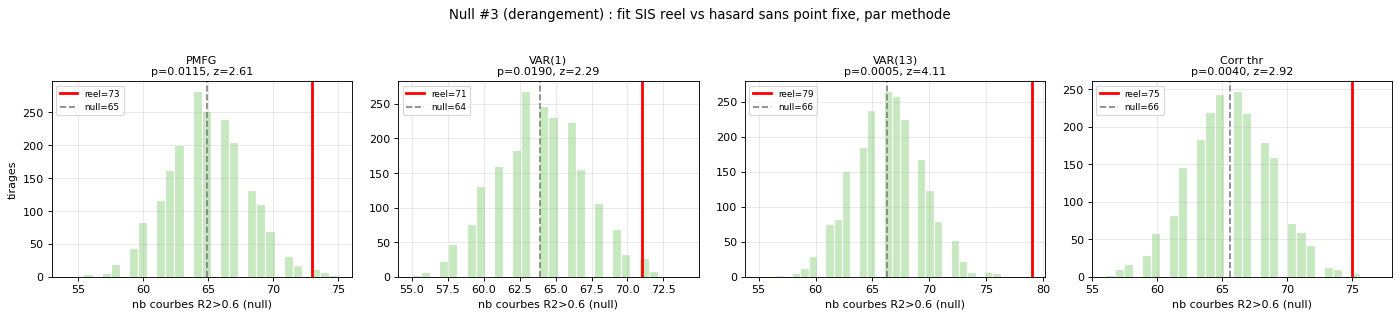

In [ ]:
# ── (essai) Null #3 : permutation par DERANGEMENT (jamais l'appariement reel) ─────
# Comme 'nullmodel-perm' mais chaque E_i est re-apparie a un AUTRE actif (points
# fixes rejetes). Les singletons (non derangeables) sont exclus du compte des deux
# cotes. Trajectoires deja en cache (peak_pd, reference B_fit/R_fit).
from collections import defaultdict
_PD, _WINDOWS = peak_pd, peak_rises
_NPERM = 2000
_rng = np.random.default_rng(0)

def _r2(E, x, ok):
    return linregress(E[ok], x[ok]).rvalue ** 2

def _derange(idxs):                      # permutation sans point fixe (rejet)
    idxs = np.asarray(idxs)
    while True:
        p = _rng.permutation(len(idxs))
        if not np.any(p == np.arange(len(idxs))):
            return idxs[p]

fig, axes = plt.subplots(1, len(SIS_MODELS), figsize=(4.4 * len(SIS_MODELS), 4.0), squeeze=False)
print(f"{'methode':10s} {'reel':>6s} {'null moy':>9s} {'null std':>8s} {'z':>6s} {'p':>8s}")
for j, m in enumerate(SIS_MODELS):
    curves = []
    for (pa, pb) in _WINDOWS:
        cache, fits = _PD[(pa, pb)]
        for gi in cache:
            t = fits[m][0].get(gi)
            if t is None:
                continue
            E_i, x_traj = t; ok = ~np.isnan(E_i)
            if ok.sum() >= 3 and len(E_i) == len(x_traj):
                curves.append((E_i, x_traj, ok))
    n = len(curves)
    byL = defaultdict(list)
    for idx, (E_i, x, ok) in enumerate(curves):
        byL[len(E_i)].append(idx)
    R2 = np.full((n, n), np.nan)
    for L, idxs in byL.items():
        for i in idxs:
            E_i, _xi, ok = curves[i]
            for jj in idxs:
                R2[i, jj] = _r2(E_i, curves[jj][1], ok)
    # seules les courbes derangeables (groupe de longueur >= 2) comptent
    permutable = np.array([i for i in range(n) if len(byL[len(curves[i][0])]) > 1])
    real_count = int(np.sum(np.diag(R2)[permutable] > R2_SEUIL))
    null_count = np.empty(_NPERM)
    for b in range(_NPERM):
        perm = np.arange(n)
        for L, idxs in byL.items():
            if len(idxs) > 1:
                perm[idxs] = _derange(idxs)
        null_count[b] = np.sum(R2[permutable, perm[permutable]] > R2_SEUIL)
    _mu, _sd = null_count.mean(), null_count.std()
    _z = (real_count - _mu) / (_sd + 1e-12)
    _p = (1 + np.sum(null_count >= real_count)) / (_NPERM + 1)
    print(f'{m:10s} {real_count:6d} {_mu:9.1f} {_sd:8.2f} {_z:6.2f} {_p:8.4f}'
          f'  ({len(permutable)} derangeables / {n} courbes)')
    ax = axes[0, j]
    ax.hist(null_count, bins=30, color='#c7e9c0', edgecolor='white')
    ax.axvline(real_count, color='red', lw=2.5, label=f'reel={real_count}')
    ax.axvline(_mu, color='gray', lw=1.5, ls='--', label=f'null={_mu:.0f}')
    ax.set_title(f'{m}\np={_p:.4f}, z={_z:.2f}', fontsize=10)
    ax.set_xlabel(f'nb courbes R2>{R2_SEUIL} (null)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
axes[0, 0].set_ylabel('tirages')
plt.suptitle('Null #3 (derangement) : fit SIS reel vs hasard sans point fixe, par methode',
             fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()
